# 환경 설정

In [131]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device():
    return torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )


set_seed(42)

device = get_device()

print("device:", device)

device: cpu


# 데이터 로드 및 데이터 확인

In [ ]:
import pandas as pd

# 파일 경로
train_path = "../data/final/sft_train_final.csv"
CORPUS_DIR = "../data/final/tokenized_corpus_final"

# 데이터 로드
train_df = pd.read_csv(train_path)
# test_df = pd.read_csv(test_path)

# 상위 5개 행 확인
print("=== Train Data ===")
display(train_df.head())

print("=== Test Data ===")
# display(test_df.head())

=== Train Data ===


,id,prompt,answer,type,generated_cot
0,77602e0f,"In Alice's Wonderland, a secret bit manipulati...",11001101,bit_manipulation,We need to deduce the transformation by matchi...
1,8a057351,"In Alice's Wonderland, a secret bit manipulati...",01110111,bit_manipulation,We need to deduce the transformation by matchi...
2,14dc1dbb,"In Alice's Wonderland, a secret unit conversio...",10.25,unit_conversion,We need to find a conversion rule that maps th...
3,7af9007a,"In Alice's Wonderland, numbers are secretly co...",LX,numeral,We need to determine the conversion rule from ...
4,524cb5c6,"In Alice's Wonderland, a secret set of transfo...",$>>\,cryptarithm_deduce,We need to infer the transformation rule from ...


=== Test Data ===


In [133]:
print("=== prompt ===")
print(train_df['prompt'][0])
print("=== answer ===")
print(train_df['answer'][0])

=== prompt ===
In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.

Here are some examples of input -> output:
01101100 -> 10111101
01010110 -> 01011010
11011110 -> 11011011
00010001 -> 11001110
01010000 -> 11111010
01001100 -> 10111011
10111101 -> 10010111
00110011 -> 10101110
11101100 -> 10111101
00000110 -> 01011111

Now, determine the output for: 00100001
=== answer ===
11001101


In [134]:
# 컬럼 이름 확인
print("=== Train columns ===")
print(train_df.columns)

# 데이터 크기 확인
print("=== Train shape ===")
print(train_df.shape)

# 데이터 타입 확인
print("=== Train info ===")
print(train_df.info())

# 결측치 확인
print("=== Train isnull ===")
print(train_df.isnull().sum())

=== Train columns ===
Index(['id', 'prompt', 'answer', 'type', 'generated_cot'], dtype='object')
=== Train shape ===
(7830, 5)
=== Train info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7830 entries, 0 to 7829
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             7830 non-null   object
 1   prompt         7830 non-null   object
 2   answer         7830 non-null   object
 3   type           7830 non-null   object
 4   generated_cot  7830 non-null   object
dtypes: object(5)
memory usage: 306.0+ KB
None
=== Train isnull ===
id               0
prompt           0
answer           0
type             0
generated_cot    0
dtype: int64


In [135]:
# print(test_df.head())
# print(test_df.columns)
# print(test_df.shape)

In [136]:
duplicate_count = train_df.duplicated().sum()

print("Duplicate Count:", duplicate_count)

Duplicate Count: 1659


# EDA

In [137]:
# ================================
# prompt 길이 계산
# ================================

# prompt 문자열 길이를 계산하여 새로운 컬럼 생성
train_df["prompt_length"] = train_df["prompt"].str.len()

# 길이 통계 확인
train_df["prompt_length"].describe()

,prompt_length
count,7830.000000
mean,318.665645
std,110.872110
min,177.000000
25%,210.000000
50%,312.000000
75%,433.000000
max,510.000000


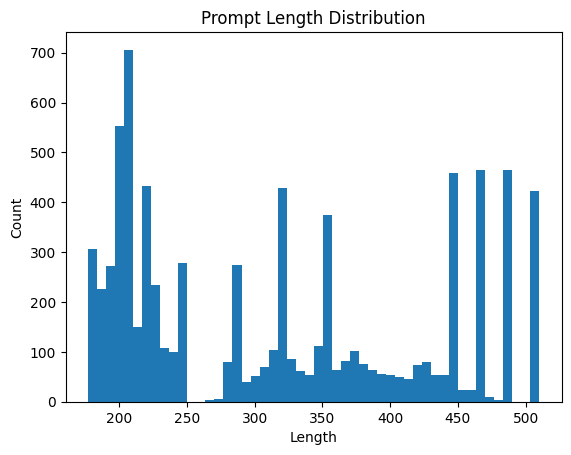

In [138]:
# ================================
# prompt 길이 분포 시각화
# ================================

import matplotlib.pyplot as plt

plt.figure()

plt.hist(
    train_df["prompt_length"],
    bins=50
)

plt.title("Prompt Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")

plt.show()

In [139]:
# ================================
# answer 길이 계산
# ================================

# answer를 문자열로 변환 후 길이 계산

train_df["answer_length"] = (
    train_df["answer"]
    .astype(str)
    .str.len()
)

train_df["answer_length"].describe()

,answer_length
count,7830.000000
mean,9.584930
std,8.668849
min,1.000000
25%,4.000000
50%,5.000000
75%,8.000000
max,39.000000


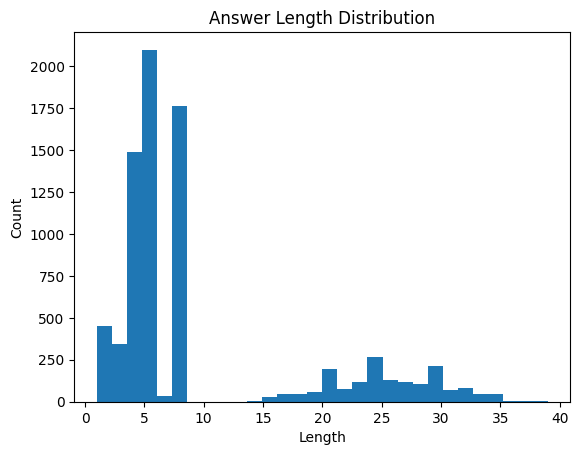

In [140]:
# ================================
# answer 길이 분포 시각화
# ================================

plt.figure()

plt.hist(
    train_df["answer_length"],
    bins=30
)

plt.title("Answer Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")

plt.show()

In [141]:
import re

def detect_symbolic_subtype(prompt):
    """
    symbolic_transformation 내부 하위 유형을 분류하는 함수

    subtype:
        - numeric_symbol: 숫자와 연산기호가 섞인 문제
        - pure_symbol: 특수문자 중심 문제
    """

    # query에 숫자가 포함되어 있으면 숫자 연산형으로 분류
    if re.search(r"\d", str(prompt)):
        return "numeric_symbol"

    return "pure_symbol"

# 패턴 탐지 함수
def detect_pattern(prompt):
    """
    prompt 문자열을 분석하여 문제 패턴을 분류하는 함수
    """

    p = prompt.lower()

    # 1. Bit manipulation
    if "bit manipulation" in p or "8-bit binary" in p:
        return "bit_manipulation"

    # 2. Unit conversion
    if "unit conversion" in p or "convert the following measurement" in p:
        return "unit_conversion"

    # 3. Roman numeral
    if "numeral system" in p or "roman" in p:
        return "roman_numeral"

    # 4. Cipher
    if "decrypt the following text" in p or "encryption rules" in p:
        return "cipher"

    # 5. Formula based
    if (
        "gravitational constant" in p
        or "falling distance" in p
        or "d = 0.5*g*t^2" in p
    ):
        return "formula_based"

    # 6. Symbolic transformation
    if (
        "transformation rules" in p
        or "determine the result for" in p
        # or re.search(r"[!@#$%^&*(){}\[\]/\\|<>?`'\"]", prompt)
        or re.search(r"\d", prompt)
    ):

        return detect_symbolic_subtype(prompt)

    return "unknown"


import re


train_df["pattern"] = train_df["prompt"].apply(detect_pattern)

train_df["pattern"].value_counts()

,count
pattern,
bit_manipulation,1754
cipher,1656
unit_conversion,1070
formula_based,1055
numeric_symbol,784
pure_symbol,781
roman_numeral,730


In [142]:
pattern_ratio = (
    train_df["pattern"]
    .value_counts(normalize=True)
    * 100
)

pattern_ratio

,proportion
pattern,
bit_manipulation,22.401022
cipher,21.149425
unit_conversion,13.665390
formula_based,13.473819
numeric_symbol,10.012771
pure_symbol,9.974457
roman_numeral,9.323116


In [143]:
# origin_pure_symbol_df = train_df[train_df["pattern"] == "pure_symbol"]

# print("origin_pure_symbol_df count:", len(origin_pure_symbol_df))

# origin_pure_symbol_df[:600].to_csv(
#     "origin_pure_symbol_df.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# print("저장 완료")

In [144]:
# 패턴별 샘플 확인
for pattern in train_df["pattern"].unique():

    print("\n")
    print("=" * 60)
    print("PATTERN:", pattern)
    print("=" * 60)

    sample = train_df[
        train_df["pattern"] == pattern
    ].sample(1, random_state=42)

    print(sample["prompt"].values[0])
    print()
    print("ANSWER:", sample["answer"].values[0])



PATTERN: bit_manipulation
In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.

Here are some examples of input -> output:
00011011 -> 11000000
01001001 -> 01000010
00001100 -> 00000000
11010111 -> 11000110
11011001 -> 01000110
00000011 -> 11000000
11100111 -> 11000111
00100011 -> 11000001
01001011 -> 11000010
11100011 -> 11000111

Now, determine the output for: 11010001

ANSWER: 01000110


PATTERN: unit_conversion
In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:
48.13 m becomes 26.21
43.8 m becomes 23.85
40.24 m becomes 21.91
48.46 m becomes 26.39
32.17 m becomes 17.52
Now, convert the following measurement: 24.88 m

ANSWER: 13.55


PATTERN: roman_numeral
In Alice's Wonderland, numbers are secretly converted into a different numeral system. Some examples are given below:
20 -> XX
31 

In [145]:
# target_patterns = ["pure_symbol", "numeric_symbol"]
target_patterns = ["pure_symbol"]

for pattern in target_patterns:

    print("\n")
    print("=" * 60)
    print("PATTERN:", pattern)
    print("=" * 60)

    subset = train_df[
        train_df["pattern"] == pattern
    ]

    if len(subset) == 0:
        print("No samples found.")
        continue

    samples = subset[:].sample(
        n=min(5, len(subset)),
        random_state=42
    )

    for _, row in samples.iterrows():

        print(row["prompt"])
        print()
        print("ANSWER:", row["answer"])
        print("-" * 40)



PATTERN: pure_symbol
In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:
&}-&& = "
$|-$% = $
}%-$` = }
Now, determine the result for: `]*|[

ANSWER: `]|[
----------------------------------------
In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:
[!*`| = [!`|
'<-{( = !'
!!-?? = [[
Now, determine the result for: <(*{&

ANSWER: <({&
----------------------------------------
In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:
`#+(' = `#('
&'+'( = &''(
$!+(! = $!(!
':*$$ = #[!&
Now, determine the result for: &(+`#

ANSWER: &(`#
----------------------------------------
In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:
\%-"% = `%
|`*"} = ?][[
\|-]? = `}
"`*)) = [\]%
Now, determine the result for: )\+?%

ANSWER: )\?%
----------------------------------------


# 전처리 (Solver 입력 구조 생성)

In [146]:
import re
import pandas as pd

def parse_unit_conversion(prompt):
    """
    unit_conversion 문제에서 예시와 query 값을 추출하는 함수

    예:
    45.95 m becomes 80.36
    Now, convert the following measurement: 43.36 m
    """
    examples = re.findall(
        r"([0-9]+(?:\.[0-9]+)?)\s*m\s*becomes\s*([0-9]+(?:\.[0-9]+)?)",
        prompt
    )

    query_match = re.search(
        r"convert the following measurement:\s*([0-9]+(?:\.[0-9]+)?)\s*m",
        prompt,
        re.IGNORECASE
    )

    query = query_match.group(1) if query_match else None

    return examples, query


def parse_roman_numeral(prompt):
    """
    roman_numeral 문제에서 숫자 변환 예시와 query 숫자를 추출하는 함수

    예:
    11 -> XI
    Now, write the number 38 in the Wonderland numeral system.
    """
    examples = re.findall(
        r"\b(\d+)\s*->\s*([IVXLCDM]+)\b",
        prompt
    )

    query_match = re.search(
        r"write the number\s+(\d+)",
        prompt,
        re.IGNORECASE
    )

    query = query_match.group(1) if query_match else None

    return examples, query


def parse_cipher(prompt):
    """
    cipher 문제에서 암호문 -> 평문 예시와 decrypt 대상 문장을 추출하는 함수

    예:
    abc def -> cat dog
    Now, decrypt the following text: xyz
    """
    examples = re.findall(
        r"^(.+?)\s*->\s*(.+)$",
        prompt,
        flags=re.MULTILINE
    )

    query_match = re.search(
        r"decrypt the following text:\s*(.+)$",
        prompt,
        re.IGNORECASE
    )

    query = query_match.group(1).strip() if query_match else None

    return examples, query


def parse_bit_manipulation(prompt):
    """
    bit_manipulation 문제에서 8-bit input -> output 예시와 query binary를 추출하는 함수

    예:
    01010001 -> 11011101
    Now, determine the output for: 00110100
    """
    examples = re.findall(
        r"\b([01]{8})\s*->\s*([01]{8})\b",
        prompt
    )

    query_match = re.search(
        r"determine the output for:\s*([01]{8})",
        prompt,
        re.IGNORECASE
    )

    query = query_match.group(1) if query_match else None

    return examples, query


def parse_formula_based(prompt):
    """
    formula_based 문제에서 t, distance 예시와 query t 값을 추출하는 함수

    예:
    For t = 4.43s, distance = 127.88 m
    Now, determine the falling distance for t = 1.48s
    """
    examples = re.findall(
        r"t\s*=\s*([0-9]+(?:\.[0-9]+)?)s,\s*distance\s*=\s*([0-9]+(?:\.[0-9]+)?)\s*m",
        prompt,
        flags=re.IGNORECASE
    )

    query_match = re.search(
        r"falling distance for t\s*=\s*([0-9]+(?:\.[0-9]+)?)s",
        prompt,
        re.IGNORECASE
    )

    query = query_match.group(1) if query_match else None

    return examples, query


def parse_symbolic_transformation(prompt):
    """
    symbolic_transformation 문제에서 식 변환 예시와 query 식을 추출하는 함수

    예:
    66$29 = 62$
    Now, determine the result for: 77/68
    """
    lines = prompt.splitlines()

    examples = []

    for line in lines:
        line = line.strip()

        # 설명 문장과 마지막 질문 제외
        if not line or "Alice" in line or "Below" in line or "Now," in line:
            continue

        # '=' 기준으로 좌우 분리
        if "=" in line:
            left, right = line.split("=", 1)
            examples.append((left.strip(), right.strip()))

    query_match = re.search(
        r"determine the result for:\s*(.+)$",
        prompt,
        re.IGNORECASE
    )

    query = query_match.group(1).strip() if query_match else None

    return examples, query

In [147]:
def parse_prompt_by_pattern(row):
    """
    pattern 값에 따라 적절한 parser를 선택하는 함수
    """
    pattern = row["pattern"]
    prompt = row["prompt"]

    if pattern == "unit_conversion":
        return parse_unit_conversion(prompt)

    elif pattern == "roman_numeral":
        return parse_roman_numeral(prompt)

    elif pattern == "cipher":
        return parse_cipher(prompt)

    elif pattern == "bit_manipulation":
        return parse_bit_manipulation(prompt)

    elif pattern == "formula_based":
        return parse_formula_based(prompt)

    elif pattern == "numeric_symbol":
        return parse_symbolic_transformation(prompt)

    elif pattern == "pure_symbol":
        return parse_symbolic_transformation(prompt)

    else:
        return [], None

In [148]:
# pattern별 parser 적용
train_df[["examples", "query"]] = train_df.apply(
    lambda row: pd.Series(parse_prompt_by_pattern(row)),
    axis=1
)

# 결과 확인
train_df[["pattern", "examples", "query"]].head(10)

,pattern,examples,query
0,bit_manipulation,"[(01101100, 10111101), (01010110, 01011010), (...",00100001
1,bit_manipulation,"[(00010000, 11111110), (01001100, 00111011), (...",11111000
2,unit_conversion,"[(40.28, 20.21), (40.5, 20.32), (45.0, 22.57),...",20.44
3,roman_numeral,"[(55, LV), (94, XCIV), (46, XLVI), (62, LXII),...",60
4,pure_symbol,"[($?:>`, $?>`), (\<:\`, \<\`), (\{@)?, @$)), (...",$>:>\
5,pure_symbol,"[(|>""&!, ?>:), (&|"":{, ?!?), (&{""//, ??#), (&!...",|#^&!
6,unit_conversion,"[(46.79, 84.03), (37.69, 67.69), (44.18, 79.35...",37.29
7,unit_conversion,"[(17.56, 18.46), (11.26, 11.84), (21.25, 22.34...",35.96
8,unit_conversion,"[(29.33, 45.45), (18.68, 28.95), (10.36, 16.05...",34.5
9,roman_numeral,"[(5, V), (12, XII), (94, XCIV)]",49


In [149]:
# numeric_symbol_df = train_df[
#     train_df["pattern"] == "numeric_symbol"
# ].copy()

# print("총 개수:", len(numeric_symbol_df))

# numeric_symbol_df[:].to_csv(
#     "numeric_symbol_df.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# 패턴별 Solver 설계

In [150]:
# =========================
# Solver Result Format
# =========================

BOXED_OUTPUT_PREFIX = (
    "The final answer must be written inside \\boxed{}."
)


def prepend_boxed_prefix(solution: str) -> str:
    """
    모든 pattern solver의 solution 시작 부분에 boxed 관련 안내 문장을 추가한다.

    처리:
        - solution 시작 전에:
          I will put my final answer inside \\boxed{}.

    중복 방지:
        - 이미 같은 prefix가 있으면 다시 추가하지 않음
    """

    if solution is None:
        return BOXED_OUTPUT_PREFIX

    solution = str(solution).strip()

    if BOXED_OUTPUT_PREFIX in solution:
        return solution

    return BOXED_OUTPUT_PREFIX + "\n\n" + solution


def make_solver_result(
    solved=False,
    answer=None,
    solution=None,
    rule_name=None,
    solver_name=None
):
    """
    모든 solver 결과를 동일한 형태로 반환한다.

    solved      : rule-based로 풀었는지 여부
    answer      : solver가 계산한 정답
    solution    : 사용한 규칙/공식/풀이 과정
    rule_name   : 사용한 규칙/공식/풀이 과정의 이름
    solver_name : 어떤 solver가 풀었는지 기록
    """

    # solution 시작 부분에 boxed 안내 문장만 추가
    # solution = prepend_boxed_prefix(solution)

    return {
        "solved": bool(solved),
        "answer": str(answer).strip() if answer is not None else None,
        "solution": solution,
        "rule_name": rule_name,
        "solver_name": solver_name,
    }

# Roman Numeral Solver

In [151]:
# ============================================
# Roman Numeral Solver
# Compact standard value-check version
# ============================================

import ast


# -------------------------
# Standard Roman value map
# -------------------------

ROMAN_MAP = [
    (1000, "M"),
    (900, "CM"),
    (500, "D"),
    (400, "CD"),
    (100, "C"),
    (90, "XC"),
    (50, "L"),
    (40, "XL"),
    (10, "X"),
    (9, "IX"),
    (5, "V"),
    (4, "IV"),
    (1, "I"),
]


def safe_parse_roman_examples_if_string(examples):
    """
    examples가 문자열이면 ast.literal_eval로 복원한다.
    이미 list/tuple이면 그대로 반환한다.
    """
    if isinstance(examples, str):
        try:
            return ast.literal_eval(examples)
        except Exception:
            return examples

    return examples


def int_to_roman(num):
    """
    정수를 standard Roman numeral 문자열로 변환한다.

    지원 범위:
        - Standard Roman numeral only

    반환:
        roman_result: 변환된 Roman numeral 문자열
        steps: 계산 로그용 step list
        original_num: 원래 입력 숫자
    """
    num = int(num)
    original_num = num

    result = ""
    steps = []

    for value, symbol in ROMAN_MAP:
        while num >= value:
            before = num
            after = num - value

            result += symbol
            num = after

            steps.append({
                "before": before,
                "value": value,
                "symbol": symbol,
                "remaining": after,
                "roman_part": symbol,
            })

    return result, steps, original_num


def format_roman_value_table_log():
    """
    Standard Roman value table만 출력한다.
    Extended Roman numeral은 출력하지 않는다.
    """
    return (
        "Reference value table\n"
        "  1000=M, 900=CM, 500=D, 400=CD\n"
        "  100=C, 90=XC, 50=L, 40=XL\n"
        "  10=X, 9=IX, 5=V, 4=IV, 1=I"
    )


def format_roman_compact_conversion_log(
    input_num,
    roman_result,
    expected_roman=None,
):
    """
    examples/query 공통 Roman 변환 로그.

    출력 형태:
        Converting 55 -> LV:
        55 < 1000 skip
        55 < 900 skip
        55 < 500 skip
        55 < 400 skip
        55 < 100 skip
        55 < 90 skip
        55 >= 50 -> L, remainder 5
        5 < 40 skip
        5 < 10 skip
        5 < 9 skip
        5 >= 5 -> V, remainder 0
        L  V -> LV
    """
    input_num = int(input_num)

    remaining = input_num
    parts = []
    lines = []

    if expected_roman is None:
        lines.append(f"Converting {input_num}:")
    else:
        lines.append(f"Converting {input_num} -> {expected_roman}:")

    for value, symbol in ROMAN_MAP:
        if remaining >= value:
            while remaining >= value:
                before = remaining
                after = remaining - value

                parts.append(symbol)
                remaining = after

                lines.append(
                    f"{before} >= {value} -> {symbol}, remainder {remaining}"
                )

        else:
            lines.append(
                f"{remaining} < {value} skip"
            )

        if remaining == 0:
            break

    if len(parts) == 0:
        lines.append(f"{roman_result}")
    else:
        lines.append(f"{'  '.join(parts)} -> {roman_result}")

    return "\n".join(lines)


def build_roman_examples_conversion_log(examples):
    """
    examples에도 query와 같은 compact value-check 템플릿을 적용한다.
    """
    examples = safe_parse_roman_examples_if_string(examples)

    if examples is None or len(examples) == 0:
        return ""

    blocks = []

    for ex in examples:
        if isinstance(ex, dict):
            input_num = ex.get("input")
            expected_roman = ex.get("output")
        else:
            input_num, expected_roman = ex

        predicted_roman, steps, original_num = int_to_roman(input_num)

        block = format_roman_compact_conversion_log(
            input_num=original_num,
            roman_result=predicted_roman,
            expected_roman=expected_roman,
        )

        blocks.append(block)

    return "\n\n".join(blocks)


def build_roman_query_conversion_log(query_num, answer):
    """
    query 변환 계산 로그를 compact value-check 형태로 만든다.
    """
    return format_roman_compact_conversion_log(
        input_num=query_num,
        roman_result=answer,
        expected_roman=None,
    )


def solve_roman_numeral(examples, query):
    """
    roman_numeral 문제를 해결하는 함수.

    처리 방식:
        1. Standard Roman numeral conversion rule 사용
        2. Extended Roman numeral은 사용하지 않음
        3. examples와 query 모두 compact value-check 템플릿으로 출력
        4. 최종 출력은 Roman numeral 문자열만 사용
    """
    rule_name = "int_to_roman_standard_compact_value_check"
    solver_name = "roman_numeral_solver_standard_compact_value_check"

    if query is None:
        return make_solver_result(
            solved=False,
            answer=None,
            rule_name=rule_name,
            solver_name=solver_name,
            solution=(
                "This is Arabic to Roman numeral conversion.\n"
                "status=unsolved\n"
                "reason=query_missing"
            ),
        )

    try:
        # -------------------------
        # 1. Query 변환
        # -------------------------
        answer, steps, original_num = int_to_roman(query)

        examples_log = build_roman_examples_conversion_log(
            examples=examples,
        )

        query_log = build_roman_query_conversion_log(
            query_num=original_num,
            answer=answer,
        )

        # -------------------------
        # 2. Compact calculation-template solution
        # -------------------------
        solution_parts = []

        solution_parts.append("This is Arabic to Roman numeral conversion.")
        solution_parts.append("")
        solution_parts.append(format_roman_value_table_log())

        if examples_log.strip() != "":
            solution_parts.append("")
            solution_parts.append(examples_log)

        solution_parts.append("")
        solution_parts.append(query_log)
        solution_parts.append("")
        solution_parts.append("I will now return the answer in \\boxed{}")
        solution_parts.append(f"The answer in \\boxed{{–}} is \\boxed{{{answer}}}")

        solution = "\n".join(solution_parts)

        return make_solver_result(
            solved=True,
            answer=answer,
            solution=solution,
            rule_name=rule_name,
            solver_name=solver_name,
        )

    except Exception as e:
        return make_solver_result(
            solved=False,
            answer=None,
            rule_name=rule_name,
            solver_name=solver_name,
            solution=(
                "This is Arabic to Roman numeral conversion.\n"
                "status=solver_exception\n"
                f"error={type(e).__name__}: {e}"
            ),
        )


# ============================================
# Roman Numeral 전체 정확도 확인
# ============================================

roman_df = train_df[
    train_df["pattern"] == "roman_numeral"
].copy()

roman_df["solver_result"] = roman_df.apply(
    lambda row: solve_roman_numeral(
        row["examples"],
        row["query"]
    ),
    axis=1
)

roman_df["prediction"] = roman_df["solver_result"].apply(
    lambda x: x["answer"] if x["solved"] else None
)

roman_accuracy = (
    roman_df["prediction"].astype(str)
    ==
    roman_df["answer"].astype(str)
).mean()

print("Roman Numeral Exact Accuracy:", roman_accuracy)


# ============================================
# roman_df solution length 통계
# ============================================

roman_df["solution_len"] = roman_df["solver_result"].apply(
    lambda x: len(str(x.get("solution", "")))
)

print("roman_df solution length stats")
print("count:", len(roman_df))
print("mean :", roman_df["solution_len"].mean())
print("min  :", roman_df["solution_len"].min())
print("max  :", roman_df["solution_len"].max())


# ============================================
# Roman Numeral 샘플 예측 확인
# ============================================

for idx, row in roman_df[0:1].iterrows():

    print("=" * 50)
    print(row["prompt"])
    print(row["solver_result"]["solution"])
    print("TRUE:", row["answer"])


# ============================================
# Roman Numeral 오답 확인
# ============================================

wrong_roman_df = roman_df[
    roman_df["prediction"].astype(str)
    !=
    roman_df["answer"].astype(str)
].copy()

print("Roman Numeral wrong count:", len(wrong_roman_df))

for idx, row in wrong_roman_df.head(10).iterrows():
    print("=" * 80)
    print("examples:", row["examples"])
    print("query:", row["query"])
    print("prediction:", row["prediction"])
    print("true:", row["answer"])
    print("rule_name:", row["solver_result"].get("rule_name"))
    print("solution:")
    print(row["solver_result"]["solution"])

Roman Numeral Exact Accuracy: 1.0
roman_df solution length stats
count: 730
mean : 1531.1931506849314
min  : 1049
max  : 2175
In Alice's Wonderland, numbers are secretly converted into a different numeral system. Some examples are given below:
55 -> LV
94 -> XCIV
46 -> XLVI
62 -> LXII
43 -> XLIII
Now, write the number 60 in the Wonderland numeral system.
This is Arabic to Roman numeral conversion.

Reference value table
  1000=M, 900=CM, 500=D, 400=CD
  100=C, 90=XC, 50=L, 40=XL
  10=X, 9=IX, 5=V, 4=IV, 1=I

Converting 55 -> LV:
55 < 1000 skip
55 < 900 skip
55 < 500 skip
55 < 400 skip
55 < 100 skip
55 < 90 skip
55 >= 50 -> L, remainder 5
5 < 40 skip
5 < 10 skip
5 < 9 skip
5 >= 5 -> V, remainder 0
L  V -> LV

Converting 94 -> XCIV:
94 < 1000 skip
94 < 900 skip
94 < 500 skip
94 < 400 skip
94 < 100 skip
94 >= 90 -> XC, remainder 4
4 < 50 skip
4 < 40 skip
4 < 10 skip
4 < 9 skip
4 < 5 skip
4 >= 4 -> IV, remainder 0
XC  IV -> XCIV

Converting 46 -> XLVI:
46 < 1000 skip
46 < 900 skip
46 < 500

In [152]:
# ============================================
# Roman Numeral 전체 정확도 확인
# ============================================

roman_df = train_df[
    train_df["pattern"] == "roman_numeral"
].copy()

roman_df["solver_result"] = roman_df.apply(
    lambda row: solve_roman_numeral(
        row["examples"],
        row["query"]
    ),
    axis=1
)

roman_df["prediction"] = roman_df["solver_result"].apply(
    lambda x: x["answer"] if x["solved"] else None
)

roman_accuracy = (
    roman_df["prediction"].astype(str)
    ==
    roman_df["answer"].astype(str)
).mean()

print("Roman Numeral Exact Accuracy:", roman_accuracy)

Roman Numeral Exact Accuracy: 1.0


In [153]:
# ============================================
# roman_df solution length 통계
# ============================================

roman_df["solution_len"] = roman_df["solver_result"].apply(
    lambda x: len(str(x.get("solution", "")))
)

print("roman_df solution length stats")
print("count:", len(roman_df))
print("mean :", roman_df["solution_len"].mean())
print("min  :", roman_df["solution_len"].min())
print("max  :", roman_df["solution_len"].max())

roman_df solution length stats
count: 730
mean : 1531.1931506849314
min  : 1049
max  : 2175


In [154]:
# ============================================
# Roman Numeral 샘플 예측 확인
# ============================================

for idx, row in roman_df[0:1].iterrows():

    print("=" * 50)
    print(row["prompt"])
    print(row["solver_result"]["solution"])
    # print("QUERY:", row["query"])
    # print("Prediction :", row["prediction"])
    print("TRUE:", row["answer"])

In Alice's Wonderland, numbers are secretly converted into a different numeral system. Some examples are given below:
55 -> LV
94 -> XCIV
46 -> XLVI
62 -> LXII
43 -> XLIII
Now, write the number 60 in the Wonderland numeral system.
This is Arabic to Roman numeral conversion.

Reference value table
  1000=M, 900=CM, 500=D, 400=CD
  100=C, 90=XC, 50=L, 40=XL
  10=X, 9=IX, 5=V, 4=IV, 1=I

Converting 55 -> LV:
55 < 1000 skip
55 < 900 skip
55 < 500 skip
55 < 400 skip
55 < 100 skip
55 < 90 skip
55 >= 50 -> L, remainder 5
5 < 40 skip
5 < 10 skip
5 < 9 skip
5 >= 5 -> V, remainder 0
L  V -> LV

Converting 94 -> XCIV:
94 < 1000 skip
94 < 900 skip
94 < 500 skip
94 < 400 skip
94 < 100 skip
94 >= 90 -> XC, remainder 4
4 < 50 skip
4 < 40 skip
4 < 10 skip
4 < 9 skip
4 < 5 skip
4 >= 4 -> IV, remainder 0
XC  IV -> XCIV

Converting 46 -> XLVI:
46 < 1000 skip
46 < 900 skip
46 < 500 skip
46 < 400 skip
46 < 100 skip
46 < 90 skip
46 < 50 skip
46 >= 40 -> XL, remainder 6
6 < 10 skip
6 < 9 skip
6 >= 5 -> V, re

# Unit Conversion Solver

In [155]:
# ============================================
# Unit Conversion Solver
# ============================================

import re
import math
from decimal import Decimal, ROUND_HALF_UP


# ============================================
# Basic numeric helpers
# ============================================

def decimal_to_scaled_int(value, decimals=2):
    """
    소수 값을 정수 비율 계산용으로 변환한다.

    예:
        18.46 -> 1846
        17.56 -> 1756
    """
    value = Decimal(str(value))
    scale = Decimal(10) ** decimals

    return int((value * scale).to_integral_value(rounding=ROUND_HALF_UP))


def truncate_float(value, decimals=3):
    """
    고득점자 unit log 스타일에 맞춰 소수점 decimals 자리에서 버림 처리한다.

    예:
        37.79396 -> 37.793
        53.44050 -> 53.440
        0.920279 -> 0.920
    """
    value = float(value)
    scale = 10 ** decimals

    if value >= 0:
        return math.floor(value * scale) / scale

    return math.ceil(value * scale) / scale


def format_truncated_decimal(value, decimals=3):
    """
    소수점 decimals 자리까지 버림 후 고정 자리수 문자열로 출력한다.
    """
    return f"{truncate_float(value, decimals=decimals):.{decimals}f}"


def format_factor_template_value(value, decimals=3):
    """
    factor를 고득점자 스타일로 소수점 3자리까지 표시한다.
    """
    return format_truncated_decimal(value, decimals=decimals)


def get_factor_template_float(value, decimals=3):
    """
    계산에 사용할 factor template float.
    """
    return truncate_float(value, decimals=decimals)


# ============================================
# High-score-style factor division trace
# ============================================

def format_accumulated_value(value, decimals):
    """
    누적 factor 값을 현재 자리수에 맞게 출력한다.
    """
    return f"{value:.{decimals}f}"


def format_place_value(pos):
    """
    자리값을 고득점자 스타일로 출력한다.

    pos=1 -> 0.1
    pos=2 -> 0.01
    pos=3 -> 0.001
    """
    return f"{10 ** (-pos):.{pos}f}"


def build_highscore_style_division_trace(
    numerator,
    denominator,
    factor_decimals=3,
):
    """
    고득점자 unit COT와 유사한 factor 나눗셈 로그를 만든다.

    출력 예:
        = 0 + 1 * 1846 / 1756
        = 1 + 1 * 90 / 1756
        = 1.0 + 0.1 * 900 / 1756
        = 1.00 + 0.01 * 9000 / 1756
        = 1.01 + 0.01 * 7244 / 1756
        ...
        = 1.051

    목적:
        - 모델이 factor = output / input 계산 패턴을 반복적으로 학습하게 한다.
        - 고득점자 데이터셋처럼 계산 템플릿을 길게 보여준다.
    """
    numerator = int(numerator)
    denominator = int(denominator)

    lines = []

    if denominator == 0:
        lines.append("= undefined_division_by_zero")
        return lines

    sign = -1 if (numerator < 0) ^ (denominator < 0) else 1

    n = abs(numerator)
    d = abs(denominator)

    integer_part = n // d
    remainder = n % d

    # 첫 줄: 원래 분수
    lines.append(f"= 0 + 1 * {numerator} / {denominator}")

    # 정수부가 0이 아닌 경우에만 정수부 처리 줄을 추가한다.
    # factor < 1인 경우에는 첫 줄과 완전히 중복되므로 생략한다.
    current_value = integer_part * sign

    if integer_part != 0:
        signed_remainder = remainder if sign > 0 else -remainder
        lines.append(
            f"= {current_value} + 1 * {signed_remainder} / {denominator}"
        )

    # 소수부 자리별 전개
    for pos in range(1, factor_decimals + 1):
        place = 10 ** (-pos)
        place_text = format_place_value(pos)

        expanded = remainder * 10

        # 자리 이동 줄
        current_text = format_accumulated_value(current_value, pos)
        signed_expanded = expanded if sign > 0 else -expanded

        lines.append(
            f"= {current_text} + {place_text} * {signed_expanded} / {denominator}"
        )

        digit = expanded // d
        new_remainder = expanded % d

        # digit만큼 같은 자리값을 더하는 로그
        # 예: digit=5, place=0.01이면 1.01, 1.02, ..., 1.05까지 출력
        for step in range(1, int(digit) + 1):
            current_value += sign * place

            remaining_after_step = expanded - (step * d)
            signed_remaining = remaining_after_step if sign > 0 else -remaining_after_step

            current_text = format_accumulated_value(current_value, pos)

            lines.append(
                f"= {current_text} + {place_text} * {signed_remaining} / {denominator}"
            )

        remainder = new_remainder

    approx_value = numerator / denominator

    lines.append(
        f"= {format_factor_template_value(approx_value, decimals=factor_decimals)}"
    )

    return lines


# ============================================
# Example / factor logs
# ============================================

def build_unit_examples_log(examples):
    """
    Compact example list.
    """
    lines = ["Examples:"]

    if examples is None or len(examples) == 0:
        lines.append("none")
        return "\n".join(lines)

    for idx, (x, y) in enumerate(examples):
        lines.append(f"{idx}: {float(x):.2f} -> {float(y):.2f}")

    return "\n".join(lines)


def build_unit_factor_calculation_log(
    item,
    factor_decimals=3,
):
    """
    example 하나에서 factor = output / input 계산 로그를 만든다.
    고득점자 데이터셋 스타일과 최대한 유사하게 출력한다.
    """
    x = item["input"]
    y = item["output"]

    scaled_y = decimal_to_scaled_int(
        y,
        decimals=2,
    )

    scaled_x = decimal_to_scaled_int(
        x,
        decimals=2,
    )

    factor_template = format_factor_template_value(
        item["raw_ratio"],
        decimals=factor_decimals,
    )

    lines = []
    lines.append(f"{x:.2f} -> {y:.2f}")
    lines.append(
        f"Casting input to 2 decimal places, output to 2 decimal places: {x:.2f} -> {y:.2f}"
    )
    lines.append(f"factor = {y:.2f} / {x:.2f}")

    division_trace = build_highscore_style_division_trace(
        numerator=scaled_y,
        denominator=scaled_x,
        factor_decimals=factor_decimals,
    )

    lines.extend(division_trace)

    # 고득점자 데이터셋은 마지막 '= 1.051' 자체가 factor log 역할을 한다.
    # 다만 v15 디버깅 확인을 위해 짧은 key-value 로그도 남긴다.
    lines.append(f"factor_template={factor_template}")

    return "\n".join(lines)


# ============================================
# Factor summary
# ============================================

def median_from_sorted_values(sorted_values):
    """
    정렬된 값 리스트에서 median을 계산한다.
    """
    n = len(sorted_values)

    if n == 0:
        return None

    if n % 2 == 1:
        return sorted_values[n // 2]

    return (sorted_values[n // 2 - 1] + sorted_values[n // 2]) / 2


def build_factor_summary_log(factor_templates):
    """
    고득점자 데이터셋 스타일의 factor summary.
    """
    factor_templates_sorted = sorted(factor_templates)
    median_factor = median_from_sorted_values(factor_templates_sorted)

    factor_values_text = ", ".join(
        f"{v:.3f}"
        for v in factor_templates
    )

    sorted_values_text = ", ".join(
        f"{v:.3f}"
        for v in factor_templates_sorted
    )

    lines = []
    lines.append(f"factor values: {factor_values_text}")
    lines.append(f"factor values (sorted): {sorted_values_text}")
    lines.append(f"The median factor is {median_factor:.3f}.")

    return "\n".join(lines), median_factor


# ============================================
# Query multiplication log
# ============================================

def decompose_decimal_multiplier(value, decimals=3):
    """
    multiplier를 자리값 단위로 분해한다.

    예:
        1.051 -> [1.000, 0.050, 0.001]
        0.920 -> [0.900, 0.020]
        1.549 -> [1.000, 0.500, 0.040, 0.009]
    """
    value = float(value)

    sign = -1 if value < 0 else 1
    value_abs = abs(value)

    text = f"{value_abs:.{decimals}f}"
    integer_part, decimal_part = text.split(".")

    terms = []

    # integer 자리 분해
    for pos, digit_char in enumerate(integer_part):
        digit = int(digit_char)

        if digit == 0:
            continue

        power = len(integer_part) - pos - 1
        place_value = digit * (10 ** power)
        terms.append(sign * place_value)

    # decimal 자리 분해
    for pos, digit_char in enumerate(decimal_part, start=1):
        digit = int(digit_char)

        if digit == 0:
            continue

        place_value = digit * (10 ** (-pos))
        terms.append(sign * place_value)

    if len(terms) == 0:
        terms.append(0.0)

    return terms


def format_multiplier_term(term):
    """
    query multiplication 로그용 term 포맷.
    """
    return f"{term:.3f}"


def build_unit_query_calculation_log(
    query_value,
    median_factor,
    factor_decimals=3,
):
    """
    query * median factor 계산 로그.
    고득점자 데이터셋처럼 자리값별 곱셈과 누적합을 보여준다.
    """
    terms = decompose_decimal_multiplier(
        median_factor,
        decimals=factor_decimals,
    )

    # 고득점자 예시처럼 작은 자리값부터 보여준다.
    terms_for_display = sorted(
        terms,
        key=lambda x: abs(x),
    )

    prediction = query_value * median_factor
    answer = format_truncated_decimal(
        prediction,
        decimals=factor_decimals,
    )

    lines = []
    lines.append(f"Converting {query_value:g}:")
    lines.append(f"{query_value:g} * {median_factor:.3f}:")

    partial_values = []

    for term in terms_for_display:
        partial = query_value * term
        partial_values.append(partial)

        lines.append(
            f"{query_value:g} * {format_multiplier_term(term)} = {partial:.5f}"
        )

    running_sum = 0.0

    for idx, partial in enumerate(partial_values):
        if idx == 0:
            running_sum = partial
            continue

        previous = running_sum
        running_sum += partial

        lines.append(
            f"{previous:.5f} + {partial:.5f} = {running_sum:.5f}"
        )

    lines.append(f"= {answer}")

    return "\n".join(lines), answer


# ============================================
# Solver
# ============================================

def solve_unit_conversion(examples, query):
    """
    Unit Conversion 문제를 해결하는 함수.

    고득점자 데이터셋 방식:
        1. 각 example에서 factor = output / input 계산
        2. factor를 소수점 3자리 템플릿으로 변환
        3. factor values를 정렬
        4. median factor 선택
        5. query에 median factor를 곱함
        6. 최종 output은 소수점 3자리까지 버림 출력

    v15:
        - assistant.reasoning_content에는 계산 템플릿형 solution 저장
        - assistant.content에는 \\boxed{answer}만 저장
    """

    rule_name = "median_3_decimal_factor_template"
    solver_name = "unit_conversion_solver"

    if query is None or examples is None or len(examples) == 0:
        return make_solver_result(
            solved=False,
            rule_name=rule_name,
            solver_name=solver_name,
            solution=(
                "Task: unit_conversion\n"
                "status=unsolved\n"
                "reason=query_or_examples_missing"
            )
        )

    try:
        parsed_examples = []
        factor_templates = []

        # -------------------------
        # 1. 각 example에서 raw factor와 3자리 factor template 계산
        # -------------------------
        for example_idx, (x, y) in enumerate(examples):
            x = float(x)
            y = float(y)

            if x == 0:
                continue

            raw_ratio = y / x
            factor_template = get_factor_template_float(
                raw_ratio,
                decimals=3,
            )

            parsed_examples.append({
                "idx": example_idx,
                "input": x,
                "output": y,
                "raw_ratio": raw_ratio,
                "factor_template": factor_template,
            })

            factor_templates.append(factor_template)

        if len(parsed_examples) == 0:
            return make_solver_result(
                solved=False,
                rule_name=rule_name,
                solver_name=solver_name,
                solution=(
                    "Task: unit_conversion\n"
                    "status=unsolved\n"
                    "reason=no_valid_examples"
                )
            )

        # -------------------------
        # 2. median factor 선택
        # -------------------------
        factor_summary_log, median_factor = build_factor_summary_log(
            factor_templates=factor_templates,
        )

        # -------------------------
        # 3. query 계산
        # -------------------------
        query_value = float(query)

        query_calculation_log, answer = build_unit_query_calculation_log(
            query_value=query_value,
            median_factor=median_factor,
            factor_decimals=3,
        )

        # -------------------------
        # 4. v15 high-score-style solution 생성
        # -------------------------
        factor_logs = "\n\n".join(
            build_unit_factor_calculation_log(
                item=item,
                factor_decimals=3,
            )
            for item in parsed_examples
        )

        solution = (
            "Task: unit_conversion\n"
            f"Query: {query_value:g}\n\n"
            f"{build_unit_examples_log(examples)}\n\n"
            f"{factor_logs}\n\n"
            f"{factor_summary_log}\n\n"
            f"{query_calculation_log}\n\n"
            "Final output:\n"
            f"{answer}\n\n"
            "Final boxed answer:\n"
            f"\\boxed{{{answer}}}"
        )

        return make_solver_result(
            solved=True,
            answer=answer,
            solution=solution,
            rule_name=rule_name,
            solver_name=solver_name,
        )

    except Exception as e:
        return make_solver_result(
            solved=False,
            rule_name=rule_name,
            solver_name=solver_name,
            solution=(
                "Task: unit_conversion\n"
                "status=solver_exception\n"
                f"error={type(e).__name__}: {e}"
            )
        )

In [156]:
# ============================================
# Unit Conversion 전체 정확도 확인
# ============================================

unit_df = train_df[
    train_df["pattern"] == "unit_conversion"
].copy()

unit_df["solver_result"] = unit_df.apply(
    lambda row: solve_unit_conversion(
        row["examples"],
        row["query"]
    ),
    axis=1
)

unit_df["prediction"] = unit_df["solver_result"].apply(
    lambda x: x["answer"] if x["solved"] else None
)

unit_accuracy = (
    unit_df["prediction"].astype(str)
    ==
    unit_df["answer"].astype(str)
).mean()

print("Unit Conversion Accuracy:", unit_accuracy)

Unit Conversion Accuracy: 0.0


In [157]:
# ============================================
# unit_df solution length 통계
# ============================================

unit_df["solution_len"] = unit_df["solver_result"].apply(
    lambda x: len(str(x.get("solution", "")))
)

print("unit_df solution length stats")
print("count:", len(unit_df))
print("mean :", unit_df["solution_len"].mean())
print("min  :", unit_df["solution_len"].min())
print("max  :", unit_df["solution_len"].max())

unit_df solution length stats
count: 1070
mean : 3179.1943925233645
min  : 1122
max  : 5381


In [158]:
# 샘플에 대해 예측 결과 확인
for idx, row in unit_df[2:3].iterrows():

    print("=" * 50)
    # print("examples:", row["examples"])
    print(row["prompt"])
    print(row["solver_result"]["solution"])
    # print("QUERY:", row["query"])
    # print("Prediction :", row["prediction"])
    print("TRUE :", row["answer"])

In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:
17.56 m becomes 18.46
11.26 m becomes 11.84
21.25 m becomes 22.34
21.79 m becomes 22.91
31.27 m becomes 32.87
Now, convert the following measurement: 35.96 m
Task: unit_conversion
Query: 35.96

Examples:
0: 17.56 -> 18.46
1: 11.26 -> 11.84
2: 21.25 -> 22.34
3: 21.79 -> 22.91
4: 31.27 -> 32.87

17.56 -> 18.46
Casting input to 2 decimal places, output to 2 decimal places: 17.56 -> 18.46
factor = 18.46 / 17.56
= 0 + 1 * 1846 / 1756
= 1 + 1 * 90 / 1756
= 1.0 + 0.1 * 900 / 1756
= 1.00 + 0.01 * 9000 / 1756
= 1.01 + 0.01 * 7244 / 1756
= 1.02 + 0.01 * 5488 / 1756
= 1.03 + 0.01 * 3732 / 1756
= 1.04 + 0.01 * 1976 / 1756
= 1.05 + 0.01 * 220 / 1756
= 1.050 + 0.001 * 2200 / 1756
= 1.051 + 0.001 * 444 / 1756
= 1.051
factor_template=1.051

11.26 -> 11.84
Casting input to 2 decimal places, output to 2 decimal places: 11.26 -> 11.84
factor = 11.84 / 11.26
= 0 + 1 * 1184 / 1126
= 1 + 1 * 58 / 1126
= 1.0 + 0.1 * 580 

In [159]:
# unit_conversion 오답 샘플 확인

wrong_unit_df = unit_df[
    unit_df["prediction"].astype(str) != unit_df["answer"].astype(str)
].copy()

print("오답 개수:", len(wrong_unit_df))

for idx, row in wrong_unit_df[:800].iterrows():

    print("=" * 50)
    # print("examples:", row["examples"])
    # print(row["prompt"])
    # print("Solver Result:", row["solver_result"])
    # print(row["solver_result"]["solution"])
    # print("QUERY:", row["query"])
    print("Prediction :", row["prediction"])
    print("TRUE :", row["answer"])

오답 개수: 1070
Prediction : 10.240
TRUE : 10.25
Prediction : 66.935
TRUE : 66.97
Prediction : 37.793
TRUE : 37.80
Prediction : 53.440
TRUE : 53.46
Prediction : 40.588
TRUE : 40.59
Prediction : 17.747
TRUE : 17.75
Prediction : 11.620
TRUE : 11.63
Prediction : 9.494
TRUE : 9.50
Prediction : 12.959
TRUE : 12.96
Prediction : 27.212
TRUE : 27.22
Prediction : 24.551
TRUE : 24.57
Prediction : 32.049
TRUE : 32.05
Prediction : 30.259
TRUE : 30.26
Prediction : 80.137
TRUE : 80.17
Prediction : 26.857
TRUE : 26.88
Prediction : 32.012
TRUE : 32.02
Prediction : 13.548
TRUE : 13.56
Prediction : 17.443
TRUE : 17.44
Prediction : 20.841
TRUE : 20.86
Prediction : 40.068
TRUE : 40.07
Prediction : 64.820
TRUE : 64.85
Prediction : 21.600
TRUE : 21.60
Prediction : 12.489
TRUE : 12.49
Prediction : 82.616
TRUE : 82.63
Prediction : 19.756
TRUE : 19.76
Prediction : 22.770
TRUE : 22.81
Prediction : 22.213
TRUE : 22.22
Prediction : 53.117
TRUE : 53.14
Prediction : 55.065
TRUE : 55.07
Prediction : 62.576
TRUE : 62.58


In [160]:
# Kaggle Metric 방식 숫자 비교 함수

import math

def metric_like_match(true, pred):
    """
    Kaggle metric과 유사한 방식으로 정답 여부를 판단하는 함수

    숫자형:
        상대 오차 1e-2, 절대 오차 1e-5 허용

    문자열:
        대소문자 무시 후 exact match
    """

    true = str(true).strip()
    pred = str(pred).strip()

    # 정답이 0과 1로만 구성된 이진수라면 문자열로 엄격 비교
    if re.fullmatch(r"[01]+", true):
        return pred.lower() == true.lower()

    try:
        true_num = float(true)
        pred_num = float(pred)

        return math.isclose(
            true_num,
            pred_num,
            rel_tol=1e-2,
            abs_tol=1e-5
        )

    except:
        return pred.lower() == true.lower()

In [161]:
# Unit Conversion Metric-like Accuracy 확인

unit_metric_accuracy = unit_df.apply(
    lambda row: metric_like_match(
        row["answer"],
        row["prediction"]
    ),
    axis=1
).mean()

print("Unit Conversion Exact Accuracy:", unit_accuracy)
print("Unit Conversion Metric-like Accuracy:", unit_metric_accuracy)

Unit Conversion Exact Accuracy: 0.0
Unit Conversion Metric-like Accuracy: 1.0


# Formula Based Solver

In [162]:
# ============================================
# Formula Based Solver
# v15 high-score-style gravity k median template
# ============================================

import math
from decimal import Decimal, ROUND_HALF_UP


# ============================================
# Numeric formatting helpers
# ============================================

def truncate_float(value, decimals=3):
    """
    고득점자 gravity COT 스타일에 맞춰 소수점 decimals 자리에서 버림 처리한다.

    예:
        156.3470771 -> 156.347
        8.339812    -> 8.339
    """
    value = float(value)
    scale = 10 ** decimals

    if value >= 0:
        return math.floor(value * scale) / scale

    return math.ceil(value * scale) / scale


def format_truncated_decimal(value, decimals=3):
    """
    소수점 decimals 자리까지 버림 후 고정 자리수 문자열로 출력한다.
    """
    return f"{truncate_float(value, decimals=decimals):.{decimals}f}"


def decimal_to_scaled_int_truncate(value, decimals=3):
    """
    고득점자 gravity 로그 스타일에 맞춰 소수점 decimals 자리까지 버림 후 정수화한다.

    예:
        177.99   -> 177990
        21.3444  -> 21344   # 21.344로 버림
        8.8209   -> 8820
    """
    value = Decimal(str(value))
    scale = Decimal(10) ** decimals

    if value >= 0:
        return int(value * scale)

    return int(value * scale)


def format_number_compact(value, decimals=2):
    """
    prompt에 나온 숫자처럼 불필요한 trailing zero를 줄인다.
    """
    text = f"{float(value):.{decimals}f}"
    text = text.rstrip("0").rstrip(".")

    if text == "-0":
        text = "0"

    return text


# ============================================
# Multiplication decomposition logs
# ============================================

def decompose_decimal_number(value, decimals=2):
    """
    value를 자리값 단위로 분해한다.

    예:
        4.62 -> [4.00, 0.60, 0.02]
        18.7489 -> [10.0000, 8.0000, 0.7000, 0.0400, 0.0080, 0.0009]
    """
    value = float(value)
    sign = -1 if value < 0 else 1
    value_abs = abs(value)

    text = f"{value_abs:.{decimals}f}"
    integer_part, decimal_part = text.split(".")

    terms = []

    # integer part
    for pos, digit_char in enumerate(integer_part):
        digit = int(digit_char)

        if digit == 0:
            continue

        power = len(integer_part) - pos - 1
        place_value = digit * (10 ** power)
        terms.append(sign * place_value)

    # decimal part
    for pos, digit_char in enumerate(decimal_part, start=1):
        digit = int(digit_char)

        if digit == 0:
            continue

        place_value = digit * (10 ** (-pos))
        terms.append(sign * place_value)

    if len(terms) == 0:
        terms.append(0.0)

    return terms


def format_term_for_square(term):
    """
    t^2 계산 로그용 term 포맷.

    고득점자 예:
        4.62 * 0.02
        4.62 * 0.60
        4.62 * 4.00
    """
    return f"{term:.2f}"


def format_term_for_distance(term):
    """
    d = k * t^2 계산 로그용 term 포맷.

    고득점자 예:
        8.339 * 0.0009
        8.339 * 0.0080
        8.339 * 10.0000
    """
    return f"{term:.4f}"


def build_square_calculation_log(t):
    """
    t^2 = t * t 계산 로그를 고득점자 스타일로 만든다.

    예:
        t^2 = 4.62 * 4.62:
        4.62 * 0.02 = 0.0924
        4.62 * 0.60 = 2.7720
        4.62 * 4.00 = 18.4800
        0.0924 + 2.7720 = 2.8644
        2.8644 + 18.4800 = 21.3444
    """
    t = float(t)

    terms = decompose_decimal_number(
        value=t,
        decimals=2,
    )

    # 고득점자처럼 작은 자리값부터 출력
    terms_for_display = sorted(
        terms,
        key=lambda x: abs(x),
    )

    partial_values = [
        t * term
        for term in terms_for_display
    ]

    lines = []
    lines.append(f"t^2 = {t:.2f} * {t:.2f}:")

    for term, partial in zip(terms_for_display, partial_values):
        lines.append(
            f"{t:.2f} * {format_term_for_square(term)} = {partial:.4f}"
        )

    running_sum = 0.0

    for idx, partial in enumerate(partial_values):
        if idx == 0:
            running_sum = partial
            continue

        previous = running_sum
        running_sum += partial

        lines.append(
            f"{previous:.4f} + {partial:.4f} = {running_sum:.4f}"
        )

    t_sq = t ** 2

    return "\n".join(lines), t_sq


# ============================================
# High-score-style division trace for k
# ============================================

def format_accumulated_value(value, decimals):
    """
    k 누적값을 현재 자리수에 맞게 출력한다.
    """
    return f"{value:.{decimals}f}"


def format_place_value(pos):
    """
    pos=1 -> 0.1
    pos=2 -> 0.01
    pos=3 -> 0.001
    """
    return f"{10 ** (-pos):.{pos}f}"


def build_k_division_trace(
    numerator,
    denominator,
    k_decimals=3,
):
    """
    고득점자 gravity COT와 유사하게 k = d / t^2 나눗셈 로그를 만든다.

    예:
        = 0 + 1 * 177990 / 21344
        = 1 + 1 * 156646 / 21344
        ...
        = 8.339
    """
    numerator = int(numerator)
    denominator = int(denominator)

    lines = []

    if denominator == 0:
        lines.append("= undefined_division_by_zero")
        return lines

    sign = -1 if (numerator < 0) ^ (denominator < 0) else 1

    n = abs(numerator)
    d = abs(denominator)

    current_value = 0.0
    remainder = n

    # 정수부를 1 단위로 반복해서 빼는 로그
    lines.append(f"= 0 + 1 * {numerator} / {denominator}")

    integer_digit = n // d

    for step in range(1, int(integer_digit) + 1):
        current_value += sign * 1.0
        remainder = n - (step * d)

        signed_remainder = remainder if sign > 0 else -remainder

        # 정수부는 1, 2, 3처럼 표시
        current_text = str(int(current_value))

        lines.append(
            f"= {current_text} + 1 * {signed_remainder} / {denominator}"
        )

    # integer part 후 남은 remainder
    remainder = n % d

    # 소수부 자리별 전개
    for pos in range(1, k_decimals + 1):
        place = 10 ** (-pos)
        place_text = format_place_value(pos)

        expanded = remainder * 10

        current_text = format_accumulated_value(
            current_value,
            pos,
        )

        signed_expanded = expanded if sign > 0 else -expanded

        # 자리 이동 줄
        lines.append(
            f"= {current_text} + {place_text} * {signed_expanded} / {denominator}"
        )

        digit = expanded // d
        new_remainder = expanded % d

        # digit만큼 해당 자리값을 누적
        for step in range(1, int(digit) + 1):
            current_value += sign * place

            remaining_after_step = expanded - (step * d)
            signed_remaining = remaining_after_step if sign > 0 else -remaining_after_step

            current_text = format_accumulated_value(
                current_value,
                pos,
            )

            lines.append(
                f"= {current_text} + {place_text} * {signed_remaining} / {denominator}"
            )

        remainder = new_remainder

    raw_value = numerator / denominator

    lines.append(
        f"= {format_truncated_decimal(raw_value, decimals=k_decimals)}"
    )

    return lines


# ============================================
# Example / k logs
# ============================================

def build_formula_examples_log(examples):
    """
    Compact example list.
    """
    lines = ["Examples:"]

    if examples is None or len(examples) == 0:
        lines.append("none")
        return "\n".join(lines)

    for idx, (t, d) in enumerate(examples):
        lines.append(f"{idx}: t={float(t):.2f}, d={float(d):.2f}")

    return "\n".join(lines)


def build_formula_k_calculation_log(
    item,
    k_decimals=3,
):
    """
    example 하나에서 k = d / t^2 계산 로그를 만든다.
    고득점자 gravity 데이터셋 스타일과 최대한 유사하게 출력한다.
    """
    t = item["t"]
    d = item["d"]
    t_sq = item["t_sq"]

    # 고득점자 로그 스타일:
    # d = 177.99 -> 177.990 -> 177990
    # t_sq = 21.3444 -> 21.344 -> 21344
    scaled_d = decimal_to_scaled_int_truncate(
        d,
        decimals=3,
    )

    scaled_t_sq = decimal_to_scaled_int_truncate(
        t_sq,
        decimals=3,
    )

    k_template = format_truncated_decimal(
        item["raw_k"],
        decimals=k_decimals,
    )

    square_log, _ = build_square_calculation_log(t)

    lines = []
    lines.append(f"t = {t:.2f}s, d = {d:.2f}m:")
    lines.append(square_log)
    lines.append(
        f"k = {d:.2f} / {t:.2f}^2 = {d:.2f} / {t_sq:.4f} = {d:.3f} / {truncate_float(t_sq, decimals=3):.3f}"
    )

    division_trace = build_k_division_trace(
        numerator=scaled_d,
        denominator=scaled_t_sq,
        k_decimals=k_decimals,
    )

    lines.extend(division_trace)
    lines.append(f"k_template={k_template}")

    return "\n".join(lines)


# ============================================
# k summary
# ============================================

def median_from_sorted_values(sorted_values):
    """
    정렬된 값 리스트에서 median을 계산한다.
    """
    n = len(sorted_values)

    if n == 0:
        return None

    if n % 2 == 1:
        return sorted_values[n // 2]

    return (sorted_values[n // 2 - 1] + sorted_values[n // 2]) / 2


def build_k_summary_log(k_templates):
    """
    고득점자 데이터셋 스타일의 k summary.
    """
    k_templates_sorted = sorted(k_templates)
    median_k = median_from_sorted_values(k_templates_sorted)

    k_values_text = ", ".join(
        f"{v:.3f}"
        for v in k_templates
    )

    sorted_values_text = ", ".join(
        f"{v:.3f}"
        for v in k_templates_sorted
    )

    lines = []
    lines.append(f"k values: {k_values_text}")
    lines.append(f"k values (sorted): {sorted_values_text}")
    lines.append(f"The median k is {median_k:.3f}.")

    return "\n".join(lines), median_k


# ============================================
# Query calculation
# ============================================

def build_query_distance_calculation_log(
    query_t,
    median_k,
    answer_decimals=3,
):
    """
    query t에 대해 t^2를 계산하고 d = median_k * t^2를 계산하는 로그.
    고득점자 gravity 데이터셋처럼 자리값 곱셈과 부분합을 보여준다.
    """
    query_t = float(query_t)

    square_log, query_t_sq = build_square_calculation_log(query_t)

    terms = decompose_decimal_number(
        value=query_t_sq,
        decimals=4,
    )

    # 고득점자처럼 작은 자리값부터 출력
    terms_for_display = sorted(
        terms,
        key=lambda x: abs(x),
    )

    partial_values = [
        median_k * term
        for term in terms_for_display
    ]

    prediction = median_k * query_t_sq
    answer = format_truncated_decimal(
        prediction,
        decimals=answer_decimals,
    )

    lines = []
    lines.append(f"For t = {query_t:g}:")
    lines.append(square_log)
    lines.append(f"= {query_t_sq:.4f}")
    lines.append("")
    lines.append(f"d = {median_k:.3f} * {query_t_sq:.4f}:")

    for term, partial in zip(terms_for_display, partial_values):
        lines.append(
            f"{median_k:.3f} * {format_term_for_distance(term)} = {partial:.7f}"
        )

    running_sum = 0.0

    for idx, partial in enumerate(partial_values):
        if idx == 0:
            running_sum = partial
            continue

        previous = running_sum
        running_sum += partial

        lines.append(
            f"{previous:.7f} + {partial:.7f} = {running_sum:.7f}"
        )

    lines.append(f"= {answer}")

    return "\n".join(lines), answer


# ============================================
# Solver
# ============================================

def solve_formula_based(examples, query):
    """
    Falling distance formula 문제 전용 solver.

    고득점자 데이터셋 방식:
        1. d = k * t^2 로 놓는다.
           원래 공식 d = 0.5*g*t^2 이므로 k = 0.5*g.
        2. 각 example에서 t^2를 계산한다.
        3. 각 example에서 k = d / t^2를 계산한다.
        4. k를 소수점 3자리 템플릿으로 만든다.
        5. k values의 median을 선택한다.
        6. query t에 대해 t^2를 계산한다.
        7. d = median_k * t^2 를 계산한다.
        8. 최종 output은 소수점 3자리까지 버림 출력한다.

    v15:
        - assistant.reasoning_content에는 계산 템플릿형 solution 저장
        - assistant.content에는 \\boxed{answer}만 저장
    """

    rule_name = "falling_distance_median_3_decimal_k_template"
    solver_name = "formula_based_solver"

    if query is None or examples is None or len(examples) == 0:
        return make_solver_result(
            solved=False,
            rule_name=rule_name,
            solver_name=solver_name,
            solution=(
                "Task: formula_based\n"
                "status=unsolved\n"
                "reason=query_or_examples_missing"
            )
        )

    try:
        parsed_examples = []
        k_templates = []

        # -------------------------
        # 1. 각 example에서 raw k와 3자리 k template 계산
        # -------------------------
        for example_idx, (t, d) in enumerate(examples):
            t = float(t)
            d = float(d)

            if t == 0:
                continue

            t_sq = t ** 2
            raw_k = d / t_sq

            k_template = get_factor_template_float(
                raw_k,
                decimals=3,
            )

            parsed_examples.append({
                "idx": example_idx,
                "t": t,
                "d": d,
                "t_sq": t_sq,
                "raw_k": raw_k,
                "k_template": k_template,
            })

            k_templates.append(k_template)

        if len(parsed_examples) == 0:
            return make_solver_result(
                solved=False,
                rule_name=rule_name,
                solver_name=solver_name,
                solution=(
                    "Task: formula_based\n"
                    "status=unsolved\n"
                    "reason=no_valid_examples"
                )
            )

        # -------------------------
        # 2. median k 선택
        # -------------------------
        k_summary_log, median_k = build_k_summary_log(
            k_templates=k_templates,
        )

        # -------------------------
        # 3. query 계산
        # -------------------------
        query_t = float(query)

        query_calculation_log, answer = build_query_distance_calculation_log(
            query_t=query_t,
            median_k=median_k,
            answer_decimals=3,
        )

        # -------------------------
        # 4. v15 high-score-style solution 생성
        # -------------------------
        k_logs = "\n\n".join(
            build_formula_k_calculation_log(
                item=item,
                k_decimals=3,
            )
            for item in parsed_examples
        )

        solution = (
            "Task: formula_based\n"
            f"Query: {query_t:g}\n\n"
            f"{build_formula_examples_log(examples)}\n\n"
            "Rule identification:\n"
            "formula=d=k*t^2\n"
            "hidden_parameter=k\n"
            "relationship_to_original_formula=k=0.5*g\n"
            "parameter_template=3_decimal_k_from_each_example\n"
            "parameter_selection=median_k\n\n"
            f"{k_logs}\n\n"
            f"{k_summary_log}\n\n"
            f"{query_calculation_log}\n\n"
            "Final output:\n"
            f"{answer}\n\n"
            "Final boxed answer:\n"
            f"\\boxed{{{answer}}}"
        )

        return make_solver_result(
            solved=True,
            answer=answer,
            solution=solution,
            rule_name=rule_name,
            solver_name=solver_name,
        )

    except Exception as e:
        return make_solver_result(
            solved=False,
            rule_name=rule_name,
            solver_name=solver_name,
            solution=(
                "Task: formula_based\n"
                "status=solver_exception\n"
                f"error={type(e).__name__}: {e}"
            )
        )

In [163]:
# ============================================
# Formula Based Solver 전체 평균
# ============================================

formula_df = train_df[
    train_df["pattern"] == "formula_based"
].copy()

formula_df["solver_result"] = formula_df.apply(
    lambda row: solve_formula_based(
        row["examples"],
        row["query"]
    ),
    axis=1
)

formula_df["prediction"] = formula_df["solver_result"].apply(
    lambda x: x["answer"] if x["solved"] else None
)

formula_accuracy = (
    formula_df["prediction"].astype(str)
    ==
    formula_df["answer"].astype(str)
).mean()

print("Formula Based Exact Accuracy:", formula_accuracy)

Formula Based Exact Accuracy: 0.0


In [164]:
# ============================================
# formula_df solution length 통계
# ============================================

formula_df["solution_len"] = formula_df["solver_result"].apply(
    lambda x: len(str(x.get("solution", "")))
)

print("formula_df solution length stats")
print("count:", len(formula_df))
print("mean :", formula_df["solution_len"].mean())
print("min  :", formula_df["solution_len"].min())
print("max  :", formula_df["solution_len"].max())

formula_df solution length stats
count: 1055
mean : 4371.00663507109
min  : 2117
max  : 7059


In [165]:
# 샘플에 대해 예측 결과 확인
for idx, row in formula_df[:1].iterrows():

    print("=" * 50)
    # print("examples:", row["examples"])
    print(row["prompt"])
    print(row["solver_result"]["solution"])
    # print("Solver Result:", row["solver_result"])
    # print("QUERY:", row["query"])
    # print("Prediction :", row["prediction"])
    print("TRUE :", row["answer"])

In Alice's Wonderland, the gravitational constant has been secretly changed. Here are some example observations:
For t = 4.62s, distance = 177.99 m
For t = 2.97s, distance = 73.56 m
For t = 4.74s, distance = 187.36 m
Now, determine the falling distance for t = 4.33s given d = 0.5*g*t^2.
Task: formula_based
Query: 4.33

Examples:
0: t=4.62, d=177.99
1: t=2.97, d=73.56
2: t=4.74, d=187.36

Rule identification:
formula=d=k*t^2
hidden_parameter=k
relationship_to_original_formula=k=0.5*g
parameter_template=3_decimal_k_from_each_example
parameter_selection=median_k

t = 4.62s, d = 177.99m:
t^2 = 4.62 * 4.62:
4.62 * 0.02 = 0.0924
4.62 * 0.60 = 2.7720
4.62 * 4.00 = 18.4800
0.0924 + 2.7720 = 2.8644
2.8644 + 18.4800 = 21.3444
k = 177.99 / 4.62^2 = 177.99 / 21.3444 = 177.990 / 21.344
= 0 + 1 * 177990 / 21344
= 1 + 1 * 156646 / 21344
= 2 + 1 * 135302 / 21344
= 3 + 1 * 113958 / 21344
= 4 + 1 * 92614 / 21344
= 5 + 1 * 71270 / 21344
= 6 + 1 * 49926 / 21344
= 7 + 1 * 28582 / 21344
= 8 + 1 * 7238 / 213

In [166]:
# ============================================
# 오답 샘플 확인
# ============================================

wrong_formula_df = formula_df[
    formula_df["prediction"] != formula_df["answer"]
]

print("오답 개수:", len(wrong_formula_df))

for idx, row in wrong_formula_df[:700].iterrows():

    print("=" * 50)
    # print("examples:", row["examples"])
    # print("Solver Result:", row["solver_result"]["solution"])
    # print("Solver Result:", row["solver_result"])
    # print("QUERY:", row["query"])
    print("Prediction :", row["prediction"])
    print("TRUE :", row["answer"])

오답 개수: 1055
Prediction : 156.347
TRUE : 156.35
Prediction : 189.737
TRUE : 189.74
Prediction : 73.735
TRUE : 73.74
Prediction : 87.324
TRUE : 87.34
Prediction : 107.708
TRUE : 107.72
Prediction : 91.051
TRUE : 91.05
Prediction : 21.479
TRUE : 21.48
Prediction : 140.756
TRUE : 140.76
Prediction : 85.008
TRUE : 85.01
Prediction : 17.792
TRUE : 17.79
Prediction : 168.406
TRUE : 168.43
Prediction : 36.036
TRUE : 36.04
Prediction : 102.402
TRUE : 102.41
Prediction : 32.704
TRUE : 32.71
Prediction : 49.617
TRUE : 49.63
Prediction : 96.966
TRUE : 96.96
Prediction : 113.641
TRUE : 113.63
Prediction : 6.305
TRUE : 6.31
Prediction : 195.539
TRUE : 195.57
Prediction : 5.461
TRUE : 5.46
Prediction : 91.880
TRUE : 91.89
Prediction : 73.681
TRUE : 73.68
Prediction : 60.463
TRUE : 60.48
Prediction : 72.624
TRUE : 72.63
Prediction : 133.999
TRUE : 134.01
Prediction : 90.997
TRUE : 91.0
Prediction : 44.407
TRUE : 44.41
Prediction : 5.075
TRUE : 5.08
Prediction : 82.042
TRUE : 82.04
Prediction : 12.557


In [167]:
formula_metric_accuracy = formula_df.apply(
    lambda row: metric_like_match(
        row["answer"],
        row["prediction"]
    ),
    axis=1
).mean()

print("Formula Based Metric-like Accuracy:", formula_metric_accuracy)

Formula Based Metric-like Accuracy: 1.0


# Cipger 영단어 사전 라이브러리

In [168]:
# ============================================
# Install word vocabulary library
# ============================================

import sys
import subprocess
import importlib.util


def install_if_missing(package_name, import_name=None):
    """
    Colab/Kaggle 환경에서 package가 없으면 설치한다.
    """
    if import_name is None:
        import_name = package_name

    if importlib.util.find_spec(import_name) is None:
        print(f"[INFO] Installing {package_name}...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name,
        ])
        print(f"[INFO] Installed {package_name}.")
    else:
        print(f"[INFO] {package_name} is already installed.")


install_if_missing("wordfreq", "wordfreq")

[INFO] wordfreq is already installed.


# Cipher Solver

In [169]:
# ============================================
# Cell 1. Cipher Vocabulary 생성
# answer-vocab-only display version
# ============================================

import re
import random
import ast
from collections import Counter


# -------------------------
# cipher 정답 기반 vocabulary
# -------------------------

cipher_answer_vocab = set()

cipher_answer_series = train_df.loc[
    train_df["pattern"] == "cipher",
    "answer"
].astype(str)

for text in cipher_answer_series:
    words = re.findall(r"[a-zA-Z]+", text.lower())
    cipher_answer_vocab.update(words)

cipher_answer_vocab = set(sorted(cipher_answer_vocab))

print("cipher answer count:", len(cipher_answer_series))
print("cipher answer vocab size:", len(cipher_answer_vocab))
print("cipher answer vocab:")
print(sorted(list(cipher_answer_vocab)))


# -------------------------
# 기본 helper
# -------------------------

def clean_word_token(word):
    word = str(word).lower().strip()
    word = re.sub(r"[^a-z]", "", word)
    return word


# -------------------------
# Display / Selection vocab 구성
# -------------------------

# 이번 버전 핵심:
# - 후보 단어는 정답 데이터셋에 등장한 단어만 사용한다.
# - wordfreq / story / noun fallback vocab은 사용하지 않는다.
# - 표시용 후보와 실제 선택 후보를 모두 cipher_answer_vocab으로 통일한다.
cipher_external_vocab = set()
cipher_noun_vocab = set()

cipher_display_vocab = set(sorted(cipher_answer_vocab))
cipher_selection_vocab = set(sorted(cipher_answer_vocab))

print("cipher external/display vocab size:", len(cipher_display_vocab))
print("cipher noun vocab size:", len(cipher_noun_vocab))
print("cipher selection vocab size:", len(cipher_selection_vocab))


# -------------------------
# solution 표시용 vocabulary table
# -------------------------

def format_vocab_table(words, cols=8):
    words = sorted(list(words))
    lines = []

    for i in range(0, len(words), cols):
        row = words[i:i + cols]
        lines.append(" | ".join(row))

    return "\n".join(lines)


CIPHER_STYLE_VOCAB_TABLE_TEXT = format_vocab_table(
    cipher_selection_vocab,
    cols=8,
)


# -------------------------
# 문맥 점수용 unigram / bigram count
# -------------------------

cipher_unigram_counts = Counter()
cipher_bigram_counts = Counter()

for text in cipher_answer_series:
    words = re.findall(r"[a-zA-Z]+", str(text).lower())

    for w in words:
        cipher_unigram_counts[w] += 1

    for a, b in zip(words, words[1:]):
        cipher_bigram_counts[(a, b)] += 1

cipher answer count: 1656
cipher answer vocab size: 77
cipher answer vocab:
['above', 'alice', 'ancient', 'around', 'beyond', 'bird', 'book', 'bright', 'castle', 'cat', 'cave', 'chases', 'clever', 'colorful', 'creates', 'crystal', 'curious', 'dark', 'discovers', 'door', 'dragon', 'draws', 'dreams', 'explores', 'follows', 'forest', 'found', 'garden', 'golden', 'hatter', 'hidden', 'imagines', 'in', 'inside', 'island', 'key', 'king', 'knight', 'library', 'magical', 'map', 'message', 'mirror', 'mountain', 'mouse', 'mysterious', 'near', 'ocean', 'palace', 'potion', 'princess', 'puzzle', 'queen', 'rabbit', 'reads', 'school', 'secret', 'sees', 'silver', 'story', 'strange', 'student', 'studies', 'teacher', 'the', 'through', 'tower', 'treasure', 'turtle', 'under', 'valley', 'village', 'watches', 'wise', 'wizard', 'wonderland', 'writes']
cipher external/display vocab size: 77
cipher noun vocab size: 0
cipher selection vocab size: 77


In [170]:
# ============================================
# Cell 2. Cipher Basic Helper Functions
# ============================================

def safe_parse_examples_if_string(examples):
    """
    examples가 문자열이면 ast.literal_eval로 복원한다.
    이미 list/tuple이면 그대로 반환한다.
    """
    if isinstance(examples, str):
        try:
            return ast.literal_eval(examples)
        except Exception:
            return examples

    return examples


def format_chars_with_dash(text):
    return "–".join(list(str(text)))


def pattern_matches(pattern, candidate):
    pattern = str(pattern).lower()
    candidate = str(candidate).lower()

    if len(pattern) != len(candidate):
        return False

    for p_char, c_char in zip(pattern, candidate):
        if p_char == "?":
            continue

        if p_char != c_char:
            return False

    return True


def get_vocab_candidates(pattern, vocab):
    """
    '?'가 포함된 decoded pattern에 대해 valid 후보 단어를 만든다.

    조건:
        1. vocab에서만 찾는다.
        2. 길이가 같아야 한다.
        3. fixed letter가 같은 위치에서 일치해야 한다.
    """
    pattern = str(pattern).lower()

    if "?" not in pattern:
        return []

    candidates = [
        word for word in sorted(vocab)
        if pattern_matches(pattern, word)
    ]

    return candidates


def get_same_length_vocab_words(pattern, vocab, max_candidates=None):
    """
    같은 길이의 vocab 단어를 반환한다.

    이번 버전에서는 고득점자 스타일처럼 정답 vocab 전체를 보여주는 방향이므로
    max_candidates=None이면 같은 길이 단어를 전부 반환한다.
    """
    pattern = str(pattern).lower()
    target_len = len(pattern)

    same_length_words = [
        word for word in sorted(vocab)
        if len(word) == target_len
    ]

    if max_candidates is not None:
        return same_length_words[:max_candidates]

    return same_length_words


def score_candidate_in_sentence(candidate, sentence_words, word_idx):
    """
    현재 cipher solver에서는 문맥 점수를 사용하지 않는다.
    """
    return 0.0


def choose_best_candidate(pattern, candidates, sentence_words=None, word_idx=None):
    """
    후보 중 최종 단어를 선택한다.

    정책:
        1. candidates는 이미 strict validity check를 통과한 후보여야 한다.
        2. 문맥 점수는 사용하지 않는다.
        3. valid 후보가 없으면 pattern 그대로 반환한다.
        4. valid 후보가 있으면 alphabetic order로 deterministic하게 선택한다.
    """
    if len(candidates) == 0:
        return pattern

    candidates = sorted(set(candidates))

    return candidates[0]

In [171]:
# ============================================
# Cell 3. Mapping Consistency Helpers
# ============================================

def build_reverse_mapping(mapping):
    """
    plain character -> cipher character reverse mapping을 만든다.

    mapping:
        cipher_char -> plain_char

    reverse_mapping:
        plain_char -> cipher_char
    """
    reverse_mapping = {}

    for cipher_char, plain_char in mapping.items():
        if plain_char not in reverse_mapping:
            reverse_mapping[plain_char] = cipher_char

    return reverse_mapping


def get_fixed_position_checks(decoded_pattern, candidate):
    """
    decoded_pattern에서 이미 확정된 문자 위치와 candidate를 비교한다.
    """
    decoded_pattern = str(decoded_pattern).lower()
    candidate = str(candidate).lower()

    fixed_checks = []
    mismatch_checks = []

    max_len = min(len(decoded_pattern), len(candidate))

    for pos in range(max_len):
        expected_char = decoded_pattern[pos]
        actual_char = candidate[pos]

        if expected_char == "?":
            continue

        item = {
            "position": pos + 1,
            "expected": expected_char,
            "actual": actual_char,
            "match": expected_char == actual_char,
        }

        fixed_checks.append(item)

        if not item["match"]:
            mismatch_checks.append(item)

    return fixed_checks, mismatch_checks


def format_fixed_position_summary(decoded_pattern):
    decoded_pattern = str(decoded_pattern).lower()

    items = []

    for idx, char in enumerate(decoded_pattern, start=1):
        if char != "?":
            items.append(f"position {idx} = '{char}'")

    if len(items) == 0:
        return "none"

    return ", ".join(items)


def check_candidate_mapping_consistency(
    cipher_word,
    decoded_pattern,
    candidate,
    mapping,
):
    """
    candidate word가 현재 mapping과 양방향으로 일관적인지 확인한다.

    조건:
        1. 길이가 정확히 같아야 한다.
        2. decoded_pattern에서 이미 해독된 글자는 candidate와 같은 위치에서 일치해야 한다.
        3. '?' 위치의 original cipher character는 아직 mapping에 없어야 한다.
        4. 새 plain letter가 이미 다른 cipher character의 output으로 사용 중이면 충돌이다.
        5. 같은 unknown cipher character가 반복되면 같은 plain letter로만 매핑되어야 한다.
    """
    cipher_word = str(cipher_word).lower()
    decoded_pattern = str(decoded_pattern).lower()
    candidate = str(candidate).lower()

    expected_len = len(decoded_pattern)
    candidate_len = len(candidate)
    cipher_len = len(cipher_word)

    if candidate_len != expected_len:
        return {
            "valid": False,
            "reason": "length mismatch",
            "new_mappings": [],
            "details": {
                "expected_len": expected_len,
                "candidate_len": candidate_len,
            },
        }

    if cipher_len != candidate_len:
        return {
            "valid": False,
            "reason": "cipher word length mismatch",
            "new_mappings": [],
            "details": {
                "cipher_len": cipher_len,
                "candidate_len": candidate_len,
            },
        }

    fixed_checks, fixed_mismatches = get_fixed_position_checks(
        decoded_pattern=decoded_pattern,
        candidate=candidate,
    )

    if len(fixed_mismatches) > 0:
        return {
            "valid": False,
            "reason": "fixed letters mismatch",
            "new_mappings": [],
            "details": {
                "fixed_checks": fixed_checks,
                "fixed_mismatches": fixed_mismatches,
                "first_mismatch": fixed_mismatches[0],
            },
        }

    reverse_mapping = build_reverse_mapping(mapping)

    new_mappings = []
    local_new_mapping = {}

    for pos, (cipher_char, decoded_char, candidate_char) in enumerate(
        zip(cipher_word, decoded_pattern, candidate),
        start=1,
    ):
        if decoded_char != "?":
            if cipher_char in mapping and mapping[cipher_char] != candidate_char:
                return {
                    "valid": False,
                    "reason": "known mapping conflict",
                    "new_mappings": [],
                    "details": {
                        "position": pos,
                        "cipher_char": cipher_char,
                        "known_plain": mapping[cipher_char],
                        "candidate_plain": candidate_char,
                    },
                }

            continue

        if cipher_char in mapping:
            return {
                "valid": False,
                "reason": "unknown position already has mapping",
                "new_mappings": [],
                "details": {
                    "position": pos,
                    "cipher_char": cipher_char,
                    "known_plain": mapping[cipher_char],
                    "candidate_plain": candidate_char,
                },
            }

        if cipher_char in local_new_mapping:
            if local_new_mapping[cipher_char] != candidate_char:
                return {
                    "valid": False,
                    "reason": "local repeated unknown conflict",
                    "new_mappings": [],
                    "details": {
                        "position": pos,
                        "cipher_char": cipher_char,
                        "first_plain": local_new_mapping[cipher_char],
                        "candidate_plain": candidate_char,
                    },
                }
        else:
            local_new_mapping[cipher_char] = candidate_char

        if candidate_char in reverse_mapping and reverse_mapping[candidate_char] != cipher_char:
            return {
                "valid": False,
                "reason": "reverse mapping conflict",
                "new_mappings": [],
                "details": {
                    "position": pos,
                    "candidate_plain": candidate_char,
                    "existing_cipher": reverse_mapping[candidate_char],
                    "new_cipher": cipher_char,
                },
            }

    for cipher_char, plain_char in local_new_mapping.items():
        new_mappings.append((cipher_char, plain_char))

    return {
        "valid": True,
        "reason": "length match, fixed letters match, reverse mapping consistent",
        "new_mappings": new_mappings,
        "details": {
            "expected_len": expected_len,
            "candidate_len": candidate_len,
            "fixed_checks": fixed_checks,
        },
    }


def classify_candidate_status(
    cipher_word,
    decoded_pattern,
    candidate,
    mapping,
):
    """
    candidate를 solution 출력용 한 줄 summary로 분류한다.

    출력 원칙:
        - 실제 검사 순서처럼 보이게 한다.
        - length mismatch는 바로 invalid.
        - fixed mismatch는 length match 이후 첫 번째 mismatch만 보여준다.
        - reverse mapping conflict는 length match, fixed letters match 이후 보여준다.
    """
    cipher_word = str(cipher_word).lower()
    decoded_pattern = str(decoded_pattern).lower()
    candidate = str(candidate).lower()

    expected_len = len(decoded_pattern)
    candidate_len = len(candidate)

    # 1. length check
    if candidate_len != expected_len:
        return {
            "valid": False,
            "reason_key": "length mismatch",
            "summary": (
                f"{candidate}: length mismatch, expected {expected_len} but got {candidate_len}; invalid"
            ),
            "new_mappings": [],
        }

    # 2. fixed-letter check
    fixed_checks, fixed_mismatches = get_fixed_position_checks(
        decoded_pattern=decoded_pattern,
        candidate=candidate,
    )

    if len(fixed_mismatches) > 0:
        first = fixed_mismatches[0]

        return {
            "valid": False,
            "reason_key": "fixed letters mismatch",
            "summary": (
                f"{candidate}: length match; fixed letters mismatch, "
                f"position {first['position']} expected '{first['expected']}' "
                f"but got '{first['actual']}'; invalid"
            ),
            "new_mappings": [],
        }

    # 3. mapping / reverse mapping check
    consistency = check_candidate_mapping_consistency(
        cipher_word=cipher_word,
        decoded_pattern=decoded_pattern,
        candidate=candidate,
        mapping=mapping,
    )

    if consistency["valid"]:
        new_mapping_text = ", ".join(
            f"{c}->{p}" for c, p in consistency["new_mappings"]
        )

        if new_mapping_text == "":
            new_mapping_text = "none"

        return {
            "valid": True,
            "reason_key": "valid",
            "summary": (
                f"{candidate}: length match; fixed letters match; "
                f"reverse mapping consistent; new mappings = {new_mapping_text}; valid"
            ),
            "new_mappings": consistency["new_mappings"],
        }

    reason = consistency["reason"]
    details = consistency.get("details", {})

    if reason == "known mapping conflict":
        summary = (
            f"{candidate}: length match; fixed letters match; "
            f"known mapping conflict at position {details['position']}, "
            f"cipher '{details['cipher_char']}' already maps to '{details['known_plain']}' "
            f"but candidate proposes '{details['candidate_plain']}'; invalid"
        )

    elif reason == "unknown position already has mapping":
        summary = (
            f"{candidate}: length match; fixed letters match; "
            f"unknown-position conflict at position {details['position']}, "
            f"cipher '{details['cipher_char']}' already maps to '{details['known_plain']}' "
            f"but candidate proposes '{details['candidate_plain']}'; invalid"
        )

    elif reason == "local repeated unknown conflict":
        summary = (
            f"{candidate}: length match; fixed letters match; "
            f"repeated unknown conflict at position {details['position']}, "
            f"cipher '{details['cipher_char']}' was first proposed as '{details['first_plain']}' "
            f"but later proposed as '{details['candidate_plain']}'; invalid"
        )

    elif reason == "reverse mapping conflict":
        summary = (
            f"{candidate}: length match; fixed letters match; "
            f"reverse mapping conflict at position {details['position']}, "
            f"plain letter '{details['candidate_plain']}' is already produced by cipher "
            f"'{details['existing_cipher']}'; invalid"
        )

    else:
        summary = (
            f"{candidate}: length match; fixed letters match; {reason}; invalid"
        )

    return {
        "valid": False,
        "reason_key": reason,
        "summary": summary,
        "new_mappings": [],
    }


def get_consistent_vocab_candidates(
    cipher_word,
    decoded_pattern,
    vocab,
    mapping,
):
    candidates = get_vocab_candidates(
        pattern=decoded_pattern,
        vocab=vocab,
    )

    consistent_candidates = []

    for candidate in candidates:
        consistency = check_candidate_mapping_consistency(
            cipher_word=cipher_word,
            decoded_pattern=decoded_pattern,
            candidate=candidate,
            mapping=mapping,
        )

        if consistency["valid"]:
            consistent_candidates.append(candidate)

    return consistent_candidates

In [172]:
# ============================================
# Cell 4. Cipher Solution Text Helpers
# High-score text format + answer-vocab-only candidate scan
# left-to-right candidate check version
# ============================================

def cipher_dash_chars(text):
    """
    Convert a string into dash-separated characters.

    Example:
        knight -> k–n–i–g–h–t
    """
    return "–".join(list(str(text)))


def cipher_dash_tokens(tokens):
    """
    Convert a token list into dash-separated text.

    Example:
        ['(j)', 'n', 'i'] -> (j)–n–i
    """
    return "–".join(str(tok) for tok in tokens)


def get_unmapped_target_letters(mapping):
    """
    Return plain target letters that are not used by the current cipher->plain mapping.
    """
    mapped_targets = set(mapping.values())

    return [
        c
        for c in "abcdefghijklmnopqrstuvwxyz"
        if c not in mapped_targets
    ]


def get_query_unknown_letters(query_words, mapping):
    """
    Return cipher letters in the query that are still unmapped.
    """
    unknown_letters = set()

    for word in query_words:
        for c in str(word):
            if c not in mapping:
                unknown_letters.add(c)

    return sorted(unknown_letters)


def decode_query_word_with_display(word, mapping):
    """
    Decode one query word using the current mapping.

    Returns:
        decoded_pattern:
            Internal pattern for candidate matching.
            Unknown cipher characters are represented as '?'.

        display_pattern:
            Human-readable pattern.
            In this version, it is the same as decoded_pattern.
    """
    decoded_chars = []
    display_chars = []

    for char in str(word):
        if char in mapping:
            decoded_char = mapping[char]
            decoded_chars.append(decoded_char)
            display_chars.append(decoded_char)
        else:
            decoded_chars.append("?")
            display_chars.append("?")

    decoded_pattern = "".join(decoded_chars)
    display_pattern = "".join(display_chars)

    return decoded_pattern, display_pattern


def format_unknown_display_tokens(cipher_word, mapping):
    """
    Format one query word using the current mapping.

    Known:
        cipher char -> plain char

    Unknown:
        cipher char -> (cipher char)
    """
    tokens = []

    for c_char in str(cipher_word):
        if c_char in mapping:
            tokens.append(mapping[c_char])
        else:
            tokens.append(f"({c_char})")

    return tokens


def format_sentence_state_with_mapping(query_words, mapping):
    """
    Format the whole query sentence using the current mapping.

    Rule:
        - Fully decoded words are printed as normal words.
        - Words with unknown characters are printed as dash-separated tokens.

    Example:
        dragon (j)–a–t–c–h–e–s through (a)–o–r–e–s–t
    """
    sentence_parts = []

    for cipher_word in query_words:
        display_tokens = []

        for c_char in str(cipher_word):
            if c_char in mapping:
                display_tokens.append(mapping[c_char])
            else:
                display_tokens.append(f"({c_char})")

        has_unknown = any(
            str(token).startswith("(") and str(token).endswith(")")
            for token in display_tokens
        )

        if has_unknown:
            sentence_parts.append(cipher_dash_tokens(display_tokens))
        else:
            sentence_parts.append("".join(display_tokens))

    return " ".join(sentence_parts)


def decode_sentence_with_mapping(query_words, mapping):
    """
    Decode the whole query sentence using the current mapping.

    Unknown characters are represented as '?'.
    """
    decoded_words = []

    for word in query_words:
        decoded_chars = []

        for char in str(word):
            if char in mapping:
                decoded_chars.append(mapping[char])
            else:
                decoded_chars.append("?")

        decoded_words.append("".join(decoded_chars))

    return " ".join(decoded_words)


def format_cipher_mapping_alphabet(mapping):
    """
    Print cipher -> plain mapping for a-z.
    Unknown mappings are represented as '?'.
    """
    lines = []

    for c in "abcdefghijklmnopqrstuvwxyz":
        lines.append(f"{c}->{mapping.get(c, '?')}")

    return "\n".join(lines)


def format_plain_inverse_alphabet(mapping):
    """
    Print plain -> cipher inverse mapping for a-z.
    Unknown inverse mappings are represented as '?'.
    """
    reverse_mapping = build_reverse_mapping(mapping)

    lines = []

    for c in "abcdefghijklmnopqrstuvwxyz":
        lines.append(f"{c}->{reverse_mapping.get(c, '?')}")

    return "\n".join(lines)


def format_fixed_letters_line(decoded_pattern):
    """
    Format fixed decoded letters in the current word.

    Example:
        ?i?ard -> Fixed letters are 1〖i〗, 3〖a〗, 4〖r〗, 5〖d〗.

    Position index:
        0-based, matching the candidate scan lines.
    """
    decoded_pattern = str(decoded_pattern).lower()

    fixed_items = []

    for pos, char in enumerate(decoded_pattern):
        if char != "?":
            fixed_items.append(f"{pos}〖{char}〗")

    if len(fixed_items) == 0:
        return "Fixed letters are none."

    return "Fixed letters are " + ", ".join(fixed_items) + "."


def format_left_to_right_candidate_detail(
    cipher_word,
    decoded_pattern,
    candidate,
    mapping,
):
    """
    Candidate display detail using strict left-to-right checking.

    Important behavior:
        - We do not check all fixed positions first.
        - We scan from position 0.
        - If a position is unknown and the candidate plain letter is already mapped
          from another cipher letter, this is immediately printed as unmapped mismatch.

    Examples:
        around 6 〖a–r–o–u–n–d〗, 0〖a〗〖(e)〗 unmapped mismatch
        wizard 6 〖w–i–z–a–r–d〗, 0〖w〗〖(e)〗 unmapped match , ... , 6 all match
    """
    cipher_word = str(cipher_word).lower()
    decoded_pattern = str(decoded_pattern).lower()
    candidate = str(candidate).lower()

    reverse_mapping = build_reverse_mapping(mapping)
    parts = []

    for pos, (cipher_char, decoded_char, candidate_char) in enumerate(
        zip(cipher_word, decoded_pattern, candidate)
    ):
        # --------------------------------------------------------
        # Fixed decoded position
        # --------------------------------------------------------
        if decoded_char != "?":
            if decoded_char == candidate_char:
                parts.append(
                    f"{pos}〖{candidate_char}〗〖{decoded_char}〗fixed match"
                )
                continue

            return {
                "valid": False,
                "detail": f"{pos}〖{decoded_char}〗〖{candidate_char}〗fixed mismatch",
                "reason": "fixed mismatch",
            }

        # --------------------------------------------------------
        # Unknown decoded position
        # --------------------------------------------------------
        # Candidate target is already used by another cipher character.
        # Since this target letter is not in Unmapped target letters,
        # it cannot be used as a new mapping.
        if (
            candidate_char in reverse_mapping
            and reverse_mapping[candidate_char] != cipher_char
        ):
            return {
                "valid": False,
                "detail": f"{pos}〖{candidate_char}〗〖({cipher_char})〗 unmapped mismatch",
                "reason": "unmapped mismatch",
            }

        # Candidate target is available.
        parts.append(
            f"{pos}〖{candidate_char}〗〖({cipher_char})〗 unmapped match"
        )

    parts.append(f"{len(candidate)} all match")

    return {
        "valid": True,
        "detail": " , ".join(parts),
        "reason": "valid",
    }


def format_reverse_mapping_conflict_detail(
    cipher_word,
    decoded_pattern,
    candidate,
    mapping,
):
    """
    Backward-compatible reverse mapping conflict formatter.

    This function is kept for compatibility, but candidate display now mainly uses
    format_left_to_right_candidate_detail().
    """
    result = format_left_to_right_candidate_detail(
        cipher_word=cipher_word,
        decoded_pattern=decoded_pattern,
        candidate=candidate,
        mapping=mapping,
    )

    if not result["valid"]:
        return result["detail"]

    return "mapped mismatch"


def format_valid_candidate_all_match_detail(
    cipher_word,
    decoded_pattern,
    candidate,
    mapping,
):
    """
    Format all position-level checks for a valid candidate.
    """
    result = format_left_to_right_candidate_detail(
        cipher_word=cipher_word,
        decoded_pattern=decoded_pattern,
        candidate=candidate,
        mapping=mapping,
    )

    return result["detail"]


def build_redecode_after_mapping_update_log(
    query_text,
    query_words,
    mapping,
    previous_mapping=None,
):
    """
    Print the current sentence state after a mapping update.

    If previous_mapping is given:
        The sentence currently is
        previous state -> current state

    If previous_mapping is not given:
        The sentence currently is
        current state
    """
    current_sentence = format_sentence_state_with_mapping(
        query_words=query_words,
        mapping=mapping,
    )

    if previous_mapping is not None:
        previous_sentence = format_sentence_state_with_mapping(
            query_words=query_words,
            mapping=previous_mapping,
        )

        if previous_sentence != current_sentence:
            return (
                "The sentence currently is\n"
                f"{previous_sentence} -> {current_sentence}"
            )

    return (
        "The sentence currently is\n"
        f"{current_sentence}"
    )


def build_unknown_letters_after_mapping_update_log(query_words, mapping):
    """
    After adding new mappings, print remaining unknown query letters and
    currently unmapped target letters.

    Output:
        The unknown letters
        a
        x

        Unmapped target letters
        b
        f
        ...
    """
    unknown_letters = get_query_unknown_letters(
        query_words=query_words,
        mapping=mapping,
    )

    unmapped_target_letters = get_unmapped_target_letters(mapping)

    lines = []

    lines.append("The unknown letters")

    if len(unknown_letters) > 0:
        lines.append("\n".join(unknown_letters))
    else:
        lines.append("none")

    lines.append("")
    lines.append("Unmapped target letters")

    if len(unmapped_target_letters) > 0:
        lines.append("\n".join(unmapped_target_letters))
    else:
        lines.append("none")

    return "\n".join(lines)


def build_cipher_highscore_style_header(examples, query):
    """
    Build high-score style header, input word listing, and character breakdown.
    """
    lines = []

    lines.append(
        "We need to find the encryption mapping from the examples. "
        "It looks like a substitution cipher."
    )
    lines.append("I will put my final answer inside \\boxed{}.")
    lines.append("")
    lines.append("Listing the input words:")

    for cipher_text, plain_text in examples:
        cipher_text = str(cipher_text)
        cipher_words = cipher_text.split()

        lines.append("")
        lines.append(f"〖{cipher_text}〗")

        for idx, word in enumerate(cipher_words):
            prefix = "" if idx == 0 else " "
            lines.append(f"{prefix}{word}")

    query_text = str(query)
    query_words = query_text.split()

    lines.append("")
    lines.append(f"〖 {query_text}〗")

    for word in query_words:
        lines.append(f" {word}")

    lines.append("")
    lines.append("Breaking down into characters:")

    for cipher_text, plain_text in examples:
        cipher_text = str(cipher_text)

        lines.append("")
        lines.append(f"〖{cipher_text}〗")

        for word in cipher_text.split():
            lines.append(cipher_dash_chars(word))

    lines.append("")
    lines.append(f"〖 {query_text}〗")

    for word in query_words:
        lines.append(cipher_dash_chars(word))

    return "\n".join(lines)


def build_cipher_mapping_highscore_style(examples):
    """
    Build mapping from examples and create high-score style mapping log.

    Actual mapping:
        cipher character -> plain character

    Returns:
        mapping, log_text
    """
    mapping = {}
    lines = []

    for cipher_text, plain_text in examples:
        cipher_text = str(cipher_text)
        plain_text = str(plain_text)

        cipher_words = cipher_text.split()
        plain_words = plain_text.split()

        plain_quoted = " ".join(
            f"〖{word}〗"
            for word in plain_words
        )

        lines.append("")
        lines.append("")
        lines.append(f"〖{cipher_text}〗 -> 〖{plain_text}〗 / {plain_quoted}:")
        lines.append("")

        for word_idx, (cipher_word, plain_word) in enumerate(zip(cipher_words, plain_words)):
            if len(cipher_word) != len(plain_word):
                continue

            new_pairs = []

            for c_char, p_char in zip(cipher_word, plain_word):
                if c_char not in mapping:
                    mapping[c_char] = p_char
                    new_pairs.append(f"{c_char}->{p_char}")

            cipher_word_display = f" {cipher_word}" if word_idx > 0 else cipher_word

            lines.append(
                f"〖{cipher_word_display}〗->〖{plain_word}〗\n"
                f"{cipher_dash_chars(cipher_word)}->{cipher_dash_chars(plain_word)}"
            )

            if len(new_pairs) > 0:
                lines.append("\n".join(new_pairs))

            if word_idx < len(cipher_words) - 1:
                lines.append("")

        lines.append("")
        lines.append("Mapping so far")
        lines.append(format_cipher_mapping_alphabet(mapping))

    lines.append("Inverse mapping")
    lines.append(format_plain_inverse_alphabet(mapping))

    unknown_chars = [
        c
        for c in "abcdefghijklmnopqrstuvwxyz"
        if c not in mapping
    ]

    unmapped_targets = get_unmapped_target_letters(mapping)

    lines.append("Unknown characters")
    lines.append("\n".join(unknown_chars))
    lines.append("Unmapped target letters")
    lines.append("\n".join(unmapped_targets))

    return mapping, "\n".join(lines)


def decode_cipher_query_highscore_style(query, mapping):
    """
    Decode the query using the current mapping and create high-score style log.

    Unknown characters are displayed as (cipher_char).

    Returns:
        decoded_words, unknown_word_records, unknown_chars, log_text
    """
    query_text = str(query)
    query_words = query_text.split()

    decoded_words = [""] * len(query_words)
    unknown_word_records = []
    all_unknown_chars = set()

    lines = []
    lines.append("")
    lines.append(f"Now decrypting 〖 {query_text}〗:")

    for word_idx, cipher_word in enumerate(query_words):
        mapping_steps = []
        display_tokens = []
        decoded_chars = []
        has_unknown = False

        for c_char in cipher_word:
            if c_char in mapping:
                p_char = mapping[c_char]
                mapping_steps.append(f"{c_char}->{p_char}")
                display_tokens.append(p_char)
                decoded_chars.append(p_char)
            else:
                mapping_steps.append(f"{c_char}->?")
                display_tokens.append(f"({c_char})")
                decoded_chars.append("?")
                all_unknown_chars.add(c_char)
                has_unknown = True

        decoded_pattern = "".join(decoded_chars)
        display_dashed = cipher_dash_tokens(display_tokens)

        if word_idx > 0:
            lines.append("")

        if has_unknown:
            lines.append(
                f"〖 {cipher_word}〗\n"
                f"{cipher_dash_chars(cipher_word)}\n"
                f"{chr(10).join(mapping_steps)}\n"
                f"{display_dashed}->〖{display_dashed}〗-> {display_dashed}"
            )

            unknown_word_records.append({
                "word_idx": word_idx,
                "cipher_word": cipher_word,
                "decoded_pattern": decoded_pattern,
                "display_tokens": display_tokens,
                "display_dashed": display_dashed,
            })

        else:
            lines.append(
                f"〖 {cipher_word}〗\n"
                f"{cipher_dash_chars(cipher_word)}\n"
                f"{chr(10).join(mapping_steps)}\n"
                f"{display_dashed}->〖{decoded_pattern}〗-> {decoded_pattern}"
            )

            decoded_words[word_idx] = decoded_pattern

    sentence_parts = []

    for word_idx, cipher_word in enumerate(query_words):
        if decoded_words[word_idx]:
            sentence_parts.append(decoded_words[word_idx])
        else:
            record = next(
                r for r in unknown_word_records
                if r["word_idx"] == word_idx
            )
            sentence_parts.append(record["display_dashed"])

    lines.append("")
    lines.append("The sentence currently is")
    lines.append(" ".join(sentence_parts))
    lines.append("")

    unknown_mapping_chars = [
        c
        for c in "abcdefghijklmnopqrstuvwxyz"
        if c not in mapping
    ]

    if len(all_unknown_chars) > 0:
        lines.append("Iterating over the unknown letters to see if they are in the question")

        for c in unknown_mapping_chars:
            yes_no = "yes" if c in all_unknown_chars else "no"
            lines.append(f"{c} {yes_no}")

        lines.append("")
        lines.append("The unknown letters")
        lines.append("\n".join(sorted(all_unknown_chars)))

        unmapped_target_letters = get_unmapped_target_letters(mapping)

        lines.append("")
        lines.append("Unmapped target letters")
        lines.append("\n".join(unmapped_target_letters))

        lines.append("")
        lines.append("Let me find the best matching vocabulary words:")
    else:
        lines.append(
            "Iterating over the unknown letters to see if they are in the question: no unknown letters"
        )

    return decoded_words, unknown_word_records, sorted(all_unknown_chars), "\n".join(lines)


def collect_cipher_candidate_display_words(
    cipher_word,
    decoded_pattern,
    mapping,
    valid_candidates,
    selected_word,
):
    """
    Build candidate display list from cipher_answer_vocab or current display vocab.

    Core rule:
        - Keep the user's current candidate pool behavior.
        - If cipher_answer_vocab exists, use it.
        - Otherwise, use cipher_display_vocab.
    """
    if "cipher_answer_vocab" in globals():
        base_vocab = cipher_answer_vocab
    else:
        base_vocab = cipher_display_vocab

    candidate_pool = sorted(
        {
            str(word).lower()
            for word in base_vocab
            if re.fullmatch(r"[a-z]+", str(word).lower())
        }
    )

    if (
        selected_word is not None
        and selected_word != decoded_pattern
        and re.fullmatch(r"[a-z]+", str(selected_word).lower())
    ):
        selected_word = str(selected_word).lower()

        if selected_word not in candidate_pool:
            candidate_pool.append(selected_word)
            candidate_pool = sorted(set(candidate_pool))

    return candidate_pool


def build_candidate_word_scan_highscore_style(
    cipher_word,
    decoded_pattern,
    mapping,
    valid_candidates,
    selected_word,
):
    """
    Show candidate scan using left-to-right candidate checking.

    Display rule:
        - List every word in the current display vocab.
        - Length mismatch is still shown as length.
        - Print fixed decoded letters before candidate scan.
        - For same-length candidates, scan from position 0.
        - Unknown position with already-used target letter:
            unmapped mismatch
        - Fixed position mismatch:
            fixed mismatch
        - Valid candidate:
            all position-level checks + all match
    """
    lines = []

    display_tokens = format_unknown_display_tokens(
        cipher_word=cipher_word,
        mapping=mapping,
    )
    display_dashed = cipher_dash_tokens(display_tokens)

    lines.append("")
    lines.append(f"〖{display_dashed}〗")
    lines.append(f"The length of the word is {len(cipher_word)}.")
    lines.append(format_fixed_letters_line(decoded_pattern))

    displayed_words = collect_cipher_candidate_display_words(
        cipher_word=cipher_word,
        decoded_pattern=decoded_pattern,
        mapping=mapping,
        valid_candidates=valid_candidates,
        selected_word=selected_word,
    )

    if len(displayed_words) == 0:
        lines.append("No vocabulary candidates were found.")
        lines.append("Best match: none")
        return "\n".join(lines)

    for candidate in displayed_words:
        candidate = str(candidate).lower()
        candidate_dashed = cipher_dash_chars(candidate)
        candidate_len = len(candidate)

        if candidate_len != len(cipher_word):
            lines.append(
                f"{candidate} {candidate_len} length"
            )
            continue

        left_to_right_result = format_left_to_right_candidate_detail(
            cipher_word=cipher_word,
            decoded_pattern=decoded_pattern,
            candidate=candidate,
            mapping=mapping,
        )

        lines.append(
            f"{candidate} {candidate_len} 〖{candidate_dashed}〗, "
            f"{left_to_right_result['detail']}"
        )

    if selected_word is None or selected_word == decoded_pattern:
        lines.append("Best match: none")
    else:
        lines.append(f"Best match: 〖{selected_word}〗")

    return "\n".join(lines)


def build_selected_word_update_highscore_style(
    cipher_word,
    selected_word,
    mapping,
):
    """
    Build log for applying selected_word to the current mapping.

    Unknown characters are displayed as (cipher_char).
    Selected word characters are displayed as plain characters.
    """
    lines = []
    new_pairs = []

    current_display_tokens = format_unknown_display_tokens(
        cipher_word=cipher_word,
        mapping=mapping,
    )

    lines.append(
        f"〖{cipher_dash_tokens(current_display_tokens)}〗->〖{cipher_dash_chars(selected_word)}〗"
    )

    for c_char, p_char in zip(cipher_word, selected_word):
        if c_char in mapping:
            known_plain = mapping[c_char]

            if known_plain == p_char:
                lines.append(f"〖{known_plain}〗->〖{p_char}〗same")
            else:
                lines.append(f"〖{known_plain}〗->〖{p_char}〗conflict")
        else:
            lines.append(f"〖({c_char})〗->〖{p_char}〗 new")
            new_pairs.append((c_char, p_char))

    if len(new_pairs) > 0:
        lines.append("New mappings")

        for c_char, p_char in new_pairs:
            lines.append(f"〖({c_char})〗->〖{p_char}〗")

    return "\n".join(lines), new_pairs

In [173]:
# ============================================
# Cell 5. Cipher Solver
# High-score style + answer-vocab-only candidate scan
# with post-update unknown-letter refresh
# ============================================

def solve_cipher(examples, query):
    """
    Cipher solver.

    목표:
        - 실제 규칙/후보 선택은 기존 우리 방식 유지
          * examples 기반 substitution mapping
          * fixed-letter check
          * reverse mapping consistency
          * cipher_selection_vocab 기반 valid 후보 선택
          * choose_best_candidate()

        - 후보 출력은 현재 vocab 전체를 나열
        - 후보 검사는 left-to-right 방식으로 출력
        - 새 mapping 후 sentence / unknown letters / unmapped target letters를 다시 출력
    """

    base_rule_name = "char_substitution_with_wonderland_vocab_scan"
    solver_name = "cipher_solver_answer_vocab_wonderland"
    rule_name = base_rule_name

    try:
        if query is None or examples is None or len(examples) == 0:
            return make_solver_result(
                solved=False,
                answer=None,
                solution=(
                    "Task: cipher\n"
                    "status=unsolved\n"
                    "reason=query_or_examples_missing"
                ),
                rule_name=rule_name,
                solver_name=solver_name,
            )

        examples = safe_parse_examples_if_string(examples)
        normalized_examples = []

        for ex in examples:
            if isinstance(ex, dict):
                cipher_text = ex.get("input")
                plain_text = ex.get("output")
            else:
                cipher_text, plain_text = ex

            normalized_examples.append((str(cipher_text), str(plain_text)))

        query_text = str(query)

        solution_parts = []

        # --------------------------------------------------------
        # 1. Header / word listing / character breakdown
        # --------------------------------------------------------
        solution_parts.append(
            build_cipher_highscore_style_header(
                examples=normalized_examples,
                query=query_text,
            )
        )

        # --------------------------------------------------------
        # 2. Mapping from examples
        # --------------------------------------------------------
        mapping, mapping_log = build_cipher_mapping_highscore_style(
            examples=normalized_examples,
        )

        solution_parts.append(mapping_log)

        if len(mapping) == 0:
            return make_solver_result(
                solved=False,
                answer=None,
                solution=(
                    "Task: cipher\n"
                    "status=unsolved\n"
                    "reason=empty_mapping"
                ),
                rule_name=rule_name,
                solver_name=solver_name,
            )

        # --------------------------------------------------------
        # 3. Initial query decode
        # --------------------------------------------------------
        decoded_words, unknown_word_records, query_unknown_chars, decode_log = decode_cipher_query_highscore_style(
            query=query_text,
            mapping=mapping,
        )

        solution_parts.append(decode_log)

        unknown_count = len(query_unknown_chars)

        rule_name = (
            f"{base_rule_name}"
            f"__unknown_count_{unknown_count}"
        )

        # --------------------------------------------------------
        # 4. Resolve unknown words using current candidate logic
        # --------------------------------------------------------
        query_words = query_text.split()

        for record in unknown_word_records:
            word_idx = record["word_idx"]
            cipher_word = record["cipher_word"]

            current_decoded_pattern, _ = decode_query_word_with_display(
                word=cipher_word,
                mapping=mapping,
            )

            if "?" not in current_decoded_pattern:
                decoded_words[word_idx] = current_decoded_pattern
                continue

            valid_candidates = get_consistent_vocab_candidates(
                cipher_word=cipher_word,
                decoded_pattern=current_decoded_pattern,
                vocab=cipher_selection_vocab,
                mapping=mapping,
            )

            selected_word = choose_best_candidate(
                pattern=current_decoded_pattern,
                candidates=valid_candidates,
                sentence_words=None,
                word_idx=None,
            )

            candidate_scan_log = build_candidate_word_scan_highscore_style(
                cipher_word=cipher_word,
                decoded_pattern=current_decoded_pattern,
                mapping=mapping,
                valid_candidates=valid_candidates,
                selected_word=selected_word,
            )

            solution_parts.append(candidate_scan_log)

            if selected_word == current_decoded_pattern:
                decoded_words[word_idx] = selected_word
                continue

            selected_update_log, new_pairs = build_selected_word_update_highscore_style(
                cipher_word=cipher_word,
                selected_word=selected_word,
                mapping=mapping,
            )

            solution_parts.append(selected_update_log)

            previous_mapping = dict(mapping)

            for c_char, p_char in new_pairs:
                mapping[c_char] = p_char

            # ----------------------------------------------------
            # After applying new mappings:
            #   1. show sentence transition
            #   2. show remaining unknown query letters
            #   3. show remaining unmapped target letters
            # ----------------------------------------------------
            solution_parts.append(
                build_redecode_after_mapping_update_log(
                    query_text=query_text,
                    query_words=query_words,
                    mapping=mapping,
                    previous_mapping=previous_mapping,
                )
            )

            solution_parts.append(
                build_unknown_letters_after_mapping_update_log(
                    query_words=query_words,
                    mapping=mapping,
                )
            )

            decoded_words[word_idx] = selected_word

        # --------------------------------------------------------
        # 5. Final decode
        # --------------------------------------------------------
        answer = decode_sentence_with_mapping(
            query_words=query_words,
            mapping=mapping,
        )

        # --------------------------------------------------------
        # 6. Final high-score style ending
        # --------------------------------------------------------
        solution_parts.append(
            "I will now return the answer in \\boxed{}\n"
            f"The answer in \\boxed{{–}} is \\boxed{{{answer}}}"
        )

        solution = "\n\n".join(solution_parts)

        return make_solver_result(
            solved=True,
            answer=answer,
            solution=solution,
            rule_name=rule_name,
            solver_name=solver_name,
        )

    except Exception as e:
        return make_solver_result(
            solved=False,
            answer=None,
            solution=(
                "Task: cipher\n"
                "status=solver_exception\n"
                f"error={type(e).__name__}: {e}"
            ),
            rule_name="cipher_solver_exception",
            solver_name=solver_name,
        )

In [174]:
# ============================================
# Cipher Solver 전체 평균
# ============================================

cipher_df = train_df[
    train_df["pattern"] == "cipher"
].copy()

cipher_df["solver_result"] = cipher_df.apply(
    lambda row: solve_cipher(
        row["examples"],
        row["query"]
    ),
    axis=1
)

cipher_df["prediction"] = cipher_df["solver_result"].apply(
    lambda x: x["answer"] if x["solved"] else None
)

cipher_accuracy = (
    cipher_df["prediction"].astype(str)
    ==
    cipher_df["answer"].astype(str)
).mean()

print("Cipher Exact Accuracy:", cipher_accuracy)

Cipher Exact Accuracy: 1.0


In [175]:
# ============================================
# Cipher solution length 통계
# ============================================

cipher_df["solution_len"] = cipher_df["solver_result"].apply(
    lambda x: len(str(x.get("solution", "")))
)

print("Cipher solution length stats")
print("count:", len(cipher_df))
print("mean :", cipher_df["solution_len"].mean())
print("min  :", cipher_df["solution_len"].min())
print("max  :", cipher_df["solution_len"].max())

Cipher solution length stats
count: 1656
mean : 5480.254830917875
min  : 2464
max  : 12568


In [176]:
# 샘플에 대해 예측 결과 확인
for idx, row in cipher_df[0:1].iterrows():

    print("=" * 50)
    # print("examples:", row["examples"])
    print(row["prompt"])
    # print("Solver Result:", row["solver_result"]["rule_name"])
    print(row["solver_result"]["solution"])
    # print("QUERY:", row["query"])
    # print("Prediction :", row["prediction"])
    print("TRUE :", row["answer"])

In Alice's Wonderland, secret encryption rules are used on text. Here are some examples:
millph xtzztso afooigf -> rabbit follows message
hficdfm xtzztso hdf ofcmfh cmqohiz -> teacher follows the secret crystal
hdf czfrfm ohkyfeh xtzztso -> the clever student follows
Now, decrypt the following text: jepgdh ohkypfo hdf gtzyfe ciohzf
We need to find the encryption mapping from the examples. It looks like a substitution cipher.
I will put my final answer inside \boxed{}.

Listing the input words:

〖millph xtzztso afooigf〗
millph
 xtzztso
 afooigf

〖hficdfm xtzztso hdf ofcmfh cmqohiz〗
hficdfm
 xtzztso
 hdf
 ofcmfh
 cmqohiz

〖hdf czfrfm ohkyfeh xtzztso〗
hdf
 czfrfm
 ohkyfeh
 xtzztso

〖 jepgdh ohkypfo hdf gtzyfe ciohzf〗
 jepgdh
 ohkypfo
 hdf
 gtzyfe
 ciohzf

Breaking down into characters:

〖millph xtzztso afooigf〗
m–i–l–l–p–h
x–t–z–z–t–s–o
a–f–o–o–i–g–f

〖hficdfm xtzztso hdf ofcmfh cmqohiz〗
h–f–i–c–d–f–m
x–t–z–z–t–s–o
h–d–f
o–f–c–m–f–h
c–m–q–o–h–i–z

〖hdf czfrfm ohkyfeh xtzztso〗
h–d–f
c–z–f–

In [177]:
# ============================================
# 특정 rule_name 샘플 확인
# ============================================

target_rule_name = "char_substitution_with_wonderland_vocab_scan__unknown_count_4"
# target_rule_name = "char_substitution_with_answer_vocab_highscore_style__unknown_count_4"
# target_rule_name = "char_substitution_with_wonderland_vocab_scan__unknown_count_6"

target_cipher_df = cipher_df[
    cipher_df["solver_result"].apply(
        lambda x: x.get("rule_name") == target_rule_name
    )
].copy()

print("Target rule_name:", target_rule_name)
print("Matched rows:", len(target_cipher_df))

# 샘플에 대해 예측 결과 확인
for idx, row in target_cipher_df[9:10].iterrows():

    print("=" * 80)
    print(len(row["solver_result"]["solution"]))
    print(row["prompt"])
    print(row["solver_result"]["solution"])
    print("TRUE :", row["answer"])

Target rule_name: char_substitution_with_wonderland_vocab_scan__unknown_count_4
Matched rows: 22
7050
In Alice's Wonderland, secret encryption rules are used on text. Here are some examples:
xqba tywlul wbgjha mgjhdwqh -> bird chases around mountain
phqiyd ldjaqul pur -> knight studies key
dyu eqlu pqhi tbuwdul -> the wise king creates
Now, decrypt the following text: ojuuh uzkfgbul mqbbgb
We need to find the encryption mapping from the examples. It looks like a substitution cipher.
I will put my final answer inside \boxed{}.

Listing the input words:

〖xqba tywlul wbgjha mgjhdwqh〗
xqba
 tywlul
 wbgjha
 mgjhdwqh

〖phqiyd ldjaqul pur〗
phqiyd
 ldjaqul
 pur

〖dyu eqlu pqhi tbuwdul〗
dyu
 eqlu
 pqhi
 tbuwdul

〖 ojuuh uzkfgbul mqbbgb〗
 ojuuh
 uzkfgbul
 mqbbgb

Breaking down into characters:

〖xqba tywlul wbgjha mgjhdwqh〗
x–q–b–a
t–y–w–l–u–l
w–b–g–j–h–a
m–g–j–h–d–w–q–h

〖phqiyd ldjaqul pur〗
p–h–q–i–y–d
l–d–j–a–q–u–l
p–u–r

〖dyu eqlu pqhi tbuwdul〗
d–y–u
e–q–l–u
p–q–h–i
t–b–u–w–d–u–l

〖 ojuuh u

In [178]:
# ============================================
# Cipher Reverse Mapping Conflict Diagnostic
# ============================================

import pandas as pd
from collections import Counter, defaultdict


def diagnose_reverse_mapping_conflicts_for_row(row, max_words_to_scan=None):
    """
    cipher row 하나에서 unknown word 후보들 중
    reverse mapping conflict가 몇 개 발생하는지 확인한다.

    기준:
        - examples로 mapping 생성
        - query에서 '?'가 남는 word만 검사
        - 후보 단어는 cipher_display_vocab 사용
        - classify_candidate_status() 결과가 reverse mapping conflict인 후보 집계
    """
    examples = row["examples"]
    query = row["query"]

    # 1. examples에서 mapping 생성
    mapping = {}

    for cipher_text, plain_text in examples:
        cipher_chars = [ch for ch in str(cipher_text) if ch != " "]
        plain_chars = [ch for ch in str(plain_text) if ch != " "]

        for c_char, p_char in zip(cipher_chars, plain_chars):
            mapping[c_char] = p_char

    query_words = str(query).split()

    records = []

    for word_idx, cipher_word in enumerate(query_words):
        decoded_pattern, _ = decode_query_word_with_display(
            word=cipher_word,
            mapping=mapping,
        )

        if "?" not in decoded_pattern:
            continue

        checked_count = 0
        conflict_count = 0
        conflict_words = []

        for candidate in cipher_display_vocab:
            candidate = str(candidate).lower()

            if not re.fullmatch(r"[a-z]+", candidate):
                continue

            checked_count += 1

            status = classify_candidate_status(
                cipher_word=cipher_word,
                decoded_pattern=decoded_pattern,
                candidate=candidate,
                mapping=mapping,
            )

            if status["reason_key"] == "reverse mapping conflict":
                conflict_count += 1

                if len(conflict_words) < 20:
                    conflict_words.append({
                        "candidate": candidate,
                        "summary": status["summary"],
                    })

            if max_words_to_scan is not None and checked_count >= max_words_to_scan:
                break

        records.append({
            "row_idx": row.name,
            "id": row.get("id", row.name),
            "cipher_word": cipher_word,
            "decoded_pattern": decoded_pattern,
            "checked_candidates": checked_count,
            "reverse_mapping_conflict_count": conflict_count,
            "sample_conflict_words": conflict_words,
            "prediction": row.get("prediction"),
            "answer": row.get("answer"),
        })

    return records


def diagnose_reverse_mapping_conflicts(cipher_df, max_words_to_scan=None):
    all_records = []

    for idx, row in cipher_df.iterrows():
        row_records = diagnose_reverse_mapping_conflicts_for_row(
            row=row,
            max_words_to_scan=max_words_to_scan,
        )
        all_records.extend(row_records)

    diag_df = pd.DataFrame(all_records)

    if len(diag_df) == 0:
        print("No unresolved cipher words found.")
        return diag_df

    total_unknown_words = len(diag_df)
    words_with_conflict = (diag_df["reverse_mapping_conflict_count"] > 0).sum()
    total_conflicts = diag_df["reverse_mapping_conflict_count"].sum()

    print("=" * 100)
    print("[Reverse Mapping Conflict Diagnostic]")
    print(f"Unknown-word rows checked: {total_unknown_words}")
    print(f"Unknown-word rows with at least one reverse conflict: {words_with_conflict}")
    print(f"Total reverse mapping conflict candidates: {total_conflicts}")
    print("=" * 100)

    print("\n[Reverse conflict count distribution per unresolved word]")
    print(
        diag_df["reverse_mapping_conflict_count"]
        .value_counts()
        .sort_index()
    )

    print("\n[Top unresolved words by reverse conflict count]")
    display(
        diag_df.sort_values(
            "reverse_mapping_conflict_count",
            ascending=False,
        ).head(30)[
            [
                "row_idx",
                "id",
                "cipher_word",
                "decoded_pattern",
                "checked_candidates",
                "reverse_mapping_conflict_count",
                "prediction",
                "answer",
            ]
        ]
    )

    return diag_df


cipher_reverse_conflict_diag_df = diagnose_reverse_mapping_conflicts(
    cipher_df=cipher_df,
    max_words_to_scan=None,  # 전체 display vocab 검사
)

[Reverse Mapping Conflict Diagnostic]
Unknown-word rows checked: 1566
Unknown-word rows with at least one reverse conflict: 33
Total reverse mapping conflict candidates: 34

[Reverse conflict count distribution per unresolved word]
reverse_mapping_conflict_count
0    1533
1      32
2       1
Name: count, dtype: int64

[Top unresolved words by reverse conflict count]


,row_idx,id,cipher_word,decoded_pattern,checked_candidates,reverse_mapping_conflict_count,prediction,answer
1376,6924,6079c08f,dfsszr,????le,77,2,wizard chases the hidden puzzle,wizard chases the hidden puzzle
1439,7274,c36667cc,huux,?oo?,77,1,student studies book,student studies book
21,181,f0417bc1,mbrrsn,?u??le,77,1,alice creates puzzle,alice creates puzzle
1254,6213,62ec34ac,btti,?oo?,77,1,hatter follows the magical book,hatter follows the magical book
1564,7818,d137bdb0,ekkb,???k,77,1,knight studies the wise book,knight studies the wise book
1477,7485,c763ba87,usbbjy,?u??le,77,1,knight imagines puzzle,knight imagines puzzle
374,1872,fe441a4b,hlnnxu,?u??le,77,1,bird writes puzzle,bird writes puzzle
241,1249,423cc0d5,afssjz,?u??le,77,1,king follows the colorful puzzle,king follows the colorful puzzle
919,4427,183e90da,xjdbn,?ou??,77,1,mouse found garden,mouse found garden
1427,7216,358cdb81,dxvvlj,?u??le,77,1,student studies puzzle,student studies puzzle


In [179]:
# ============================================
# 오답 샘플 확인
# ============================================

wrong_cipher_df = cipher_df[
    cipher_df["prediction"].astype(str)
    !=
    cipher_df["answer"].astype(str)
]

print("오답 개수:", len(wrong_cipher_df))

for idx, row in wrong_cipher_df[:53].iterrows():

    print("=" * 50)
    # print("examples:", row["examples"])
    print(row["prompt"])
    print(row["solver_result"]["solution"])
    # print("Solver Result:", row["solver_result"])
    # print("QUERY:", row["query"])
    # print("Prediction :", row["prediction"])
    print("TRUE :", row["answer"])

오답 개수: 0


# Cipher 데이터 증강

In [180]:
# # ============================================
# # Cipher Augmentation to Rule Count 200
# # Save merged train_v5.csv with columns: id, prompt, answer
# # ============================================

# import re
# import random
# import string
# import pandas as pd
# from collections import Counter, defaultdict


# # --------------------------------------------
# # Config
# # --------------------------------------------

# TARGET_CIPHER_RULE_COUNT = 200
# RANDOM_SEED = 42
# OUTPUT_PATH = "train_v5.csv"

# # 생성 검증 시도 횟수.
# # unknown_count_5, unknown_count_6은 만들기 까다로울 수 있어서 넉넉히 둔다.
# MAX_ATTEMPTS_PER_RULE = 100000

# # 생성 문제 하나당 example 개수 범위.
# # unknown_count가 클수록 examples가 너무 많으면 query의 unknown 문자가 줄어든다.
# # 완전 ??? 단어를 줄이기 위해 unknown_count_5, 6도 최소 3개 example을 사용한다.
# TARGET_EXAMPLE_COUNT_BY_UNKNOWN = {
#     3: (3, 5),
#     4: (3, 5),
#     5: (3, 5),
#     6: (3, 5),
# }

# # sentence pool을 많이 만들어둘수록 target unknown_count를 맞추기 쉽다.
# SYNTHETIC_SENTENCE_POOL_SIZE = 5000

# # solve_cipher 검증을 켠다.
# # rule_name을 정확히 맞추려면 True 유지 권장.
# VALIDATE_SYNTHETIC_CIPHER_WITH_SOLVER = True

# random.seed(RANDOM_SEED)


# # --------------------------------------------
# # Prompt parser / builder
# # --------------------------------------------

# CIPHER_EXAMPLE_RE = re.compile(r"^(.+?)\s*->\s*(.+?)\s*$")
# CIPHER_QUERY_RE_LIST = [
#     re.compile(r"decrypt the following text:\s*(.+)", re.IGNORECASE),
#     re.compile(r"Now,\s*decrypt\s*:\s*(.+)", re.IGNORECASE),
#     re.compile(r"query\s*:\s*(.+)", re.IGNORECASE),
# ]


# def parse_cipher_prompt(prompt):
#     """
#     cipher prompt에서 examples와 query를 추출한다.
#     기존 columns에 examples/query가 없을 때 fallback으로 사용한다.
#     """
#     text = str(prompt)
#     lines = [line.strip() for line in text.splitlines() if line.strip()]

#     examples = []
#     query = None

#     for line in lines:
#         if "->" in line:
#             m = CIPHER_EXAMPLE_RE.match(line)

#             if m:
#                 left = m.group(1).strip()
#                 right = m.group(2).strip()

#                 if len(left) > 0 and len(right) > 0:
#                     examples.append((left, right))

#         for q_re in CIPHER_QUERY_RE_LIST:
#             qm = q_re.search(line)

#             if qm:
#                 query = qm.group(1).strip()
#                 break

#     return examples, query


# def build_cipher_prompt(examples, query):
#     """
#     기존 cipher prompt와 유사한 형식으로 새 문제 prompt 생성.
#     """
#     lines = []

#     lines.append(
#         "In Alice's Wonderland, secret encryption rules are used on text. "
#         "Here are some examples:"
#     )

#     for cipher_text, plain_text in examples:
#         lines.append(f"{cipher_text} -> {plain_text}")

#     lines.append("")
#     lines.append(f"Now, decrypt the following text: {query}")

#     return "\n".join(lines)


# # --------------------------------------------
# # Cipher row helpers
# # --------------------------------------------

# def get_solver_result_safe(row):
#     result = row.get("solver_result", None)

#     if isinstance(result, dict):
#         return result

#     return {}


# def get_solver_rule_name_safe(row):
#     if "solver_rule_name" in row and pd.notna(row["solver_rule_name"]):
#         return row["solver_rule_name"]

#     result = get_solver_result_safe(row)

#     return result.get("rule_name")


# def ensure_cipher_examples_query_columns(df):
#     """
#     df에 examples/query 컬럼이 없으면 prompt에서 추출한다.
#     """
#     df = df.copy()

#     if "examples" not in df.columns:
#         df["examples"] = None

#     if "query" not in df.columns:
#         df["query"] = None

#     need_parse_mask = (
#         df["examples"].isna()
#         | df["query"].isna()
#     )

#     if need_parse_mask.any():
#         parsed = df.loc[need_parse_mask, "prompt"].apply(parse_cipher_prompt)

#         df.loc[need_parse_mask, "examples"] = parsed.apply(lambda x: x[0])
#         df.loc[need_parse_mask, "query"] = parsed.apply(lambda x: x[1])

#     return df


# def ensure_cipher_solver_columns(df):
#     """
#     cipher rows에 solver_result / prediction / solver_rule_name이 없으면 생성한다.
#     """
#     df = ensure_cipher_examples_query_columns(df)

#     if "solver_result" not in df.columns:
#         df["solver_result"] = None

#     if "pattern" in df.columns:
#         cipher_mask = df["pattern"].eq("cipher")
#     else:
#         cipher_mask = df["prompt"].astype(str).str.contains("decrypt", case=False, na=False)

#     need_solve_mask = cipher_mask & df["solver_result"].apply(lambda x: not isinstance(x, dict))

#     if need_solve_mask.any():
#         print(f"[INFO] Solving cipher rows without solver_result: {need_solve_mask.sum()}")

#         df.loc[need_solve_mask, "solver_result"] = df.loc[need_solve_mask].apply(
#             lambda row: solve_cipher(
#                 row["examples"],
#                 row["query"],
#             ),
#             axis=1,
#         )

#     if "prediction" not in df.columns:
#         df["prediction"] = None

#     df.loc[cipher_mask, "prediction"] = df.loc[cipher_mask, "solver_result"].apply(
#         lambda x: x.get("answer") if isinstance(x, dict) and x.get("solved") else None
#     )

#     df["solver_rule_name"] = df["solver_result"].apply(
#         lambda x: x.get("rule_name") if isinstance(x, dict) else None
#     )

#     return df


# # --------------------------------------------
# # Plain sentence pool
# # --------------------------------------------

# def normalize_plain_sentence(text):
#     text = str(text).lower().strip()
#     text = re.sub(r"[^a-z\s]", " ", text)
#     text = re.sub(r"\s+", " ", text).strip()

#     return text


# def sentence_unique_letters(sentence):
#     return set(re.findall(r"[a-z]", str(sentence).lower()))


# def build_existing_cipher_answer_sentences(base_df):
#     """
#     기존 cipher answer 문장 pool 생성.
#     """
#     if "pattern" in base_df.columns:
#         cipher_rows = base_df[base_df["pattern"] == "cipher"].copy()
#     else:
#         cipher_rows = base_df[
#             base_df["prompt"].astype(str).str.contains("decrypt", case=False, na=False)
#         ].copy()

#     sentences = []

#     for ans in cipher_rows["answer"].astype(str):
#         sent = normalize_plain_sentence(ans)

#         if sent:
#             sentences.append(sent)

#     sentences = sorted(set(sentences))

#     return sentences


# def filter_words_by_vocab(words, vocab):
#     return [
#         w
#         for w in words
#         if w in vocab
#     ]


# def build_cipher_word_categories():
#     """
#     cipher_answer_vocab을 기준으로 sentence generator용 단어 카테고리를 만든다.
#     없는 단어는 자동 제외한다.
#     """
#     vocab = set(cipher_answer_vocab)

#     subjects = filter_words_by_vocab(
#         [
#             "cat", "rabbit", "wizard", "princess", "king", "knight", "teacher",
#             "student", "dragon", "hatter", "mouse", "turtle", "queen", "girl",
#             "boy", "bird", "fox", "dog", "child"
#         ],
#         vocab,
#     )

#     verbs = filter_words_by_vocab(
#         [
#             "reads", "writes", "studies", "chases", "follows", "watches",
#             "imagines", "discovers", "explores", "sees", "creates", "found",
#             "opens", "finds", "hears", "looks", "runs", "walks", "waits"
#         ],
#         vocab,
#     )

#     adjectives = filter_words_by_vocab(
#         [
#             "magical", "mysterious", "hidden", "bright", "ancient", "colorful",
#             "golden", "dark", "wise", "clever", "curious", "strange", "secret",
#             "little", "old", "young", "royal", "silver"
#         ],
#         vocab,
#     )

#     objects = filter_words_by_vocab(
#         [
#             "book", "key", "map", "garden", "castle", "secret", "door",
#             "crystal", "puzzle", "valley", "village", "treasure", "rabbit",
#             "dragon", "forest", "river", "palace", "story", "letter",
#             "mirror", "window", "room", "house", "tree", "island"
#         ],
#         vocab,
#     )

#     places = filter_words_by_vocab(
#         [
#             "garden", "castle", "valley", "village", "forest", "river",
#             "palace", "room", "house", "tower", "cave", "field", "school",
#             "island"
#         ],
#         vocab,
#     )

#     all_words = sorted(vocab)

#     if len(subjects) == 0:
#         subjects = all_words[:]

#     if len(verbs) == 0:
#         verbs = all_words[:]

#     if len(objects) == 0:
#         objects = all_words[:]

#     if len(adjectives) == 0:
#         adjectives = all_words[:]

#     if len(places) == 0:
#         places = objects[:]

#     return {
#         "subjects": subjects,
#         "verbs": verbs,
#         "adjectives": adjectives,
#         "objects": objects,
#         "places": places,
#         "all_words": all_words,
#     }


# def generate_template_sentence(categories, rng):
#     """
#     cipher_answer_vocab 단어만 사용해서 새 plain sentence 생성.
#     """
#     subjects = categories["subjects"]
#     verbs = categories["verbs"]
#     adjectives = categories["adjectives"]
#     objects = categories["objects"]
#     places = categories["places"]

#     templates = []

#     if subjects and verbs and objects:
#         templates.append(lambda: f"{rng.choice(subjects)} {rng.choice(verbs)} {rng.choice(objects)}")

#     if subjects and verbs and objects:
#         templates.append(lambda: f"{rng.choice(subjects)} {rng.choice(verbs)} the {rng.choice(objects)}")

#     if subjects and verbs and adjectives and objects:
#         templates.append(lambda: f"{rng.choice(subjects)} {rng.choice(verbs)} the {rng.choice(adjectives)} {rng.choice(objects)}")

#     if subjects and verbs and adjectives:
#         templates.append(lambda: f"the {rng.choice(adjectives)} {rng.choice(subjects)} {rng.choice(verbs)}")

#     if subjects and verbs and places:
#         templates.append(lambda: f"{rng.choice(subjects)} {rng.choice(verbs)} around {rng.choice(places)}")

#     if subjects and adjectives and objects and "found" in categories["all_words"]:
#         templates.append(lambda: f"{rng.choice(subjects)} found the {rng.choice(adjectives)} {rng.choice(objects)}")

#     if not templates:
#         n = rng.randint(3, 5)
#         return " ".join(rng.sample(categories["all_words"], min(n, len(categories["all_words"]))))

#     return normalize_plain_sentence(rng.choice(templates)())


# def build_plain_sentence_pool(base_df, pool_size=5000, random_seed=42):
#     """
#     기존 answer 문장 + template 기반 synthetic sentence pool 생성.
#     """
#     rng = random.Random(random_seed)

#     existing_sentences = build_existing_cipher_answer_sentences(base_df)
#     categories = build_cipher_word_categories()

#     pool = set(existing_sentences)

#     attempts = 0

#     while len(pool) < pool_size and attempts < pool_size * 20:
#         attempts += 1

#         sentence = generate_template_sentence(categories, rng)
#         sentence = normalize_plain_sentence(sentence)

#         if not sentence:
#             continue

#         words = sentence.split()

#         if all(w in cipher_selection_vocab for w in words):
#             pool.add(sentence)

#     pool = sorted(pool)

#     print(f"[INFO] Existing cipher answer sentences: {len(existing_sentences)}")
#     print(f"[INFO] Plain sentence pool size: {len(pool)}")

#     return pool


# # --------------------------------------------
# # Substitution cipher generation
# # --------------------------------------------

# def make_random_substitution_maps(rng):
#     """
#     plain -> cipher bijection 생성.
#     """
#     plain_letters = list(string.ascii_lowercase)
#     cipher_letters = list(string.ascii_lowercase)

#     rng.shuffle(cipher_letters)

#     plain_to_cipher = dict(zip(plain_letters, cipher_letters))
#     cipher_to_plain = {v: k for k, v in plain_to_cipher.items()}

#     return plain_to_cipher, cipher_to_plain


# def encrypt_plain_text(plain_text, plain_to_cipher):
#     """
#     plain sentence를 cipher sentence로 암호화.
#     """
#     chars = []

#     for ch in str(plain_text).lower():
#         if ch in plain_to_cipher:
#             chars.append(plain_to_cipher[ch])
#         else:
#             chars.append(ch)

#     return "".join(chars)


# def compute_unknown_count_from_plain_examples(example_plain_sentences, query_plain_sentence):
#     """
#     substitution bijection에서는 unknown cipher char count가
#     query plain letters 중 examples plain letters에 없는 글자 수와 동일하다.
#     """
#     example_letters = set()

#     for sent in example_plain_sentences:
#         example_letters |= sentence_unique_letters(sent)

#     query_letters = sentence_unique_letters(query_plain_sentence)

#     unknown_letters = sorted(query_letters - example_letters)

#     return len(unknown_letters), unknown_letters


# def build_cipher_problem_from_plain_sentences(example_plain_sentences, query_plain_sentence, rng):
#     """
#     plain examples/query로부터 cipher prompt row 생성.
#     """
#     plain_to_cipher, cipher_to_plain = make_random_substitution_maps(rng)

#     examples = []

#     for plain_sent in example_plain_sentences:
#         cipher_sent = encrypt_plain_text(plain_sent, plain_to_cipher)
#         examples.append((cipher_sent, plain_sent))

#     query_cipher = encrypt_plain_text(query_plain_sentence, plain_to_cipher)

#     prompt = build_cipher_prompt(
#         examples=examples,
#         query=query_cipher,
#     )

#     return {
#         "prompt": prompt,
#         "answer": query_plain_sentence,
#         "examples": examples,
#         "query": query_cipher,
#         "plain_to_cipher": plain_to_cipher,
#         "cipher_to_plain": cipher_to_plain,
#     }


# def choose_examples_for_target_unknown_count(
#     sentence_pool,
#     query_sentence,
#     target_unknown_count,
#     rng,
# ):
#     """
#     target unknown_count를 맞추기 위해 examples를 선택한다.

#     전략:
#         1. query letters 중 target 개수를 holdout으로 둔다.
#         2. holdout letters를 포함하지 않는 문장들로 examples 구성.
#         3. examples가 query의 나머지 letters를 커버하면 unknown_count가 target이 된다.
#     """
#     query_letters = sorted(sentence_unique_letters(query_sentence))

#     if len(query_letters) < target_unknown_count:
#         return None

#     ex_min, ex_max = TARGET_EXAMPLE_COUNT_BY_UNKNOWN.get(
#         target_unknown_count,
#         (3, 5),
#     )

#     for _ in range(200):
#         holdout_letters = set(rng.sample(query_letters, target_unknown_count))
#         required_known_letters = set(query_letters) - holdout_letters

#         candidates = [
#             s
#             for s in sentence_pool
#             if s != query_sentence
#             and len(sentence_unique_letters(s) & holdout_letters) == 0
#         ]

#         rng.shuffle(candidates)

#         selected = []
#         covered = set()

#         for sent in candidates:
#             letters = sentence_unique_letters(sent)

#             gain = len((letters & required_known_letters) - covered)

#             if gain <= 0 and len(selected) >= ex_min:
#                 continue

#             selected.append(sent)
#             covered |= letters

#             if required_known_letters.issubset(covered) and ex_min <= len(selected) <= ex_max:
#                 unknown_count, unknown_letters = compute_unknown_count_from_plain_examples(
#                     example_plain_sentences=selected,
#                     query_plain_sentence=query_sentence,
#                 )

#                 if unknown_count == target_unknown_count:
#                     return selected

#             if len(selected) >= ex_max:
#                 break

#     return None


# # --------------------------------------------
# # Quality check
# # --------------------------------------------

# def reject_fully_unknown_query_words(problem):
#     """
#     synthetic cipher 문제에서 query 안에 완전 ??? 단어가 있으면 reject한다.

#     이유:
#         - fixed letter가 하나도 없는 단어는 후보가 너무 많이 valid처럼 보일 수 있다.
#         - solution 설명 품질이 낮아진다.
#         - valid 후보 수로 문제를 reject하지 않고, 완전 미해독 단어만 제외한다.
#     """
#     examples = problem["examples"]
#     query = problem["query"]

#     mapping = {}

#     for cipher_text, plain_text in examples:
#         cipher_chars = [ch for ch in str(cipher_text) if ch != " "]
#         plain_chars = [ch for ch in str(plain_text) if ch != " "]

#         for c_char, p_char in zip(cipher_chars, plain_chars):
#             mapping[c_char] = p_char

#     query_words = str(query).split()

#     for cipher_word in query_words:
#         decoded_pattern, _ = decode_query_word_with_display(
#             word=cipher_word,
#             mapping=mapping,
#         )

#         if "?" not in decoded_pattern:
#             continue

#         fixed_count = sum(
#             1
#             for ch in decoded_pattern
#             if ch != "?"
#         )

#         if fixed_count == 0:
#             return False, {
#                 "reason": "fully_unknown_query_word",
#                 "cipher_word": cipher_word,
#                 "decoded_pattern": decoded_pattern,
#             }

#     return True, {
#         "reason": "accepted",
#     }


# # --------------------------------------------
# # Validation
# # --------------------------------------------

# def target_rule_name_from_unknown_count(unknown_count):
#     return f"char_substitution_with_wonderland_vocab_scan__unknown_count_{unknown_count}"


# def validate_generated_cipher_problem(problem, target_rule_name):
#     """
#     생성된 cipher 문제를 현재 solve_cipher로 다시 풀어 검증한다.
#     """
#     result = solve_cipher(
#         examples=problem["examples"],
#         query=problem["query"],
#     )

#     if not isinstance(result, dict):
#         return False, result

#     if not result.get("solved", False):
#         return False, result

#     if result.get("answer") != problem["answer"]:
#         return False, result

#     if result.get("rule_name") != target_rule_name:
#         return False, result

#     return True, result


# # --------------------------------------------
# # Augmentation main
# # --------------------------------------------

# def make_aug_cipher_id(target_unknown_count, aug_idx):
#     return f"aug_cipher_v5_unknown_count_{target_unknown_count}_{aug_idx:06d}"


# def get_current_cipher_rule_counts(base_df):
#     """
#     현재 base_df의 cipher rule count 계산.
#     """
#     df = ensure_cipher_solver_columns(base_df)

#     if "pattern" in df.columns:
#         cipher_rows = df[df["pattern"] == "cipher"].copy()
#     else:
#         cipher_rows = df[
#             df["prompt"].astype(str).str.contains("decrypt", case=False, na=False)
#         ].copy()

#     counts = cipher_rows["solver_rule_name"].value_counts().sort_index()

#     return df, counts


# def augment_cipher_rules_to_target_count(
#     base_df,
#     target_count=200,
#     output_path="train_v5.csv",
# ):
#     """
#     cipher rule count가 target_count 미만인 rule을 synthetic cipher 문제로 증강한다.
#     """
#     base_df = base_df.copy()

#     base_df, current_counts = get_current_cipher_rule_counts(base_df)

#     print("=" * 100)
#     print("[Current cipher rule counts]")
#     print(current_counts)
#     print("=" * 100)

#     target_rules = {}

#     for rule_name, count in current_counts.items():
#         if not isinstance(rule_name, str):
#             continue

#         m = re.search(r"unknown_count_(\d+)$", rule_name)

#         if not m:
#             continue

#         unknown_count = int(m.group(1))

#         if count < target_count:
#             target_rules[unknown_count] = {
#                 "rule_name": rule_name,
#                 "current_count": int(count),
#                 "need": int(target_count - count),
#             }

#     for unknown_count in [3, 4, 5, 6]:
#         rule_name = target_rule_name_from_unknown_count(unknown_count)

#         if rule_name not in current_counts.index:
#             if unknown_count not in target_rules:
#                 target_rules[unknown_count] = {
#                     "rule_name": rule_name,
#                     "current_count": 0,
#                     "need": target_count,
#                 }

#     target_rules = dict(sorted(target_rules.items()))

#     print("[Cipher augmentation targets]")
#     for unknown_count, info in target_rules.items():
#         print(
#             f"unknown_count={unknown_count} | "
#             f"current={info['current_count']} | "
#             f"need={info['need']} | "
#             f"rule={info['rule_name']}"
#         )
#     print("=" * 100)

#     sentence_pool = build_plain_sentence_pool(
#         base_df=base_df,
#         pool_size=SYNTHETIC_SENTENCE_POOL_SIZE,
#         random_seed=RANDOM_SEED,
#     )

#     existing_ids = set(base_df["id"].astype(str).tolist())
#     existing_prompts = set(base_df["prompt"].astype(str).tolist())

#     augmented_rows = []
#     failure_records = []

#     global_aug_idx = 0

#     for target_unknown_count, info in target_rules.items():
#         target_rule_name = info["rule_name"]
#         need = info["need"]

#         generated = 0
#         attempts = 0
#         fully_unknown_rejects = 0

#         rng = random.Random(RANDOM_SEED + target_unknown_count * 1000)

#         print("-" * 100)
#         print(
#             f"[Generating] unknown_count={target_unknown_count}, "
#             f"need={need}, target_rule={target_rule_name}"
#         )

#         query_candidates = [
#             s
#             for s in sentence_pool
#             if len(sentence_unique_letters(s)) >= target_unknown_count
#         ]

#         if len(query_candidates) == 0:
#             failure_records.append({
#                 "target_unknown_count": target_unknown_count,
#                 "target_rule_name": target_rule_name,
#                 "reason": "no_query_candidates",
#                 "needed": need,
#                 "generated": generated,
#                 "attempts": attempts,
#                 "fully_unknown_rejects": fully_unknown_rejects,
#             })
#             continue

#         while generated < need and attempts < MAX_ATTEMPTS_PER_RULE:
#             attempts += 1

#             query_sentence = rng.choice(query_candidates)

#             example_plain_sentences = choose_examples_for_target_unknown_count(
#                 sentence_pool=sentence_pool,
#                 query_sentence=query_sentence,
#                 target_unknown_count=target_unknown_count,
#                 rng=rng,
#             )

#             if example_plain_sentences is None:
#                 continue

#             unknown_count_check, unknown_letters = compute_unknown_count_from_plain_examples(
#                 example_plain_sentences=example_plain_sentences,
#                 query_plain_sentence=query_sentence,
#             )

#             if unknown_count_check != target_unknown_count:
#                 continue

#             problem = build_cipher_problem_from_plain_sentences(
#                 example_plain_sentences=example_plain_sentences,
#                 query_plain_sentence=query_sentence,
#                 rng=rng,
#             )

#             # 완전 ??? 단어가 있는 synthetic 문제는 제외한다.
#             fully_unknown_ok, fully_unknown_info = reject_fully_unknown_query_words(problem)

#             if not fully_unknown_ok:
#                 fully_unknown_rejects += 1
#                 continue

#             if problem["prompt"] in existing_prompts:
#                 continue

#             if VALIDATE_SYNTHETIC_CIPHER_WITH_SOLVER:
#                 ok, result = validate_generated_cipher_problem(
#                     problem=problem,
#                     target_rule_name=target_rule_name,
#                 )

#                 if not ok:
#                     continue
#             else:
#                 result = {
#                     "rule_name": target_rule_name,
#                     "answer": problem["answer"],
#                 }

#             global_aug_idx += 1
#             aug_id = make_aug_cipher_id(
#                 target_unknown_count=target_unknown_count,
#                 aug_idx=global_aug_idx,
#             )

#             while aug_id in existing_ids:
#                 global_aug_idx += 1
#                 aug_id = make_aug_cipher_id(
#                     target_unknown_count=target_unknown_count,
#                     aug_idx=global_aug_idx,
#                 )

#             augmented_rows.append({
#                 "id": aug_id,
#                 "prompt": problem["prompt"],
#                 "answer": problem["answer"],
#                 "_augmentation_type": "synthetic_cipher_same_rule",
#                 "_target_unknown_count": target_unknown_count,
#                 "_target_rule_name": target_rule_name,
#                 "_validated_rule_name": result.get("rule_name"),
#                 "_source_unknown_letters": "".join(unknown_letters),
#                 "_example_count": len(example_plain_sentences),
#             })

#             existing_ids.add(aug_id)
#             existing_prompts.add(problem["prompt"])
#             generated += 1

#             if generated % 25 == 0 or generated == need:
#                 print(
#                     f"  generated {generated}/{need} "
#                     f"after attempts={attempts}, "
#                     f"fully_unknown_rejects={fully_unknown_rejects}"
#                 )

#         if generated < need:
#             failure_records.append({
#                 "target_unknown_count": target_unknown_count,
#                 "target_rule_name": target_rule_name,
#                 "reason": "max_attempts_reached",
#                 "needed": need,
#                 "generated": generated,
#                 "attempts": attempts,
#                 "fully_unknown_rejects": fully_unknown_rejects,
#             })

#     augmented_df = pd.DataFrame(augmented_rows)
#     failure_df = pd.DataFrame(failure_records)

#     if len(augmented_df) == 0:
#         print("[WARN] No cipher augmented rows were generated.")
#         final_df = base_df[["id", "prompt", "answer"]].copy()
#     else:
#         final_df = pd.concat(
#             [
#                 base_df[["id", "prompt", "answer"]].copy(),
#                 augmented_df[["id", "prompt", "answer"]].copy(),
#             ],
#             ignore_index=True,
#         )

#     final_df = final_df[["id", "prompt", "answer"]].copy()

#     final_df.to_csv(
#         output_path,
#         index=False,
#     )

#     print("=" * 100)
#     print("[Cipher augmentation completed]")
#     print(f"Base rows: {len(base_df)}")
#     print(f"Augmented cipher rows: {len(augmented_df)}")
#     print(f"Final rows: {len(final_df)}")
#     print(f"Saved: {output_path}")
#     print("=" * 100)

#     if len(augmented_df) > 0:
#         print("\n[Augmented target rule counts]")
#         print(augmented_df["_target_rule_name"].value_counts().sort_index())

#         print("\n[Example count distribution]")
#         print(augmented_df["_example_count"].value_counts().sort_index())

#         display(augmented_df.tail(10))

#     if len(failure_df) > 0:
#         print("\n[WARN] Some target rules were not fully augmented:")
#         display(failure_df)

#     return final_df, augmented_df, failure_df


# # --------------------------------------------
# # Execute and save train_v5.csv
# # 원본 train_df 전체 + cipher augmented rows 저장
# # --------------------------------------------

# original_train_df = train_df.copy()

# train_v5_df, cipher_augmented_df, cipher_augmentation_failures_df = augment_cipher_rules_to_target_count(
#     base_df=original_train_df,
#     target_count=TARGET_CIPHER_RULE_COUNT,
#     output_path=OUTPUT_PATH,
# )

# # 안전하게 원본 train_df 전체 + 증강 cipher만 다시 합쳐 저장한다.
# if len(cipher_augmented_df) > 0:
#     train_v5_df = pd.concat(
#         [
#             original_train_df[["id", "prompt", "answer"]].copy(),
#             cipher_augmented_df[["id", "prompt", "answer"]].copy(),
#         ],
#         ignore_index=True,
#     )
# else:
#     train_v5_df = original_train_df[["id", "prompt", "answer"]].copy()

# train_v5_df = train_v5_df[["id", "prompt", "answer"]].copy()

# train_v5_df.to_csv(
#     OUTPUT_PATH,
#     index=False,
# )

# print("=" * 100)
# print("[Saved train_v5.csv]")
# print(f"Original train_df rows: {len(original_train_df)}")
# print(f"Augmented cipher rows: {len(cipher_augmented_df)}")
# print(f"Final train_v5 rows: {len(train_v5_df)}")
# print(f"Saved: {OUTPUT_PATH}")
# print(f"Columns: {list(train_v5_df.columns)}")
# print("=" * 100)

# if len(cipher_augmented_df) > 0:
#     print("\n[Augmented cipher target rule counts]")
#     print(cipher_augmented_df["_target_rule_name"].value_counts().sort_index())

# if len(cipher_augmentation_failures_df) > 0:
#     print("\n[WARN] Some cipher target rules were not fully augmented:")
#     display(cipher_augmentation_failures_df)

# display(train_v5_df.tail(10))

In [181]:
# print(cipher_augmentation_failures_df)
# print(cipher_augmented_df["_target_rule_name"].value_counts().sort_index())

# Numeric Symbol Solver

In [182]:
# ============================================================
# Cell 1. Numeric Symbol Parser / Candidate Operations
# High-score equation_numeric reproduction version
# ============================================================

import re
from collections import defaultdict
from dataclasses import dataclass


_NUMERIC_EXPR_RE = re.compile(r"^(\d+)(\D)(\d+)$")


def parse_numeric_symbol_expr(expr):
    """
    고득점자 equation_numeric.py와 동일한 parser.

    input:
        55+61
        61-23
        48*52
        28:12
        22@75

    반환:
        left, operator, right

    주의:
        원본 repo는 음수 operand를 parse하지 않는다.
        즉 ^(\\d+)(\\D)(\\d+)$ 구조다.
    """
    if expr is None:
        return None

    expr = str(expr).strip()
    m = _NUMERIC_EXPR_RE.fullmatch(expr)

    if not m:
        return None

    return m.group(1), m.group(2), m.group(3)


def numeric_quote(s):
    """
    고득점자 reasoning 로그에서 사용하는 〖...〗 포맷.
    """
    return f"〖{s}〗"


def numeric_rev(s):
    """
    고득점자 _rev(s)와 동일.
    음수면 부호는 유지하고 숫자 부분만 뒤집는다.
    """
    s = str(s)

    if s.startswith("-"):
        return "-" + s[1:][::-1]

    return s[::-1]


def numeric_common_candidates(a: int, b: int, sa: str, sb: str):
    """
    고득점자 _common_candidates와 동일한 common operation 후보.
    순서가 중요하다.
    """
    out = []

    out.append(("concatenation", sa + sb))
    out.append(("reverse concatenation", sb + sa))
    out.append(("addition", str(a + b)))
    out.append(("absolute difference", str(abs(a - b))))
    out.append(("negated absolute difference", str(-abs(a - b))))
    out.append(("subtraction (a-b)", str(a - b)))
    out.append(("reverse subtraction (b-a)", str(b - a)))
    out.append(("multiplication", str(a * b)))

    return out


def numeric_rare_candidates(a: int, b: int, sa: str, sb: str):
    """
    고득점자 _rare_candidates와 동일한 rare operation 후보.
    순서가 중요하다.
    """
    out = []

    out.append(("multiply+1", str(a * b + 1)))
    out.append(("multiply-1", str(a * b - 1)))
    out.append(("add+1", str(a + b + 1)))
    out.append(("add-1", str(a + b - 1)))
    out.append(("sub+1", str(a - b + 1)))
    out.append(("sub-1", str(a - b - 1)))

    if a != 0 and b != 0:
        big, small = max(a, b), min(a, b)
        out.append(("max mod min", str(big % small)))

    if b != 0:
        out.append(("integer division (a/b)", str(a // b)))
        out.append(("modulo (a mod b)", str(a % b)))

    if a != 0:
        out.append(("reverse division (b/a)", str(b // a)))
        out.append(("reverse modulo (b mod a)", str(b % a)))

    if len(sa) == 2 and len(sb) == 2:
        d1, d2, d3, d4 = int(sa[0]), int(sa[1]), int(sb[0]), int(sb[1])

        out.append(("digit absolute diff", str(abs(d1 - d3)) + str(abs(d2 - d4))))
        out.append(("digit add mod10", str((d1 + d3) % 10) + str((d2 + d4) % 10)))
        out.append(("digit sub mod10", str((d1 - d3) % 10) + str((d2 - d4) % 10)))
        out.append(("cross multiply", str(d1 * d3 + d2 * d4)))
        out.append(("cross multiply rev", str(d1 * d4 + d2 * d3)))
        out.append(("digit multiply", str(d1 * d3) + str(d2 * d4)))
        out.append(("digit multiply rev", str(d1 * d4) + str(d2 * d3)))
        out.append(("digit sum diff", str((d1 + d2) - (d3 + d4))))
        out.append(("digit sum sum", str((d1 + d2) + (d3 + d4))))
        out.append(("digit product diff", str(d1 * d2 - d3 * d4)))
        out.append(("digit product sum", str(d1 * d2 + d3 * d4)))

        det_val = d1 * d4 - d2 * d3
        out.append(("determinant", str(det_val)))
        out.append(("abs determinant", str(abs(det_val))))

    return out


def numeric_all_candidates(a: int, b: int, sa: str, sb: str):
    """
    common 먼저, rare 나중.
    """
    return (
        numeric_common_candidates(a, b, sa, sb)
        + numeric_rare_candidates(a, b, sa, sb)
    )

In [183]:
# ============================================================
# Cell 2. Numeric Symbol Expression Text Helpers
# High-score equation_numeric reproduction version
# ============================================================

def numeric_expr_text(name: str, a: str, b: str) -> str:
    """
    고득점자 _expr(name, a, b)와 동일한 설명식 생성.
    """
    if name == "addition":
        return f"{a} + {b}"

    if name == "subtraction (a-b)":
        return f"{a} - {b}"

    if name == "reverse subtraction (b-a)":
        return f"{b} - {a}"

    if name == "multiplication":
        if len(a) >= 2:
            decomp = " + ".join(
                str(int(d) * (10 ** (len(a) - 1 - i)))
                for i, d in enumerate(a)
            )
            return f"({decomp}) * {b}"
        return f"{a} * {b}"

    if name == "absolute difference":
        return f"|{a} - {b}|"

    if name == "negated absolute difference":
        return f"-|{a} - {b}|"

    if name == "concatenation":
        return f"{a} || {b}"

    if name == "reverse concatenation":
        return f"{b} || {a}"

    if name == "multiply+1":
        if len(a) >= 2:
            decomp = " + ".join(
                str(int(d) * (10 ** (len(a) - 1 - i)))
                for i, d in enumerate(a)
            )
            return f"({decomp}) * {b} + 1"
        return f"{a} * {b} + 1"

    if name == "multiply-1":
        if len(a) >= 2:
            decomp = " + ".join(
                str(int(d) * (10 ** (len(a) - 1 - i)))
                for i, d in enumerate(a)
            )
            return f"({decomp}) * {b} - 1"
        return f"{a} * {b} - 1"

    if name == "add+1":
        return f"{a} + {b} + 1"

    if name == "add-1":
        return f"{a} + {b} - 1"

    if name == "sub+1":
        return f"{a} - {b} + 1"

    if name == "sub-1":
        return f"{a} - {b} - 1"

    if name == "integer division (a/b)":
        return f"{a} / {b}"

    if name == "modulo (a mod b)":
        return f"{a} mod {b}"

    if name == "reverse division (b/a)":
        return f"{b} / {a}"

    if name == "reverse modulo (b mod a)":
        return f"{b} mod {a}"

    if name == "max mod min":
        big, small = (a, b) if int(a) >= int(b) else (b, a)
        return f"max({a},{b}) mod min({a},{b}) = {big} mod {small}"

    if len(a) == 2 and len(b) == 2:
        d1, d2, d3, d4 = a[0], a[1], b[0], b[1]

        if name == "digit absolute diff":
            return f"|{d1}-{d3}| || |{d2}-{d4}|"

        if name == "digit add mod10":
            return f"({d1}+{d3})%10 || ({d2}+{d4})%10"

        if name == "digit sub mod10":
            return f"({d1}-{d3})%10 || ({d2}-{d4})%10"

        if name == "cross multiply":
            return f"{d1}*{d3} + {d2}*{d4}"

        if name == "cross multiply rev":
            return f"{d1}*{d4} + {d2}*{d3}"

        if name == "digit multiply":
            return f"{d1}*{d3} || {d2}*{d4}"

        if name == "digit multiply rev":
            return f"{d1}*{d4} || {d2}*{d3}"

        if name == "digit sum diff":
            return f"({d1}+{d2}) - ({d3}+{d4})"

        if name == "digit sum sum":
            return f"({d1}+{d2}) + ({d3}+{d4})"

        if name == "digit product diff":
            return f"{d1}*{d2} - {d3}*{d4}"

        if name == "digit product sum":
            return f"{d1}*{d2} + {d3}*{d4}"

        if name == "determinant":
            return f"{d1}*{d4} - {d2}*{d3}"

        if name == "abs determinant":
            return f"|{d1}*{d4} - {d2}*{d3}|"

    return ""


def numeric_expr_intermediate(name: str, a: str, b: str) -> str:
    """
    고득점자 _expr_intermediate(name, a, b)와 동일한 중간 계산식.
    """
    ia, ib = int(a), int(b)

    if name in ("multiply+1", "multiply-1", "multiplication") and len(a) >= 2:
        places = [
            int(d) * (10 ** (len(a) - 1 - i))
            for i, d in enumerate(a)
        ]

        decomp = " + ".join(f"{p} * {b}" for p in places)
        evald = " + ".join(str(p * ib) for p in places)
        product_sum = sum(p * ib for p in places)

        if name == "multiply+1":
            return f"{decomp} + 1 = {evald} + 1 = {product_sum} + 1"

        if name == "multiply-1":
            return f"{decomp} - 1 = {evald} - 1 = {product_sum} - 1"

        return f"{decomp} = {evald}"

    if len(a) == 2 and len(b) == 2:
        d1, d2, d3, d4 = int(a[0]), int(a[1]), int(b[0]), int(b[1])

        if name == "cross multiply":
            return f"{d1 * d3} + {d2 * d4}"

        if name == "cross multiply rev":
            return f"{d1 * d4} + {d2 * d3}"

        if name == "digit multiply":
            return f"{d1 * d3} || {d2 * d4}"

        if name == "digit multiply rev":
            return f"{d1 * d4} || {d2 * d3}"

        if name == "digit product diff":
            return f"{d1 * d2} - {d3 * d4}"

        if name == "digit product sum":
            return f"{d1 * d2} + {d3 * d4}"

        if name == "determinant":
            return f"{d1 * d4} - {d2 * d3}"

        if name == "abs determinant":
            return f"|{d1 * d4} - {d2 * d3}|"

    return ""

In [184]:
# ============================================================
# Cell 3. Numeric Symbol FoundOp / Apply Operation
# High-score equation_numeric reproduction version
# ============================================================

@dataclass
class NumericFoundOp:
    op_name: str
    rev_ops: bool
    rev_res: bool
    fmt: str
    op_char: str


def numeric_apply_found_op(found: NumericFoundOp, a_str: str, b_str: str):
    """
    고득점자 _apply_op(found, a_str, b_str)와 동일.

    반환:
        result, explanation_lines
    """
    steps = []

    ta = a_str[::-1] if found.rev_ops else a_str
    tb = b_str[::-1] if found.rev_ops else b_str

    if found.rev_ops and found.rev_res:
        steps.append(
            f"reversed operands [{a_str}->{ta}, {b_str}->{tb}] and reversed result"
        )
    elif found.rev_ops:
        steps.append(f"reversed operands [{a_str}->{ta}, {b_str}->{tb}]")
    elif found.rev_res:
        steps.append("reversed result")
    else:
        steps.append("identity")

    raw_result = ""

    for name, res in numeric_all_candidates(int(ta), int(tb), ta, tb):
        if name == found.op_name:
            raw_result = res
            break

    final = numeric_rev(raw_result) if found.rev_res else raw_result

    expr = numeric_expr_text(found.op_name, ta, tb)
    inter = numeric_expr_intermediate(found.op_name, ta, tb)

    if expr and inter:
        detail = f" {expr} = {inter} ="
    elif expr:
        detail = f" {expr} ="
    else:
        detail = ""

    val = f"{raw_result} -rev-> {final}" if found.rev_res else final

    steps.append(f"{found.op_name} f({ta}, {tb}) ={detail} {val}")

    if found.fmt == "pre":
        final = found.op_char + final
        steps.append(f"Prefix operator: {final}")

    elif found.fmt == "neg_suffix":
        if final.startswith("-"):
            old = final
            final = final[1:] + found.op_char
            steps.append(
                f"Result is negative - we add back the operator suffix 〖{found.op_char}〗: {old} -> 〖{final}〗"
            )
        else:
            steps.append(f"Result is non-negative, no suffix needed: 〖{final}〗")

    elif found.fmt == "neg_prefix":
        if final.startswith("-"):
            old = final
            final = found.op_char + final[1:]
            steps.append(
                f"Result is negative - we add back the operator prefix 〖{found.op_char}〗: {old} -> 〖{final}〗"
            )
        else:
            steps.append(f"Result is non-negative, no prefix needed: 〖{final}〗")

    return final, steps

In [185]:
# ============================================================
# Cell 4. Numeric Symbol Reasoning / Solver
# High-score equation_numeric reproduction version
# ============================================================

def build_numeric_symbol_highscore_reasoning(examples, query):
    """
    고득점자 GitHub reasoners/equation_numeric.py의 reasoning_equation_numeric()
    로직을 현재 notebook 구조에 맞게 이식한 함수.

    반환:
        solution, answer, rule_name
    """

    lines = []
    lines.append("We need to infer the transformation rule from the examples.")
    lines.append("I will put my final answer inside \\boxed{}.")
    lines.append("")
    lines.append("Examples:")

    parsed = []

    for expr, expected in examples:
        m = _NUMERIC_EXPR_RE.fullmatch(str(expr))

        if not m:
            continue

        a, op, b = m.group(1), m.group(2), m.group(3)
        parsed.append((a, op, b, str(expected)))
        lines.append(f" {expr} = {expected}")

    if len(parsed) == 0:
        return None, None, None

    by_op = defaultdict(list)

    for a, op, b, out in parsed:
        by_op[op].append((a, b, out))

    # ------------------------------------------------------------
    # Detect output prefix/suffix format per operator
    # ------------------------------------------------------------
    detected_fmts = {}
    transformed_groups = {}
    has_symbol_suffix = False
    has_symbol_prefix = False
    symbol_suffix_char = ""
    symbol_prefix_char = ""

    for op_char, group in by_op.items():
        any_neg_suffixed = (
            op_char != "-"
            and any(out.endswith("-") and len(out) > 1 for _, _, out in group)
        )
        any_neg_prefixed = (
            op_char != "-"
            and any(out.startswith("-") and len(out) > 1 for _, _, out in group)
        )
        any_suffixed = any(
            out.endswith(op_char) and len(out) > 1
            for _, _, out in group
        )
        any_prefixed = any(
            out.startswith(op_char) and len(out) > 1
            for _, _, out in group
        )

        fmt = "num"
        transformed = list(group)

        if any_neg_suffixed:
            fmt = "neg_suffix"
            transformed = [
                (
                    a,
                    b,
                    "-" + out[:-1] if out.endswith("-") and len(out) > 1 else out,
                )
                for a, b, out in group
            ]

        elif any_neg_prefixed:
            fmt = "neg_prefix"

        elif any_suffixed:
            fmt = "neg_suffix"
            has_symbol_suffix = True
            symbol_suffix_char = op_char
            transformed = [
                (
                    a,
                    b,
                    "-" + out[: -len(op_char)]
                    if out.endswith(op_char) and len(out) > 1
                    else out,
                )
                for a, b, out in group
            ]

        elif any_prefixed:
            fmt = "neg_prefix"
            has_symbol_prefix = True
            symbol_prefix_char = op_char
            transformed = [
                (
                    a,
                    b,
                    "-" + out[len(op_char):]
                    if out.startswith(op_char) and len(out) > 1
                    else out,
                )
                for a, b, out in group
            ]

        detected_fmts[op_char] = fmt
        transformed_groups[op_char] = transformed

    transformed_map = {}

    for oc, tgroup in transformed_groups.items():
        for a, b, tout in tgroup:
            transformed_map[(a, oc, b)] = tout

    # ------------------------------------------------------------
    # Input / output summary
    # ------------------------------------------------------------
    all_inputs = []

    for a, _, b, _ in parsed:
        all_inputs.append(a)
        all_inputs.append(b)

    lines.append("")
    lines.append(f"The inputs are {', '.join(all_inputs)}")

    all_outputs = [out for _, _, _, out in parsed]

    lines.append("")
    lines.append(f"The outputs are {', '.join(all_outputs)}")

    if has_symbol_suffix:
        lines.append(
            f"Some outputs have the operator symbol as suffix 〖{symbol_suffix_char}〗."
        )

    if has_symbol_prefix:
        lines.append(
            f"Some outputs have the operator symbol as prefix 〖{symbol_prefix_char}〗."
        )

    if not has_symbol_suffix and not has_symbol_prefix:
        lines.append("No outputs have a symbol prefix or suffix.")

    any_transformed = any(fmt != "num" for fmt in detected_fmts.values())

    if any_transformed:
        t_all = [
            transformed_map.get((a, op, b), out)
            for a, op, b, out in parsed
        ]
        lines.append(f"We now consider the outputs to be {', '.join(t_all)}")

        if has_symbol_suffix:
            lines.append("We will add back the operator suffix if our answer is negative.")
        elif has_symbol_prefix:
            lines.append("We will add back the operator prefix if our answer is negative.")

    lines.append("")

    # ------------------------------------------------------------
    # Operator parsing
    # ------------------------------------------------------------
    lines.append("Looking at the input of the examples")

    for a, op, b, out in parsed:
        lines.append(f"{a}{op}{b} -> {op}")

    op_names = list(by_op.keys())

    lines.append("")
    lines.append("The operators")

    for op in op_names:
        lines.append(op)

    q_match = _NUMERIC_EXPR_RE.fullmatch(str(query))
    q_op = q_match.group(2) if q_match else None

    lines.append("")
    lines.append("Looking at the question")

    if q_match:
        lines.append(f"{query} -> {q_op}")

    # ------------------------------------------------------------
    # Effective question operator
    # ------------------------------------------------------------
    effective_q_op = q_op

    if q_op is not None and q_op not in by_op and by_op:
        most_common_op = max(by_op, key=lambda op: len(by_op[op]))
        lines.append(
            f"The question operator is not found in the examples. "
            f"Investigating the most common example operator 〖{most_common_op}〗 instead. "
            f"We will use absolute difference for the question operator."
        )
        effective_q_op = most_common_op

    elif q_op is not None and q_op in by_op:
        lines.append("The question operator is found in the examples.")

    found_ops = {}

    # ------------------------------------------------------------
    # Analyze each operator, focusing on effective question operator
    # ------------------------------------------------------------
    for op_char, group in sorted(by_op.items()):
        if effective_q_op is not None and op_char != effective_q_op and len(by_op) > 1:
            continue

        detected_fmt = detected_fmts[op_char]
        group = transformed_groups[op_char]

        examples_str = ", ".join(
            f"{a}{op_char}{b} = {out}"
            for a, b, out in group
        )

        lines.append("")
        lines.append(f"Looking at operator 〖{op_char}〗 [{examples_str}]:")

        found = None

        candidate_sets = [
            ("common", numeric_common_candidates),
            ("rare", numeric_rare_candidates),
        ]

        n_ex = len(group)

        for set_name, cand_fn in candidate_sets:
            for rev_ops, rev_res in (
                (True, True),
                (False, False),
                (True, False),
                (False, True),
            ):
                cycled = list(group)

                label = f"{set_name} operations"

                if rev_ops:
                    rev_parts = ", ".join(
                        f"{ax}->{ax[::-1]} {bx}->{bx[::-1]}"
                        for ax, bx, _ in cycled
                    )

                    if rev_res:
                        label += f" reversed operands [{rev_parts}] and reversed result"
                    else:
                        label += f" reversed operands [{rev_parts}]"

                elif rev_res:
                    id_parts = ", ".join(f"{ax} {bx}" for ax, bx, _ in cycled)
                    label += f" identity operands [{id_parts}] reversed result"

                else:
                    id_parts = ", ".join(f"{ax} {bx}" for ax, bx, _ in cycled)
                    label += f" on identity [{id_parts}]"

                if rev_ops:
                    all_expected = ", ".join(
                        f"({ax[::-1]},{bx[::-1]})->{exp}"
                        for ax, bx, exp in cycled
                    )
                else:
                    all_expected = ", ".join(
                        f"({ax},{bx})->{exp}"
                        for ax, bx, exp in cycled
                    )

                lines.append(f" Trying {label} [expected {all_expected}]:")

                def _fmt_result(raw, a, b, detail, arrow):
                    fin = numeric_rev(raw) if rev_res else raw
                    val = f"{raw} -rev-> {fin}" if rev_res else fin

                    if arrow:
                        return f"f({a},{b}) ->{detail} {val}"

                    return f"f({a}, {b}) ={detail} {val}"

                ca_str, cb_str = cycled[0][0], cycled[0][1]
                cta = ca_str[::-1] if rev_ops else ca_str
                ctb = cb_str[::-1] if rev_ops else cb_str

                try:
                    candidates = cand_fn(int(cta), int(ctb), cta, ctb)
                except Exception:
                    continue

                cand_idx = 0

                for cand_name, cand_res in candidates:
                    rotated = [
                        cycled[(cand_idx + j) % n_ex]
                        for j in range(n_ex)
                    ]
                    cand_idx += 1

                    parts = []
                    all_pass = True

                    for i, (ax, bx, exp_x) in enumerate(rotated):
                        rax = ax[::-1] if rev_ops else ax
                        rbx = bx[::-1] if rev_ops else bx

                        try:
                            raw = next(
                                r
                                for n, r in numeric_all_candidates(
                                    int(rax),
                                    int(rbx),
                                    rax,
                                    rbx,
                                )
                                if n == cand_name
                            )
                        except Exception:
                            all_pass = False
                            break

                        expr_x = numeric_expr_text(cand_name, rax, rbx)
                        inter_x = numeric_expr_intermediate(cand_name, rax, rbx)

                        if expr_x and inter_x:
                            detail_x = f" {expr_x} = {inter_x} ="
                        elif expr_x:
                            detail_x = f" {expr_x} ="
                        else:
                            detail_x = ""

                        fin = numeric_rev(raw) if rev_res else raw
                        status = "match" if fin == exp_x else "wrong"

                        if fin != exp_x:
                            all_pass = False

                        parts.append(
                            _fmt_result(raw, rax, rbx, detail_x, arrow=i > 0)
                            + f" {status}"
                        )

                        if fin != exp_x:
                            break

                    if all_pass:
                        if found:
                            parts.append("correct, but skipping")
                        else:
                            summary = []

                            if rev_ops:
                                summary.append("reversed operands")

                            if rev_res:
                                summary.append("reversed result")

                            summary.append(cand_name)
                            parts.append("correct, actions: " + ", ".join(summary))

                    lines.append(f" {cand_name} " + ", ".join(parts))

                    if not all_pass:
                        continue

                    if not found:
                        found = NumericFoundOp(
                            op_name=cand_name,
                            rev_ops=rev_ops,
                            rev_res=rev_res,
                            fmt=detected_fmt,
                            op_char=op_char,
                        )

        if found:
            found_ops[op_char] = found
        else:
            if op_char == effective_q_op:
                return None, None, None

            lines.append(" No matching operation found.")

    # ------------------------------------------------------------
    # Apply to question
    # ------------------------------------------------------------
    if not q_match or effective_q_op not in found_ops:
        return None, None, None

    qa, qb = q_match.group(1), q_match.group(3)

    lines.append("")
    lines.append(f"Applying to {query}:")

    if effective_q_op != q_op:
        lines.append(
            " We recall that the question operator is not found in the examples. "
            "We will use the absolute difference as the operator."
        )

        abs_diff_op = NumericFoundOp(
            op_name="absolute difference",
            rev_ops=False,
            rev_res=False,
            fmt=found_ops[effective_q_op].fmt,
            op_char=q_op or "",
        )

        result_val, steps = numeric_apply_found_op(abs_diff_op, qa, qb)

    else:
        result_val, steps = numeric_apply_found_op(
            found_ops[effective_q_op],
            qa,
            qb,
        )

    for step in steps:
        lines.append(f" {step}")

    lines.append(f" Result: 〖{result_val}〗")
    lines.append("")
    lines.append("I will now return the answer in \\boxed{}")
    lines.append(f"The answer in \\boxed{{–}} is \\boxed{{{result_val}}}")

    rule_name = (
        f"highscore_equation_numeric__"
        f"{effective_q_op}__"
        f"{found_ops[effective_q_op].op_name}"
    )

    return "\n".join(lines), result_val, rule_name


def solve_numeric_symbol(examples, query, true_answer=None):
    """
    Numeric Symbol Solver.

    고득점자 GitHub equation_numeric.py 재현 버전.

    로직:
        1. examples를 left/operator/right/output으로 parse
        2. operator별 output prefix/suffix format 감지
        3. question operator가 examples에 있으면 해당 operator만 분석
        4. 없으면 가장 많은 example operator를 분석한 뒤 query에는 absolute difference 적용
        5. common operations 먼저 탐색
        6. rare operations 나중 탐색
        7. operand reverse / result reverse 조합 순서:
           (True, True), (False, False), (True, False), (False, True)
        8. 첫 full-match operation을 선택
    """

    solver_name = "numeric_symbol_highscore_equation_numeric_solver"

    if query is None or examples is None or len(examples) == 0:
        return make_solver_result(
            solved=False,
            answer=None,
            solution=(
                "Task: numeric_symbol\n"
                "status=unsolved\n"
                "reason=query_or_examples_missing"
            ),
            rule_name=None,
            solver_name=solver_name,
        )

    try:
        solution, answer, rule_name = build_numeric_symbol_highscore_reasoning(
            examples=examples,
            query=query,
        )

        if solution is None or answer is None:
            return make_solver_result(
                solved=False,
                answer=None,
                solution=(
                    "Task: numeric_symbol\n"
                    f"Query: {query}\n"
                    "status=unsolved\n"
                    "reason=no_matching_highscore_equation_numeric_rule"
                ),
                rule_name="highscore_equation_numeric_no_match",
                solver_name=solver_name,
            )

        return make_solver_result(
            solved=True,
            answer=answer,
            solution=solution,
            rule_name=rule_name,
            solver_name=solver_name,
        )

    except Exception as e:
        return make_solver_result(
            solved=False,
            answer=None,
            solution=(
                "Task: numeric_symbol\n"
                "status=solver_exception\n"
                f"error={type(e).__name__}: {e}"
            ),
            rule_name="highscore_equation_numeric_exception",
            solver_name=solver_name,
        )

In [186]:
# ============================================
# Numeric Symbol 전체 평균
# ============================================

numeric_symbol_df = train_df[
    train_df["pattern"] == "numeric_symbol"
].copy()

print("총 개수:", len(numeric_symbol_df))

numeric_symbol_df["solver_result"] = numeric_symbol_df.apply(
    lambda row: solve_numeric_symbol(
        row["examples"],
        row["query"],
        row["answer"],
    ),
    axis=1,
)

numeric_symbol_df["prediction"] = numeric_symbol_df["solver_result"].apply(
    lambda x: x["answer"] if x["solved"] else None
)

numeric_symbol_accuracy = (
    numeric_symbol_df["prediction"].astype(str)
    ==
    numeric_symbol_df["answer"].astype(str)
).mean()

numeric_symbol_coverage = numeric_symbol_df["solver_result"].apply(
    lambda x: x["solved"]
).mean()

print("Numeric Symbol Solver Coverage:", numeric_symbol_coverage)
print("Numeric Symbol Exact Accuracy:", numeric_symbol_accuracy)


# ============================================
# 오답 샘플 확인
# ============================================

wrong_numeric_symbol_df = numeric_symbol_df[
    numeric_symbol_df["prediction"].astype(str)
    !=
    numeric_symbol_df["answer"].astype(str)
].copy()

print("\n오답 개수:", len(wrong_numeric_symbol_df))



총 개수: 784
Numeric Symbol Solver Coverage: 1.0
Numeric Symbol Exact Accuracy: 0.9744897959183674

오답 개수: 20


In [187]:
# ============================================
# numeric_symbol_df solution length 통계
# ============================================

numeric_symbol_df["solution_len"] = numeric_symbol_df["solver_result"].apply(
    lambda x: len(str(x.get("solution", "")))
)

print("numeric_symbol_df solution length stats")
print("count:", len(numeric_symbol_df))
print("mean :", numeric_symbol_df["solution_len"].mean())
print("min  :", numeric_symbol_df["solution_len"].min())
print("max  :", numeric_symbol_df["solution_len"].max())

numeric_symbol_df solution length stats
count: 784
mean : 10192.516581632653
min  : 9540
max  : 11853


In [188]:
# ============================================
# Numeric Symbol 전체 평균
# metric-style check 추가 버전
# ============================================

import math
import re

numeric_symbol_df = train_df[
    train_df["pattern"] == "numeric_symbol"
].copy()

print("총 개수:", len(numeric_symbol_df))

numeric_symbol_df["solver_result"] = numeric_symbol_df.apply(
    lambda row: solve_numeric_symbol(
        row["examples"],
        row["query"],
        row["answer"],
    ),
    axis=1,
)

numeric_symbol_df["prediction"] = numeric_symbol_df["solver_result"].apply(
    lambda x: x["answer"] if x["solved"] else None
)

numeric_symbol_df["solved"] = numeric_symbol_df["solver_result"].apply(
    lambda x: x["solved"]
)


def verify_like_competition(stored_answer, predicted):
    """
    대회 metric verify()와 같은 방식.

    - binary string: strict string comparison
    - numeric: float 변환 후 rel_tol=1e-2
    - 그 외: case-insensitive string comparison
    """
    stored_answer = str(stored_answer).strip()
    predicted = str(predicted).strip()

    if re.fullmatch(r"[01]+", stored_answer):
        return predicted.lower() == stored_answer.lower()

    try:
        stored_num = float(stored_answer)
        predicted_num = float(predicted)
        return math.isclose(
            stored_num,
            predicted_num,
            rel_tol=1e-2,
            abs_tol=1e-5,
        )
    except Exception:
        return predicted.lower() == stored_answer.lower()


numeric_symbol_df["strict_match"] = (
    numeric_symbol_df["prediction"].astype(str).str.strip()
    ==
    numeric_symbol_df["answer"].astype(str).str.strip()
)

numeric_symbol_df["metric_match"] = numeric_symbol_df.apply(
    lambda row: verify_like_competition(
        row["answer"],
        row["prediction"],
    ),
    axis=1,
)

numeric_symbol_coverage = numeric_symbol_df["solved"].mean()
numeric_symbol_strict_accuracy = numeric_symbol_df["strict_match"].mean()
numeric_symbol_metric_accuracy = numeric_symbol_df["metric_match"].mean()

print("Numeric Symbol Solver Coverage:", numeric_symbol_coverage)
print("Numeric Symbol Strict Accuracy:", numeric_symbol_strict_accuracy)
print("Numeric Symbol Metric Accuracy:", numeric_symbol_metric_accuracy)

print("\nStrict mismatch count:", (~numeric_symbol_df["strict_match"]).sum())
print("Metric mismatch count:", (~numeric_symbol_df["metric_match"]).sum())


# ============================================
# strict mismatch인데 metric은 맞는 케이스 확인
# ============================================

strict_only_wrong_df = numeric_symbol_df[
    (~numeric_symbol_df["strict_match"])
    &
    (numeric_symbol_df["metric_match"])
].copy()

print("\nStrict mismatch but metric match:", len(strict_only_wrong_df))

display(
    strict_only_wrong_df[
        [
            "prompt",
            "query",
            "answer",
            "prediction",
            "solved",
        ]
    ].head(30)
)


# ============================================
# 진짜 metric 기준 오답 확인
# ============================================

metric_wrong_df = numeric_symbol_df[
    ~numeric_symbol_df["metric_match"]
].copy()

print("\nMetric wrong count:", len(metric_wrong_df))

for idx, row in metric_wrong_df.head(20).iterrows():
    print("=" * 80)
    print("examples:", row["examples"])
    print("query:", row["query"])
    print("prediction:", row["prediction"])
    print("true:", row["answer"])
    print("solved:", row["solved"])
    print("rule_name:", row["solver_result"].get("rule_name"))
    print("solution:")
    print(row["solver_result"]["solution"])

총 개수: 784
Numeric Symbol Solver Coverage: 1.0
Numeric Symbol Strict Accuracy: 0.9744897959183674
Numeric Symbol Metric Accuracy: 0.9974489795918368

Strict mismatch count: 20
Metric mismatch count: 2

Strict mismatch but metric match: 18


,prompt,query,answer,prediction,solved
111,"In Alice's Wonderland, a secret set of transfo...",29?26,03,3,True
661,"In Alice's Wonderland, a secret set of transfo...",93-91,02,2,True
754,"In Alice's Wonderland, a secret set of transfo...",29?26,03,3,True
1092,"In Alice's Wonderland, a secret set of transfo...",93-91,02,2,True
1210,"In Alice's Wonderland, a secret set of transfo...",65+69,04,4,True
1498,"In Alice's Wonderland, a secret set of transfo...",65+69,04,4,True
1969,"In Alice's Wonderland, a secret set of transfo...",29?26,03,3,True
3579,"In Alice's Wonderland, a secret set of transfo...",65+69,04,4,True
3644,"In Alice's Wonderland, a secret set of transfo...",65+69,04,4,True
4408,"In Alice's Wonderland, a secret set of transfo...",29?26,03,3,True



Metric wrong count: 2
examples: [('24[57', '2457'), ('08}95', '12}'), ('58^52', '011')]
query: 56}17
prediction: 6}
true: 6
solved: True
rule_name: highscore_equation_numeric__}__negated absolute difference
solution:
We need to infer the transformation rule from the examples.
I will put my final answer inside \boxed{}.

Examples:
 24[57 = 2457
 08}95 = 12}
 58^52 = 011

The inputs are 24, 57, 08, 95, 58, 52

The outputs are 2457, 12}, 011
Some outputs have the operator symbol as suffix 〖}〗.
We now consider the outputs to be 2457, -12, 011
We will add back the operator suffix if our answer is negative.

Looking at the input of the examples
24[57 -> [
08}95 -> }
58^52 -> ^

The operators
[
}
^

Looking at the question
56}17 -> }
The question operator is found in the examples.

Looking at operator 〖}〗 [08}95 = -12]:
 Trying common operations reversed operands [08->80 95->59] and reversed result [expected (80,59)->-12]:
 concatenation f(80, 59) = 80 || 59 = 8059 -rev-> 9508 wrong
 reverse

In [189]:
for idx, row in numeric_symbol_df[2:3].iterrows():

    print("=" * 50)
    print(row["prompt"])
    # print("examples:", row["examples"])
    print(row["solver_result"]["solution"])
    # print("QUERY:", row["query"])
    # print("Rule Name :", row["solver_result"]["rule_name"])
    # print("Prediction :", row["prediction"])
    print("TRUE :", row["answer"])

In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:
70-75 = 7075
60-87 = 6087
53-49 = 5349
Now, determine the result for: 74[36
We need to infer the transformation rule from the examples.
I will put my final answer inside \boxed{}.

Examples:
 70-75 = 7075
 60-87 = 6087
 53-49 = 5349

The inputs are 70, 75, 60, 87, 53, 49

The outputs are 7075, 6087, 5349
No outputs have a symbol prefix or suffix.

Looking at the input of the examples
70-75 -> -
60-87 -> -
53-49 -> -

The operators
-

Looking at the question
74[36 -> [
The question operator is not found in the examples. Investigating the most common example operator 〖-〗 instead. We will use absolute difference for the question operator.

Looking at operator 〖-〗 [70-75 = 7075, 60-87 = 6087, 53-49 = 5349]:
 Trying common operations reversed operands [70->07 75->57, 60->06 87->78, 53->35 49->94] and reversed result [expected (07,57)->7075, (06,78)->6087, (35,94)->5349]:
 concatena

In [190]:
# ============================================
# 오답 샘플 확인
# ============================================
wrong_numeric_symbol_df = numeric_symbol_df[
    numeric_symbol_df["prediction"].astype(str)
    !=
    numeric_symbol_df["answer"].astype(str)
]

print("오답 개수:", len(wrong_numeric_symbol_df))

for idx, row in wrong_numeric_symbol_df[15:16].iterrows():

    print("=" * 50)
    # print("examples:", row["examples"])
    print(row["prompt"])
    print(row["solver_result"]["solution"])
    # print("Solver Result:", row["solver_result"])
    # print("QUERY:", row["query"])
    # print("Prediction :", row["prediction"])
    print("TRUE :", row["answer"])

오답 개수: 20
In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:
09+03 = 0309
56*05 = 1523
77*02 = 1451
Now, determine the result for: 93-91
We need to infer the transformation rule from the examples.
I will put my final answer inside \boxed{}.

Examples:
 09+03 = 0309
 56*05 = 1523
 77*02 = 1451

The inputs are 09, 03, 56, 05, 77, 02

The outputs are 0309, 1523, 1451
No outputs have a symbol prefix or suffix.

Looking at the input of the examples
09+03 -> +
56*05 -> *
77*02 -> *

The operators
+
*

Looking at the question
93-91 -> -
The question operator is not found in the examples. Investigating the most common example operator 〖*〗 instead. We will use absolute difference for the question operator.

Looking at operator 〖*〗 [56*05 = 1523, 77*02 = 1451]:
 Trying common operations reversed operands [56->65 05->50, 77->77 02->20] and reversed result [expected (65,50)->1523, (77,20)->1451]:
 concatenation f(65, 50) = 65 || 50 = 6550

# Pure Symbol Solver

In [191]:
# ============================================================
# Cell 1. Pure Symbol Parser / Display Helpers
# High-score cryptarithm reproduction version
# ============================================================

from dataclasses import dataclass


@dataclass
class PureSymbolExample:
    a: tuple[str, str]
    op: str
    b: tuple[str, str]
    out: str


def quote_symbol(s):
    """
    고득점자 cryptarithm.py의 quote(s)와 동일한 출력 형식.
    """
    return f"〖{s}〗"


def box_each_symbol(s):
    """
    고득점자 cryptarithm.py의 _box(s)와 동일한 출력 형식.
    문자열의 각 문자를 〖〗로 감싼다.
    """
    return "".join(f"〖{c}〗" for c in str(s))


def parse_pure_symbol_expr_highscore(expr):
    """
    고득점자 cryptarithm parser와 동일한 5글자 구조.

    input:
        A B operator C D

    반환:
        PureSymbolExample용 component
    """
    expr = str(expr)

    if len(expr) != 5:
        return None

    return {
        "a": (expr[0], expr[1]),
        "op": expr[2],
        "b": (expr[3], expr[4]),
    }


def make_pure_symbol_example_highscore(input_value, output_value):
    """
    example row를 고득점자 _Ex 구조로 변환한다.
    """
    parsed = parse_pure_symbol_expr_highscore(input_value)

    if parsed is None:
        return None

    return PureSymbolExample(
        a=parsed["a"],
        op=parsed["op"],
        b=parsed["b"],
        out=str(output_value),
    )

In [192]:
# ============================================================
# Cell 2. Pure Symbol Rule Logic
# High-score cryptarithm reproduction version
# ============================================================

def pure_symbol_concat_type_highscore(exs):
    """
    고득점자 cryptarithm.py의 _concat_type(exs)와 동일.

    반환:
        'fwd' : output = A1 A2 B1 B2
        'rev' : output = B1 B2 A1 A2
        None  : 둘 다 아님
    """
    if all(
        ex.out == ex.a[0] + ex.a[1] + ex.b[0] + ex.b[1]
        for ex in exs
    ):
        return "fwd"

    if all(
        ex.out == ex.b[0] + ex.b[1] + ex.a[0] + ex.a[1]
        for ex in exs
    ):
        return "rev"

    return None


def pure_symbol_apply_concat_type(q_a, q_b, concat_type):
    """
    query에 concat type 적용.
    """
    if concat_type == "rev":
        return q_b[0] + q_b[1] + q_a[0] + q_a[1]

    return q_a[0] + q_a[1] + q_b[0] + q_b[1]

In [193]:
# ============================================================
# Cell 3. Pure Symbol Reasoning Builder
# High-score cryptarithm reproduction version
# ============================================================

def build_pure_symbol_highscore_reasoning(
    original_examples,
    parsed_examples,
    query,
    q_a,
    q_op,
    q_b,
    concat_types,
    q_ct,
    answer,
):
    """
    고득점자 cryptarithm.py의 reasoning_cryptarithm() trace 형식을 재현한다.
    """

    lines = []
    lines.append("We need to infer the transformation rule from the examples.")
    lines.append("I will put my final answer inside \\boxed{}.")
    lines.append("")

    # Show each example with concatenation check
    for original_ex, ex_parsed in zip(original_examples, parsed_examples):
        orig_inp = str(original_ex[0])
        orig_out = str(original_ex[1])

        lines.append(f"{quote_symbol(orig_inp)} = {quote_symbol(orig_out)}")

        a0 = quote_symbol(ex_parsed.a[0])
        a1 = quote_symbol(ex_parsed.a[1])
        b0 = quote_symbol(ex_parsed.b[0])
        b1 = quote_symbol(ex_parsed.b[1])
        op_q = quote_symbol(ex_parsed.op)
        out_boxed = box_each_symbol(orig_out)

        lines.append(f" input: {a0}{a1}{op_q}{b0}{b1}")
        lines.append(f" left:{a0}{a1}")
        lines.append(f" operator: {op_q}")
        lines.append(f" right:{b0}{b1}")
        lines.append(f" output: {out_boxed}")

        fwd = ex_parsed.a[0] + ex_parsed.a[1] + ex_parsed.b[0] + ex_parsed.b[1]
        rev = ex_parsed.b[0] + ex_parsed.b[1] + ex_parsed.a[0] + ex_parsed.a[1]

        is_fwd = orig_out == fwd
        is_rev = orig_out == rev

        lines.append(
            f" concatenation: {box_each_symbol(fwd)} {'match' if is_fwd else 'mismatch'}"
        )
        lines.append(
            f" reverse concatenation: {box_each_symbol(rev)} {'match' if is_rev else 'mismatch'}"
        )

        ct = concat_types.get(ex_parsed.op)

        if ct == "fwd":
            op_type = "concatenation"
        elif ct == "rev":
            op_type = "reverse concatenation"
        else:
            op_type = "unknown"

        lines.append(f" operator: {quote_symbol(ex_parsed.op)}{op_type}")
        lines.append("")

    # Apply to question
    q_op_known = q_op in concat_types
    op_label = "concatenation" if q_ct == "fwd" else "reverse concatenation"

    qa0 = quote_symbol(q_a[0])
    qa1 = quote_symbol(q_a[1])
    qb0 = quote_symbol(q_b[0])
    qb1 = quote_symbol(q_b[1])
    q_orig = str(query)

    lines.append(f"Question{quote_symbol(q_orig)}")
    lines.append(f" input: {qa0}{qa1}{quote_symbol(q_op)}{qb0}{qb1}")
    lines.append(f" left:{qa0}{qa1}")
    lines.append(f" operator:{quote_symbol(q_op)}")
    lines.append(f" right:{qb0}{qb1}")
    lines.append("")

    if q_op_known:
        lines.append(
            f"The question operator is {quote_symbol(q_op)}, which is {op_label}."
        )
    else:
        lines.append(f"The question operator is {quote_symbol(q_op)}, which is unknown.")
        lines.append("As the question operator is unknown, we default to concatenation.")

    lines.append("")
    lines.append(
        f" {op_label}({qa0}{qa1}, {qb0}{qb1}) = {box_each_symbol(answer)}"
    )
    lines.append(f" output: {quote_symbol(answer)}-> {quote_symbol('{' + answer + '}')}")
    lines.append("")
    lines.append("I will now return the answer in \\boxed{}")
    lines.append(f"The answer in \\boxed{{–}} is \\boxed{{{answer}}}")

    return "\n".join(lines)

In [194]:
# ============================================================
# Cell 4. Pure Symbol Solver
# High-score cryptarithm reproduction version
# ============================================================

def solve_pure_symbol(examples, query):
    """
    Pure Symbol solver.

    고득점자 GitHub cryptarithm.py 재현 버전.

    로직:
        1. 모든 input은 5글자 A B operator C D 구조여야 한다.
        2. 각 operator별 examples를 모은다.
        3. operator별 output이 left+right인지 right+left인지 확인한다.
        4. query operator가 examples에 있으면 해당 operator의 concat type 사용.
        5. query operator가 없거나 concat type을 못 찾으면 forward concat 기본값 사용.
        6. answer와 generated_cot 스타일 reasoning을 반환한다.
    """

    solver_name = "pure_symbol_highscore_cryptarithm_solver"
    rule_name = "highscore_cryptarithm_concat"

    if query is None or examples is None or len(examples) == 0:
        return make_solver_result(
            solved=False,
            answer=None,
            solution=(
                "Task: pure_symbol\n"
                "status=unsolved\n"
                "reason=query_or_examples_missing"
            ),
            rule_name=rule_name,
            solver_name=solver_name,
        )

    try:
        parsed_examples = []

        for ex_input, ex_output in examples:
            parsed_ex = make_pure_symbol_example_highscore(
                input_value=ex_input,
                output_value=ex_output,
            )

            if parsed_ex is None:
                return make_solver_result(
                    solved=False,
                    answer=None,
                    solution=(
                        "Task: pure_symbol\n"
                        "status=unsolved\n"
                        "reason=example_parse_failed_or_not_length_5"
                    ),
                    rule_name=rule_name,
                    solver_name=solver_name,
                )

            parsed_examples.append(parsed_ex)

        q = str(query)

        if len(q) != 5:
            return make_solver_result(
                solved=False,
                answer=None,
                solution=(
                    "Task: pure_symbol\n"
                    "status=unsolved\n"
                    "reason=query_parse_failed_or_not_length_5"
                ),
                rule_name=rule_name,
                solver_name=solver_name,
            )

        q_a = (q[0], q[1])
        q_op = q[2]
        q_b = (q[3], q[4])

        # Group by operator
        by_op = {}

        for parsed_ex in parsed_examples:
            by_op.setdefault(parsed_ex.op, []).append(parsed_ex)

        # Detect concat types for each operator
        concat_types = {}

        for op, op_exs in by_op.items():
            ct = pure_symbol_concat_type_highscore(op_exs)

            if ct is not None:
                concat_types[op] = ct

        # Check question operator for concatenation type.
        # 고득점자 코드와 동일:
        # - query op가 examples에 있으면 해당 op examples에서 다시 concat type 계산
        # - None이면 fwd
        # - query op가 없으면 fwd
        if q_op in by_op:
            q_ct = pure_symbol_concat_type_highscore(by_op[q_op])

            if q_ct is None:
                q_ct = "fwd"
        else:
            q_ct = "fwd"

        answer = pure_symbol_apply_concat_type(
            q_a=q_a,
            q_b=q_b,
            concat_type=q_ct,
        )

        solution = build_pure_symbol_highscore_reasoning(
            original_examples=examples,
            parsed_examples=parsed_examples,
            query=query,
            q_a=q_a,
            q_op=q_op,
            q_b=q_b,
            concat_types=concat_types,
            q_ct=q_ct,
            answer=answer,
        )

        return make_solver_result(
            solved=True,
            answer=answer,
            solution=solution,
            rule_name=f"{rule_name}_{q_ct}",
            solver_name=solver_name,
        )

    except Exception as e:
        return make_solver_result(
            solved=False,
            answer=None,
            solution=(
                "Task: pure_symbol\n"
                "status=solver_exception\n"
                f"error={type(e).__name__}: {e}"
            ),
            rule_name=rule_name,
            solver_name=solver_name,
        )

In [195]:
# ============================================
# Pure Symbol 전체 평균
# ============================================

pure_symbol_df = train_df[
    train_df["pattern"] == "pure_symbol"
].copy()

print("총 개수:", len(pure_symbol_df))

pure_symbol_df["solver_result"] = pure_symbol_df.apply(
    lambda row: solve_pure_symbol(
        row["examples"],
        row["query"]
    ),
    axis=1
)

pure_symbol_df["prediction"] = pure_symbol_df["solver_result"].apply(
    lambda x: x["answer"] if x["solved"] else None
)

pure_symbol_accuracy = (
    pure_symbol_df["prediction"].astype(str)
    ==
    pure_symbol_df["answer"].astype(str)
).mean()

pure_symbol_coverage = pure_symbol_df["solver_result"].apply(
    lambda x: x["solved"]
).mean()

print("Pure Symbol Coverage:", pure_symbol_coverage)
print("Pure Symbol Exact Accuracy:", pure_symbol_accuracy)

# ============================================
# 오답 샘플 확인
# ============================================

wrong_pure_symbol_df = pure_symbol_df[
    pure_symbol_df["prediction"].astype(str)
    !=
    pure_symbol_df["answer"].astype(str)
]

print("\n오답 개수:", len(wrong_pure_symbol_df))

총 개수: 781
Pure Symbol Coverage: 1.0
Pure Symbol Exact Accuracy: 1.0

오답 개수: 0


In [196]:
# ============================================
# pure_symbol_df solution length 통계
# ============================================

pure_symbol_df["solution_len"] = pure_symbol_df["solver_result"].apply(
    lambda x: len(str(x.get("solution", "")))
)

print("pure_symbol_df solution length stats")
print("count:", len(pure_symbol_df))
print("mean :", pure_symbol_df["solution_len"].mean())
print("min  :", pure_symbol_df["solution_len"].min())
print("max  :", pure_symbol_df["solution_len"].max())

pure_symbol_df solution length stats
count: 781
mean : 1256.7772087067863
min  : 1011
max  : 1504


In [197]:
for idx, row in pure_symbol_df[0:1].iterrows():

    print("=" * 50)
    # print("examples:", row["examples"])
    print(row["prompt"])
    # print("Solver Result:", row["solver_result"])
    print(row["solver_result"]["solution"])
    # print("QUERY:", row["query"])
    # print("Prediction :", row["prediction"])
    print("TRUE :", row["answer"])

In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:
$?:>` = $?>`
\<:\` = \<\`
\{@)? = @$)
{`:?> = {`?>
Now, determine the result for: $>:>\
We need to infer the transformation rule from the examples.
I will put my final answer inside \boxed{}.

〖$?:>`〗 = 〖$?>`〗
 input: 〖$〗〖?〗〖:〗〖>〗〖`〗
 left:〖$〗〖?〗
 operator: 〖:〗
 right:〖>〗〖`〗
 output: 〖$〗〖?〗〖>〗〖`〗
 concatenation: 〖$〗〖?〗〖>〗〖`〗 match
 reverse concatenation: 〖>〗〖`〗〖$〗〖?〗 mismatch
 operator: 〖:〗concatenation

〖\<:\`〗 = 〖\<\`〗
 input: 〖\〗〖<〗〖:〗〖\〗〖`〗
 left:〖\〗〖<〗
 operator: 〖:〗
 right:〖\〗〖`〗
 output: 〖\〗〖<〗〖\〗〖`〗
 concatenation: 〖\〗〖<〗〖\〗〖`〗 match
 reverse concatenation: 〖\〗〖`〗〖\〗〖<〗 mismatch
 operator: 〖:〗concatenation

〖\{@)?〗 = 〖@$)〗
 input: 〖\〗〖{〗〖@〗〖)〗〖?〗
 left:〖\〗〖{〗
 operator: 〖@〗
 right:〖)〗〖?〗
 output: 〖@〗〖$〗〖)〗
 concatenation: 〖\〗〖{〗〖)〗〖?〗 mismatch
 reverse concatenation: 〖)〗〖?〗〖\〗〖{〗 mismatch
 operator: 〖@〗unknown

〖{`:?>〗 = 〖{`?>〗
 input: 〖{〗〖`〗〖:〗〖?〗〖>〗
 left:〖{〗〖`〗
 ope

In [198]:
# ============================================
# 오답 샘플 확인
# ============================================
for idx, row in wrong_pure_symbol_df[0:1].iterrows():
    print("=" * 80)
    print("examples:", row["examples"])
    print("query:", row["query"])
    print("prediction:", row["prediction"])
    print("true:", row["answer"])
    print("solution:")
    print(row["solver_result"]["solution"])

In [199]:
# ============================================
# 오답 샘플 확인
# ============================================

wrong_pure_symbol_df = pure_symbol_df[
    pure_symbol_df["prediction"].astype(str)
    !=
    pure_symbol_df["answer"].astype(str)
]

print("오답 개수:", len(wrong_pure_symbol_df))

for idx, row in wrong_pure_symbol_df[450:460].iterrows():

    print("=" * 50)
    print("examples:", row["examples"])
    # print("Solver Result:", row["solver_result"])
    print("QUERY:", row["query"])
    # print("Prediction :", row["prediction"])
    print("TRUE :", row["answer"])

오답 개수: 0


In [200]:
# 샘플에 대해 예측 결과 확인
for idx, row in pure_symbol_df[:5].iterrows():

    print("=" * 50)
    print("examples:", row["examples"])
    print("Solver Result:", row["solver_result"])
    print("QUERY:", row["query"])
    print("Prediction :", row["prediction"])
    print("TRUE :", row["answer"])

examples: [('$?:>`', '$?>`'), ('\\<:\\`', '\\<\\`'), ('\\{@)?', '@$)'), ('{`:?>', '{`?>')]
Solver Result: {'solved': True, 'answer': '$>>\\', 'solution': 'We need to infer the transformation rule from the examples.\nI will put my final answer inside \\boxed{}.\n\n〖$?:>`〗 = 〖$?>`〗\n input: 〖$〗〖?〗〖:〗〖>〗〖`〗\n left:〖$〗〖?〗\n operator: 〖:〗\n right:〖>〗〖`〗\n output: 〖$〗〖?〗〖>〗〖`〗\n concatenation: 〖$〗〖?〗〖>〗〖`〗 match\n reverse concatenation: 〖>〗〖`〗〖$〗〖?〗 mismatch\n operator: 〖:〗concatenation\n\n〖\\<:\\`〗 = 〖\\<\\`〗\n input: 〖\\〗〖<〗〖:〗〖\\〗〖`〗\n left:〖\\〗〖<〗\n operator: 〖:〗\n right:〖\\〗〖`〗\n output: 〖\\〗〖<〗〖\\〗〖`〗\n concatenation: 〖\\〗〖<〗〖\\〗〖`〗 match\n reverse concatenation: 〖\\〗〖`〗〖\\〗〖<〗 mismatch\n operator: 〖:〗concatenation\n\n〖\\{@)?〗 = 〖@$)〗\n input: 〖\\〗〖{〗〖@〗〖)〗〖?〗\n left:〖\\〗〖{〗\n operator: 〖@〗\n right:〖)〗〖?〗\n output: 〖@〗〖$〗〖)〗\n concatenation: 〖\\〗〖{〗〖)〗〖?〗 mismatch\n reverse concatenation: 〖)〗〖?〗〖\\〗〖{〗 mismatch\n operator: 〖@〗unknown\n\n〖{`:?>〗 = 〖{`?>〗\n input: 〖{〗〖`〗〖:〗〖?〗〖>〗\n left:

In [201]:
# ============================================
# Pure Symbol 샘플 자세히 확인
# ============================================

for idx, row in pure_symbol_df[500:510].iterrows():
    print("=" * 80)
    print("examples:")
    for ex in row["examples"]:
        print(ex)
    print("query :", row["query"])
    print("answer:", row["answer"])

examples:
('/}-\\`', ']')
('](-]:', '-&/')
('\\]+&(', '&(\\]')
('\\#-{]', '-#')
(':{*#\\', '((`{')
query : :\+&/
answer: &/:\
examples:
("#{-'\\", '-{<')
(']<+{{', ']<{{')
("$\\+{'", "$\\{'")
("!!-'\\", '}')
query : \$+'<
answer: \$'<
examples:
('<[+&<', '<[&<')
(')&*#)', '){}}')
('}{+{\\', '}{{\\')
('{\\*#}', '{@#{')
('{&*^<', ')[<<')
query : \&+[[
answer: \&[[
examples:
('^%|:>', '|%<')
('<:|/:', '|&`')
('/&|<:', '@$')
('&>}%%', '$@')
(':`}>$', '%<$')
query : :/[$^
answer: :/$^
examples:
('"#+@[', '"#@[')
('[>*|(', '@:<')
('<(-[:', '|:')
('|#-<"', '(<')
('@@*(>', '("|:')
query : (%+|[
answer: (%|[
examples:
('\\|+<#', '\\|<#')
('#:+#:', '#:#:')
('/@-{/', '-\\"')
query : /#+</
answer: /#</
examples:
('/`|)`', '{/]')
('/]<)]', '/])]')
("'`|{`", ']]')
query : ]'<]`
answer: ]']`
examples:
(">`+'&", '`{/')
("`{-':", '->>')
('/^-/^', ':')
('^!-%^', '>{')
(">:*!'", ">:!'")
query : ^:*`!
answer: ^:`!
examples:
(":>+'>", '&&>')
('">+:$', '&<$')
("]>-@'", "<'")
("'@-@<", "']")
(':\'-":', "']")

# Bit rule

In [202]:
# USED_COLUMN_RULE_NAMES = [
#     "AND-NOT02",
#     "AND-NOT03",
#     "AND-NOT04",
#     "AND-NOT05",
#     "AND-NOT06",
#     "AND-NOT07",
#     "AND-NOT10",
#     "AND-NOT12",
#     "AND-NOT13",
#     "AND-NOT14",
#     "AND-NOT15",
#     "AND-NOT16",
#     "AND-NOT17",
#     "AND-NOT21",
#     "AND-NOT23",
#     "AND-NOT24",
#     "AND-NOT25",
#     "AND-NOT26",
#     "AND-NOT27",
#     "AND-NOT31",
#     "AND-NOT32",
#     "AND-NOT34",
#     "AND-NOT35",
#     "AND-NOT36",
#     "AND-NOT37",
#     "AND-NOT41",
#     "AND-NOT42",
#     "AND-NOT43",
#     "AND-NOT45",
#     "AND-NOT46",
#     "AND-NOT47",
#     "AND-NOT51",
#     "AND-NOT52",
#     "AND-NOT53",
#     "AND-NOT54",
#     "AND-NOT56",
#     "AND-NOT57",
#     "AND-NOT60",
#     "AND-NOT61",
#     "AND-NOT62",
#     "AND-NOT63",
#     "AND-NOT64",
#     "AND-NOT65",
#     "AND-NOT67",
#     "AND-NOT71",
#     "AND-NOT72",
#     "AND-NOT73",
#     "AND-NOT74",
#     "AND-NOT75",
#     "AND-NOT76",
#     "AND01",
#     "AND02",
#     "AND03",
#     "AND04",
#     "AND05",
#     "AND06",
#     "AND07",
#     "AND12",
#     "AND13",
#     "AND14",
#     "AND15",
#     "AND16",
#     "AND17",
#     "AND20",
#     "AND23",
#     "AND24",
#     "AND25",
#     "AND26",
#     "AND27",
#     "AND30",
#     "AND31",
#     "AND34",
#     "AND35",
#     "AND36",
#     "AND37",
#     "AND40",
#     "AND41",
#     "AND42",
#     "AND45",
#     "AND46",
#     "AND47",
#     "AND50",
#     "AND51",
#     "AND52",
#     "AND53",
#     "AND56",
#     "AND57",
#     "AND60",
#     "AND61",
#     "AND62",
#     "AND63",
#     "AND64",
#     "AND67",
#     "AND70",
#     "AND71",
#     "AND72",
#     "AND73",
#     "AND74",
#     "AND75",
#     "C0",
#     "C1",
#     "Identity0",
#     "Identity1",
#     "Identity2",
#     "Identity3",
#     "Identity4",
#     "Identity5",
#     "Identity6",
#     "Identity7",
#     "NOT0",
#     "NOT1",
#     "NOT2",
#     "NOT3",
#     "NOT4",
#     "NOT5",
#     "NOT6",
#     "NOT7",
#     "OR-NOT01",
#     "OR-NOT02",
#     "OR-NOT03",
#     "OR-NOT04",
#     "OR-NOT05",
#     "OR-NOT06",
#     "OR-NOT07",
#     "OR-NOT10",
#     "OR-NOT12",
#     "OR-NOT13",
#     "OR-NOT14",
#     "OR-NOT15",
#     "OR-NOT16",
#     "OR-NOT17",
#     "OR-NOT20",
#     "OR-NOT21",
#     "OR-NOT23",
#     "OR-NOT24",
#     "OR-NOT25",
#     "OR-NOT26",
#     "OR-NOT27",
#     "OR-NOT30",
#     "OR-NOT31",
#     "OR-NOT32",
#     "OR-NOT34",
#     "OR-NOT35",
#     "OR-NOT36",
#     "OR-NOT37",
#     "OR-NOT40",
#     "OR-NOT41",
#     "OR-NOT42",
#     "OR-NOT43",
#     "OR-NOT45",
#     "OR-NOT46",
#     "OR-NOT47",
#     "OR-NOT50",
#     "OR-NOT51",
#     "OR-NOT52",
#     "OR-NOT53",
#     "OR-NOT54",
#     "OR-NOT56",
#     "OR-NOT57",
#     "OR-NOT60",
#     "OR-NOT61",
#     "OR-NOT62",
#     "OR-NOT63",
#     "OR-NOT64",
#     "OR-NOT65",
#     "OR-NOT70",
#     "OR-NOT71",
#     "OR-NOT72",
#     "OR-NOT73",
#     "OR-NOT74",
#     "OR-NOT75",
#     "OR-NOT76",
#     "OR01",
#     "OR02",
#     "OR03",
#     "OR04",
#     "OR05",
#     "OR06",
#     "OR07",
#     "OR12",
#     "OR13",
#     "OR14",
#     "OR15",
#     "OR16",
#     "OR17",
#     "OR20",
#     "OR23",
#     "OR24",
#     "OR25",
#     "OR26",
#     "OR27",
#     "OR30",
#     "OR31",
#     "OR34",
#     "OR35",
#     "OR36",
#     "OR37",
#     "OR40",
#     "OR41",
#     "OR42",
#     "OR45",
#     "OR46",
#     "OR47",
#     "OR50",
#     "OR51",
#     "OR52",
#     "OR53",
#     "OR56",
#     "OR57",
#     "OR60",
#     "OR61",
#     "OR62",
#     "OR63",
#     "OR64",
#     "OR67",
#     "OR70",
#     "OR71",
#     "OR72",
#     "OR73",
#     "OR74",
#     "OR75",
#     "XOR-NOT01",
#     "XOR-NOT02",
#     "XOR-NOT03",
#     "XOR-NOT05",
#     "XOR-NOT06",
#     "XOR-NOT07",
#     "XOR-NOT12",
#     "XOR-NOT13",
#     "XOR-NOT14",
#     "XOR-NOT15",
#     "XOR-NOT16",
#     "XOR-NOT17",
#     "XOR-NOT20",
#     "XOR-NOT23",
#     "XOR-NOT24",
#     "XOR-NOT25",
#     "XOR-NOT26",
#     "XOR-NOT27",
#     "XOR-NOT30",
#     "XOR-NOT31",
#     "XOR-NOT34",
#     "XOR-NOT35",
#     "XOR-NOT36",
#     "XOR-NOT37",
#     "XOR-NOT40",
#     "XOR-NOT41",
#     "XOR-NOT42",
#     "XOR-NOT45",
#     "XOR-NOT46",
#     "XOR-NOT47",
#     "XOR-NOT50",
#     "XOR-NOT51",
#     "XOR-NOT52",
#     "XOR-NOT53",
#     "XOR-NOT56",
#     "XOR-NOT57",
#     "XOR-NOT60",
#     "XOR-NOT61",
#     "XOR-NOT62",
#     "XOR-NOT63",
#     "XOR-NOT64",
#     "XOR-NOT67",
#     "XOR-NOT70",
#     "XOR-NOT71",
#     "XOR-NOT72",
#     "XOR-NOT73",
#     "XOR-NOT74",
#     "XOR-NOT75",
#     "XOR01",
#     "XOR02",
#     "XOR03",
#     "XOR04",
#     "XOR05",
#     "XOR06",
#     "XOR07",
#     "XOR12",
#     "XOR13",
#     "XOR14",
#     "XOR15",
#     "XOR16",
#     "XOR17",
#     "XOR20",
#     "XOR23",
#     "XOR24",
#     "XOR25",
#     "XOR26",
#     "XOR27",
#     "XOR30",
#     "XOR31",
#     "XOR34",
#     "XOR35",
#     "XOR36",
#     "XOR37",
#     "XOR40",
#     "XOR41",
#     "XOR42",
#     "XOR45",
#     "XOR46",
#     "XOR47",
#     "XOR50",
#     "XOR51",
#     "XOR52",
#     "XOR53",
#     "XOR56",
#     "XOR57",
#     "XOR60",
#     "XOR61",
#     "XOR62",
#     "XOR63",
#     "XOR64",
#     "XOR67",
#     "XOR70",
#     "XOR71",
#     "XOR72",
#     "XOR73",
#     "XOR74",
#     "XOR75",
# ]

# Bit Manipulation Solver

In [203]:
# ============================================
# Cell 0. Bit Solver Core Utilities
# High-score bit_manipulation reproduction version
# ============================================

import ast
import re
from dataclasses import dataclass
from typing import Dict, List, Literal, Optional, Sequence, Tuple


N_BITS = 8

SYM_FAMILIES = ("XOR", "OR", "AND")
ASYM_FAMILIES = ("AND-NOT", "XOR-NOT", "OR-NOT")
PAIR_FAMILIES = SYM_FAMILIES + ASYM_FAMILIES
UNARY_FAMILIES = ("I", "NOT")
CONSTANT_FAMILIES = ("0", "1")
DEFAULT_FAMILY = "DEFAULT"

SECTION_ORDER = (
    "Identity",
    "NOT",
    "Constant",
    "AND",
    "OR",
    "XOR",
    "AND-NOT",
    "OR-NOT",
    "XOR-NOT",
)

_SECTION_TO_FAMILIES = {
    "Identity": ("I",),
    "NOT": ("NOT",),
    "Constant": ("0", "1"),
}

_FAMILY_TO_SECTION = {}

for _section in SECTION_ORDER:
    for _fam in _SECTION_TO_FAMILIES.get(_section, (_section,)):
        _FAMILY_TO_SECTION[_fam] = _section


RuleFamily = Literal[
    "I",
    "NOT",
    "0",
    "1",
    "XOR",
    "OR",
    "AND",
    "AND-NOT",
    "XOR-NOT",
    "OR-NOT",
    "DEFAULT",
]


@dataclass(frozen=True)
class RuleCandidate:
    family: RuleFamily
    primary: Optional[int]
    secondary: Optional[int]
    expr: str
    primary_stride: Optional[int] = None
    secondary_stride: Optional[int] = None
    primary_offset: Optional[int] = None
    secondary_offset: Optional[int] = None

    @property
    def is_default(self):
        return self.family == DEFAULT_FAMILY


@dataclass(frozen=True)
class Record:
    label: str
    col: str
    hash_: str
    matches: Tuple[int, ...]


def safe_parse_examples_if_string(examples):
    """
    examples가 이미 list면 그대로 사용하고,
    CSV 로드 등으로 문자열화되어 있으면 ast.literal_eval로 복원한다.
    """
    if isinstance(examples, str):
        try:
            return ast.literal_eval(examples)
        except Exception:
            return examples

    return examples


def _normalize_bits(value):
    """
    고득점자 repo의 _normalize_bits와 동일.
    문자열에서 0/1만 추출하고, 길이가 8이 아니면 빈 문자열 반환.
    """
    bits = "".join(
        ch
        for ch in str(value)
        if ch in {"0", "1"}
    )

    if len(bits) != N_BITS:
        return ""

    return bits


def normalize_bit_examples_highscore(examples):
    """
    examples를 [(input_bits, output_bits), ...]로 정규화.
    """
    examples = safe_parse_examples_if_string(examples)

    if examples is None:
        return []

    normalized = []

    for ex in examples:
        if isinstance(ex, dict):
            x = ex.get("input")
            y = ex.get("output")
        else:
            x, y = ex

        x = _normalize_bits(x)
        y = _normalize_bits(y)

        if not x or not y:
            return []

        normalized.append((x, y))

    return normalized


def _column_bits(values, bit):
    return "".join(v[bit] for v in values)


def _bit_not(bit):
    return "1" if bit == "0" else "0"


def _invert(bits):
    return "".join(_bit_not(b) for b in bits)


def _column_hash(bits, total_examples):
    """
    고득점자 repo의 column hash.
    ones가 0 또는 전체 개수이면 'a', 아니면 hex count.
    """
    ones = bits.count("1")

    if ones == 0 or ones == total_examples:
        return "a"

    return format(ones, "x")


def _evaluate_binary(a, b, family):
    if family in ("AND", "AND-NOT"):
        return "1" if a == "1" and b == "1" else "0"

    if family in ("OR", "OR-NOT"):
        return "1" if a == "1" or b == "1" else "0"

    if family in ("XOR", "XOR-NOT"):
        return "1" if a != b else "0"

    raise ValueError(f"Unsupported family {family}")


def _apply_family(a_bits, b_bits, family, invert_second=False):
    b_eff = _invert(b_bits) if invert_second else b_bits

    out = []

    for x, y in zip(a_bits, b_eff):
        out.append(_evaluate_binary(x, y, family))

    return "".join(out)


def _find_match(candidates, fam, ep, es):
    """
    family / primary / secondary가 정확히 맞는 candidate 찾기.
    """
    for c in candidates:
        if c.family != fam:
            continue

        if c.primary == ep and (fam not in PAIR_FAMILIES or c.secondary == es):
            return c

    return None


def _exists_anywhere(all_matches, fam, ep, es):
    """
    같은 operand pair가 다른 output bit 위치에라도 존재하는지 확인.
    """
    for bit_cands in all_matches:
        if _find_match(bit_cands, fam, ep, es) is not None:
            return True

    return False


def _fail_suffix(all_matches, fam, ep, es):
    """
    y: wrong position
    x: not in operator
    """
    if _exists_anywhere(all_matches, fam, ep, es):
        return "y"

    return "x"


def make_bit_solver_result(
    solved,
    answer,
    solution,
    rule_name,
    solver_name,
):
    """
    기존 notebook의 make_solver_result와 호환.
    """
    if "make_solver_result" in globals():
        return make_solver_result(
            solved=solved,
            answer=answer,
            solution=solution,
            rule_name=rule_name,
            solver_name=solver_name,
        )

    return {
        "solved": solved,
        "answer": answer,
        "solution": solution,
        "rule_name": rule_name,
        "solver_name": solver_name,
    }

In [204]:
# ============================================
# Cell 1. Bit Match Run Helpers
# High-score bit_manipulation reproduction version
# ============================================

def _compact_rule(c):
    """
    Compact display.
    Pair rule: 34
    Unary rule: 3
    Constant/default: expr
    """
    if c.primary is not None and c.secondary is not None:
        return f"{c.primary}{c.secondary}"

    if c.primary is not None:
        return str(c.primary)

    return c.family


def _format_list(cands, with_count=False, failed=None):
    if not cands:
        return "none"

    if with_count:
        parts = []

        for i, c in enumerate(cands):
            if i == 0:
                parts.append(c.expr)
            else:
                parts.append(_compact_rule(c))

        return " ".join(parts) + f": {len(cands)}"

    parts = [
        _compact_rule(c)
        for c in cands
    ]

    if failed:
        parts.append(failed)

    return " ".join(parts)


def _find_all_left_runs(all_matches):
    """
    output bit 0에서 시작하는 stride-consistent run.
    고득점자 repo는 stride (1,1)만 사용.
    """
    if not all_matches or not all_matches[0]:
        return []

    runs = []

    for start_cand in all_matches[0]:
        fam = start_cand.family
        strides = [(1, 1)]

        for p_step, s_step in strides:
            chain = [start_cand]

            cur_p = start_cand.primary
            cur_s = start_cand.secondary
            failed_next = None

            for b in range(1, len(all_matches)):
                ep = (cur_p + p_step) % N_BITS if cur_p is not None else None
                es = (cur_s + s_step) % N_BITS if cur_s is not None else None

                found = _find_match(
                    all_matches[b],
                    fam,
                    ep,
                    es,
                )

                if found is None:
                    suffix = _fail_suffix(
                        all_matches,
                        fam,
                        ep,
                        es,
                    )

                    if ep is not None and es is not None:
                        failed_next = f"{ep}{es}{suffix}"
                    elif ep is not None:
                        failed_next = f"{ep}{suffix}"

                    break

                chain.append(found)
                cur_p, cur_s = ep, es

            runs.append((chain, failed_next))

    return runs


def _find_all_right_runs(all_matches):
    """
    output bit 7에서 끝나는 stride-consistent run.
    고득점자 repo는 stride (1,1)만 사용.
    """
    n = len(all_matches)

    if not all_matches or not all_matches[-1]:
        return []

    runs = []

    for end_cand in all_matches[-1]:
        fam = end_cand.family
        strides = [(1, 1)]

        for p_step, s_step in strides:
            chain = [end_cand]

            cur_p = end_cand.primary
            cur_s = end_cand.secondary
            failed_next = None

            for k in range(1, n):
                b = n - 1 - k

                pp = (cur_p - p_step) % N_BITS if cur_p is not None else None
                ps = (cur_s - s_step) % N_BITS if cur_s is not None else None

                found = _find_match(
                    all_matches[b],
                    fam,
                    pp,
                    ps,
                )

                if found is None:
                    suffix = _fail_suffix(
                        all_matches,
                        fam,
                        pp,
                        ps,
                    )

                    if pp is not None and ps is not None:
                        failed_next = f"{pp}{ps}{suffix}"
                    elif pp is not None:
                        failed_next = f"{pp}{suffix}"

                    break

                chain.insert(0, found)
                cur_p, cur_s = pp, ps

            runs.append((chain, failed_next))

    return runs


def _lr_from_matches(all_matches):
    """
    Left / Right run 전체와 best를 계산.
    """
    all_left_runs = _find_all_left_runs(all_matches)
    all_right_runs = _find_all_right_runs(all_matches)

    left_run = max(
        all_left_runs,
        key=lambda t: len(t[0]),
    ) if all_left_runs else ([], None)

    right_run = max(
        all_right_runs,
        key=lambda t: len(t[0]),
    ) if all_right_runs else ([], None)

    left_lines = (
        [
            _format_list(chain, failed=failed)
            for chain, failed in all_left_runs
        ]
        if all_left_runs
        else ["none"]
    )

    left_best = _format_list(
        left_run[0],
        with_count=True,
    )

    right_lines = (
        [
            _format_list(
                list(reversed(chain)),
                failed=failed,
            )
            for chain, failed in all_right_runs
        ]
        if all_right_runs
        else ["none"]
    )

    right_best = _format_list(
        list(reversed(right_run[0])),
        with_count=True,
    )

    return left_lines, left_best, right_lines, right_best


def _evaluate_rule(bits, rule):
    if rule.family == "DEFAULT":
        return "1"

    if rule.family == "0":
        return "0"

    if rule.family == "1":
        return "1"

    if rule.family == "I":
        assert rule.primary is not None
        return bits[rule.primary]

    if rule.family == "NOT":
        assert rule.primary is not None
        return _bit_not(bits[rule.primary])

    if rule.family in PAIR_FAMILIES:
        assert rule.primary is not None
        assert rule.secondary is not None

        a = bits[rule.primary]
        b = bits[rule.secondary]

        if "-NOT" in rule.family:
            b = _bit_not(b)

        return _evaluate_binary(
            a,
            b,
            rule.family,
        )

    raise ValueError(f"Unknown family {rule.family}")


def _emit_apply(lines, question_bits, vector):
    """
    고득점자 repo의 _emit_apply와 동일한 출력 형식.
    마지막 boxed answer까지 lines에 추가하고 answer를 반환.
    """
    lines.append(f"Applying to {question_bits}")
    lines.append("Input")

    for i, bit in enumerate(question_bits):
        lines.append(f"{i} {bit}")

    lines.append("Output")

    answer_bits = []

    for i, rule in enumerate(vector):
        if rule.family == "DEFAULT":
            lines.append(f"{i} default 1 = 1")
            answer_bits.append("1")
            continue

        if rule.family in CONSTANT_FAMILIES:
            lines.append(f"{i} {rule.expr} = {rule.family}")
            answer_bits.append(rule.family)
            continue

        if rule.family == "I":
            assert rule.primary is not None
            val = question_bits[rule.primary]
            lines.append(f"{i} {rule.expr} = {val}")
            answer_bits.append(val)
            continue

        if rule.family == "NOT":
            assert rule.primary is not None
            val = question_bits[rule.primary]
            nval = _bit_not(val)
            lines.append(f"{i} {rule.expr} = NOT({val}) = {nval}")
            answer_bits.append(nval)
            continue

        assert rule.primary is not None
        assert rule.secondary is not None

        a = question_bits[rule.primary]
        b = question_bits[rule.secondary]

        if rule.family in SYM_FAMILIES:
            result = _evaluate_rule(question_bits, rule)
            lines.append(f"{i} {rule.expr} = {rule.family}({a},{b}) = {result}")
            answer_bits.append(result)
            continue

        base = rule.family.split("-")[0]
        result = _evaluate_rule(question_bits, rule)
        lines.append(f"{i} {rule.expr} = {base}({a},NOT({b})) = {result}")
        answer_bits.append(result)

    answer = "".join(answer_bits)

    lines.append("")
    lines.append("I will now return the answer in \\boxed{}")
    lines.append(f"The answer in \\boxed{{–}} is \\boxed{{{answer}}}")

    return answer

In [205]:
# ============================================
# Cell 2. Bit Match Table Builder
# High-score bit_manipulation reproduction version
# ============================================

def build_bit_highscore_tables(inputs, outputs):
    """
    고득점자 repo의 all_records / all_matches 생성 로직.
    """
    n_examples = len(outputs)

    output_columns = [
        _column_bits(outputs, i)
        for i in range(N_BITS)
    ]

    input_columns = [
        _column_bits(inputs, i)
        for i in range(N_BITS)
    ]

    input_inverted = [
        _invert(col)
        for col in input_columns
    ]

    all_records = {
        name: []
        for name in SECTION_ORDER
    }

    all_matches = {
        name: [
            []
            for _ in range(N_BITS)
        ]
        for name in SECTION_ORDER
    }

    # ----------------------------------------
    # Unary / Constant matches
    # ----------------------------------------
    for out_idx, out_col in enumerate(output_columns):
        for i_col, in_col in enumerate(input_columns):
            if in_col == out_col:
                all_matches["Identity"][out_idx].append(
                    RuleCandidate("I", i_col, None, f"I{i_col}")
                )

            if input_inverted[i_col] == out_col:
                all_matches["NOT"][out_idx].append(
                    RuleCandidate("NOT", i_col, None, f"NOT{i_col}")
                )

        if out_col.count("1") == 0:
            all_matches["Constant"][out_idx].append(
                RuleCandidate("0", None, None, "C0")
            )

        if out_col.count("1") == n_examples:
            all_matches["Constant"][out_idx].append(
                RuleCandidate("1", None, None, "C1")
            )

    # ----------------------------------------
    # Unary raw records
    # ----------------------------------------
    for label, col in zip(
        [str(i) for i in range(N_BITS)],
        input_columns,
    ):
        matches = tuple(
            i
            for i, oc in enumerate(output_columns)
            if col == oc
        )

        all_records["Identity"].append(
            Record(
                label=label,
                col=col,
                hash_=_column_hash(col, n_examples),
                matches=matches,
            )
        )

    for label, col in zip(
        [str(i) for i in range(N_BITS)],
        input_inverted,
    ):
        matches = tuple(
            i
            for i, oc in enumerate(output_columns)
            if col == oc
        )

        all_records["NOT"].append(
            Record(
                label=label,
                col=col,
                hash_=_column_hash(col, n_examples),
                matches=matches,
            )
        )

    for val in ("0", "1"):
        col = val * n_examples

        matches = tuple(
            i
            for i, oc in enumerate(output_columns)
            if col == oc
        )

        all_records["Constant"].append(
            Record(
                label=val,
                col=col,
                hash_=_column_hash(col, n_examples),
                matches=matches,
            )
        )

    # ----------------------------------------
    # Symmetric pair records
    # XOR / OR / AND
    # ordered by circular difference
    # ----------------------------------------
    for fam in ("XOR", "OR", "AND"):
        for circ_diff in range(1, N_BITS // 2 + 1):
            n_pairs = N_BITS // 2 if circ_diff == N_BITS // 2 else N_BITS

            for a in range(n_pairs):
                b = (a + circ_diff) % N_BITS

                lo, hi = min(a, b), max(a, b)

                col = _apply_family(
                    input_columns[lo],
                    input_columns[hi],
                    fam,
                )

                matches = tuple(
                    i
                    for i, out_col in enumerate(output_columns)
                    if col == out_col
                )

                all_records[fam].append(
                    Record(
                        label=f"{a}{b} {b}{a}",
                        col=col,
                        hash_=_column_hash(col, n_examples),
                        matches=matches,
                    )
                )

                for out_idx in matches:
                    all_matches[fam][out_idx].append(
                        RuleCandidate(fam, a, b, f"{fam}{a}{b}")
                    )
                    all_matches[fam][out_idx].append(
                        RuleCandidate(fam, b, a, f"{fam}{b}{a}")
                    )

    # ----------------------------------------
    # Asymmetric pair records
    # AND-NOT / XOR-NOT / OR-NOT
    # ----------------------------------------
    for fam in ("AND-NOT", "XOR-NOT", "OR-NOT"):
        for diff in range(1, N_BITS):
            for a in range(N_BITS):
                b = (a + diff) % N_BITS

                col = _apply_family(
                    input_columns[a],
                    input_columns[b],
                    fam,
                    invert_second=True,
                )

                matches = tuple(
                    i
                    for i, out_col in enumerate(output_columns)
                    if col == out_col
                )

                all_records[fam].append(
                    Record(
                        label=f"{a}{b}",
                        col=col,
                        hash_=_column_hash(col, n_examples),
                        matches=matches,
                    )
                )

                for out_idx in matches:
                    all_matches[fam][out_idx].append(
                        RuleCandidate(fam, a, b, f"{fam}{a}{b}")
                    )

    for name in ("Identity", "NOT", "Constant"):
        all_records[name].sort(
            key=lambda r: r.label
        )

    return {
        "n_examples": n_examples,
        "output_columns": output_columns,
        "input_columns": input_columns,
        "input_inverted": input_inverted,
        "all_records": all_records,
        "all_matches": all_matches,
    }

In [206]:
# ============================================
# Cell 3. Bit High-score Reasoning Builder
# High-score bit_manipulation reproduction version
# ============================================

def build_bit_highscore_reasoning(inputs, outputs, question_bits):
    """
    고득점자 GitHub reasoners/bit_manipulation.py의 reasoning_bit_manipulation()
    로직을 현재 notebook 구조에 맞게 이식한 함수.

    반환:
        solution, answer, rule_name
    """
    table = build_bit_highscore_tables(
        inputs=inputs,
        outputs=outputs,
    )

    n_examples = table["n_examples"]
    output_columns = table["output_columns"]
    input_columns = table["input_columns"]
    all_records = table["all_records"]
    all_matches = table["all_matches"]

    lines = []

    # ------------------------------------------------------------
    # 1. Header
    # ------------------------------------------------------------
    lines.append("We need to deduce the transformation by matching the example outputs.")
    lines.append("I will put my final answer inside \\boxed{}.")
    lines.append("")

    # ------------------------------------------------------------
    # 2. Output examples
    # ------------------------------------------------------------
    for i, out in enumerate(outputs):
        lines.append(f"Output {i}: {out}")

        for bit in range(N_BITS):
            lines.append(f"{bit} {out[bit]}")

        lines.append("")

    # ------------------------------------------------------------
    # 3. Output bit columns
    # ------------------------------------------------------------
    lines.append("Output bit columns (with bitsum as hash)")

    for bit in range(N_BITS):
        lines.append(
            f"{bit} {output_columns[bit]} {_column_hash(output_columns[bit], n_examples)}"
        )

    # ------------------------------------------------------------
    # 4. Input examples
    # ------------------------------------------------------------
    lines.append("")

    for i, inp in enumerate(inputs):
        lines.append(f"Input {i}: {inp}")

        for bit in range(N_BITS):
            lines.append(f"{bit} {inp[bit]}")

        lines.append("")

    # ------------------------------------------------------------
    # 5. Operation sections
    # ------------------------------------------------------------
    lines.append("When matching output")
    lines.append("x: not in operator")
    lines.append("y: wrong position")
    lines.append("")

    section_lefts = []
    section_rights = []

    def _add_section(name):
        records = all_records[name]
        per_bit = all_matches[name]

        lines.append(name)

        prev_diff = None

        for rec in records:
            if (
                len(rec.label) >= 2
                and rec.label[0].isdigit()
                and rec.label[1].isdigit()
            ):
                diff = (int(rec.label[1]) - int(rec.label[0])) % N_BITS

                if prev_diff is not None and diff != prev_diff:
                    lines.append("")

                prev_diff = diff

            line = f"{rec.label} {rec.col} {rec.hash_}"

            if rec.matches:
                line += " match " + " ".join(
                    str(i)
                    for i in rec.matches
                )

            lines.append(line)

        lines.append("")

        lines.append("Matching output")

        for i in range(N_BITS):
            cands = per_bit[i]

            if cands:
                def _compact(c):
                    if c.primary is not None and c.secondary is not None:
                        return f"{c.primary}{c.secondary}"

                    if c.primary is not None:
                        return str(c.primary)

                    return c.expr

                lines.append(
                    f"{i} "
                    + " ".join(_compact(c) for c in cands)
                )
            else:
                lines.append(f"{i} absent")

        lines.append("")

        left_lines, left_best, right_lines, right_best = _lr_from_matches(per_bit)

        section_lefts.append((name, left_best))
        section_rights.append((name, right_best))

        lines.append("Left")

        for ll in left_lines:
            lines.append(ll)

        lines.append(f"Best: {left_best}")
        lines.append("")

        lines.append("Right")

        for rl in right_lines:
            lines.append(rl)

        lines.append(f"Best: {right_best}")
        lines.append("")

    for name in all_records:
        _add_section(name)

    # ------------------------------------------------------------
    # 7. Selecting rule block
    # ------------------------------------------------------------
    lines.append("Selecting")
    lines.append("")

    def _parse_count(val):
        if val == "none":
            return 0

        try:
            return int(val.rsplit(": ", 1)[-1])
        except ValueError:
            return 0

    def _pick_winner(entries):
        best_name = None
        best_text = "none"
        best_count = 0

        for name, val in entries:
            count = _parse_count(val)

            if count > best_count:
                best_count = count
                best_name = name
                best_text = val

        return best_name, best_text, best_count

    left_winner_name, left_winner_text, left_winner_count = _pick_winner(section_lefts)
    right_winner_name, right_winner_text, right_winner_count = _pick_winner(section_rights)

    def _get_section_run(winner_name, direction):
        if winner_name is None:
            return []

        per_bit = all_matches[winner_name]

        if direction == "left":
            runs = _find_all_left_runs(per_bit)
        else:
            runs = _find_all_right_runs(per_bit)

        if not runs:
            return []

        best_chain, _ = max(
            runs,
            key=lambda t: len(t[0]),
        )

        return best_chain

    left_run = _get_section_run(left_winner_name, "left")
    right_run = _get_section_run(right_winner_name, "right")

    lines.append("Lefts")

    for name, lb in section_lefts:
        lines.append(f"{name} {lb}")

    lines.append("")

    lines.append("Rights")

    for name, rb in section_rights:
        lines.append(f"{name} {rb}")

    lines.append("")

    lines.append(f"Left longest: {left_winner_count}")
    lines.append(f"Right longest: {right_winner_count}")
    lines.append("")

    def _matching_line(label, winner_name, entries):
        parts = []

        for name, _val in entries:
            parts.append(f"{name} {'yes' if name == winner_name else 'no'}")

        return f"{label} winner: {', '.join(parts)}"

    if right_winner_count > left_winner_count:
        lines.append(_matching_line("Right", right_winner_name, section_rights))
        lines.append(_matching_line("Left", left_winner_name, section_lefts))
        lines.append("")
        lines.append(f"Best right: {right_winner_text}")
        lines.append(f"Best left: {left_winner_text}")
    else:
        lines.append(_matching_line("Left", left_winner_name, section_lefts))
        lines.append(_matching_line("Right", right_winner_name, section_rights))
        lines.append("")
        lines.append(f"Best left: {left_winner_text}")
        lines.append(f"Best right: {right_winner_text}")

    lines.append("")

    # ------------------------------------------------------------
    # Truncate if left + right > N_BITS
    # ------------------------------------------------------------
    left_len_final = left_winner_count
    right_len_final = right_winner_count

    if left_len_final + right_len_final > N_BITS:
        if right_len_final > left_len_final:
            left_len_final = N_BITS - right_len_final
            left_run = left_run[:left_len_final]
        else:
            right_len_final = N_BITS - left_len_final
            right_run = right_run[-right_len_final:] if right_len_final else []

    left_was_truncated = left_len_final < left_winner_count
    right_was_truncated = right_len_final < right_winner_count

    trunc_left = f"Truncated left: {_format_list(left_run, with_count=True)}"

    if left_was_truncated:
        trunc_left += " truncated"

    trunc_right = f"Truncated right: {_format_list(list(reversed(right_run)), with_count=True)}"

    if right_was_truncated:
        trunc_right += " truncated"

    if right_winner_count > left_winner_count:
        lines.append(trunc_right)
        lines.append(trunc_left)
    else:
        lines.append(trunc_left)
        lines.append(trunc_right)

    lines.append("")

    right_start_final = N_BITS - right_len_final

    lines.append("Tentative from right")

    for i in range(N_BITS - 1, -1, -1):
        if i >= right_start_final and right_run:
            lines.append(f"{i} {right_run[i - right_start_final].expr}")
        else:
            lines.append(f"{i} pending")

    lines.append("")

    lines.append("Tentative")

    for i in range(N_BITS):
        if i < left_len_final:
            lines.append(f"{i} {left_run[i].expr}")
        elif i >= right_start_final and right_run:
            lines.append(f"{i} {right_run[i - right_start_final].expr}")
        else:
            lines.append(f"{i} pending")

    lines.append("")

    # ------------------------------------------------------------
    # Preferred extrapolation
    # ------------------------------------------------------------
    def _extrap_from(run, bit, run_start_bit, side="left"):
        if not run:
            return None

        r = run[0]

        p = r.primary
        s = r.secondary

        if p is not None:
            p_off = (p - run_start_bit) % N_BITS
            ep = (p_off + bit) % N_BITS
        else:
            ep = None

        if s is not None:
            s_off = (s - run_start_bit) % N_BITS
            es = (s_off + bit) % N_BITS
        else:
            es = None

        if ep is not None and es is not None:
            return f"?{ep}{es}"

        if ep is not None:
            if side == "left":
                return f"?{ep}?"
            else:
                return f"??{ep}"

        return None

    left_fam = left_run[0].family if left_run else None
    right_fam = right_run[0].family if right_run else None

    left_is_binary = left_fam in PAIR_FAMILIES if left_fam else False
    right_is_binary = right_fam in PAIR_FAMILIES if right_fam else False
    left_is_unary = left_fam in UNARY_FAMILIES if left_fam else False
    right_is_unary = right_fam in UNARY_FAMILIES if right_fam else False

    if right_winner_count > left_winner_count:
        preferred = []

        for i in range(N_BITS):
            if i >= right_start_final and right_run:
                preferred.append(right_run[i - right_start_final].expr)
            elif i < left_len_final:
                preferred.append(left_run[i].expr)
            elif right_is_binary or right_is_unary:
                preferred.append(
                    _extrap_from(right_run, i, right_start_final, "right") or "pending"
                )
            else:
                preferred.append("pending")

        lines.append("Preferred from right")

        for i in range(N_BITS - 1, -1, -1):
            lines.append(f"{i} {preferred[i]}")

        lines.append("")

        for i in range(N_BITS):
            if preferred[i] == "pending":
                if left_is_binary or left_is_unary:
                    preferred[i] = _extrap_from(left_run, i, 0, "left") or "?"
                else:
                    preferred[i] = "?"
            elif "?" in preferred[i][1:] and left_is_unary:
                el = _extrap_from(left_run, i, 0, "left")

                if el:
                    merged = list(preferred[i])
                    el_chars = list(el)

                    for j in range(1, min(len(merged), len(el_chars))):
                        if merged[j] == "?" and el_chars[j] != "?":
                            merged[j] = el_chars[j]

                    preferred[i] = "".join(merged)

        lines.append("Preferred from left")

        for i in range(N_BITS):
            lines.append(f"{i} {preferred[i]}")

        lines.append("")

    else:
        preferred = []

        for i in range(N_BITS):
            if i < left_len_final:
                preferred.append(left_run[i].expr)
            elif i >= right_start_final and right_run:
                preferred.append(right_run[i - right_start_final].expr)
            elif left_is_binary or left_is_unary:
                preferred.append(
                    _extrap_from(left_run, i, 0, "left") or "pending"
                )
            else:
                preferred.append("pending")

        lines.append("Preferred from left")

        for i in range(N_BITS):
            lines.append(f"{i} {preferred[i]}")

        lines.append("")

        for i in range(N_BITS):
            if preferred[i] == "pending":
                if right_is_binary or right_is_unary:
                    preferred[i] = _extrap_from(right_run, i, right_start_final, "right") or "?"
                else:
                    preferred[i] = "?"
            elif "?" in preferred[i][1:] and right_is_unary:
                er = _extrap_from(right_run, i, right_start_final, "right")

                if er:
                    merged = list(preferred[i])
                    er_chars = list(er)

                    for j in range(1, min(len(merged), len(er_chars))):
                        if merged[j] == "?" and er_chars[j] != "?":
                            merged[j] = er_chars[j]

                    preferred[i] = "".join(merged)

        lines.append("Preferred from right")

        for i in range(N_BITS - 1, -1, -1):
            lines.append(f"{i} {preferred[i]}")

        lines.append("")

    lines.append("Preferred")

    for i, pref in enumerate(preferred):
        if (
            pref.startswith("?")
            and len(pref) == 3
            and pref[1] != "?"
            and pref[2] != "?"
        ):
            lines.append(f"{i} {pref} ?{pref[2]}{pref[1]}")
        else:
            lines.append(f"{i} {pref}")

    lines.append("")

    # ------------------------------------------------------------
    # Build final vector
    # ------------------------------------------------------------
    default_cand = RuleCandidate(DEFAULT_FAMILY, None, None, "default 1")
    best = [default_cand] * N_BITS

    for i, rc in enumerate(left_run):
        best[i] = rc

    for i, rc in enumerate(right_run):
        best[right_start_final + i] = rc

    lines.append("Matching")

    pending_indices = []

    per_bit_cat = {
        name: {}
        for name in SECTION_ORDER
    }

    for i in range(N_BITS):
        pref = preferred[i]

        if not pref.startswith("?") or pref == "?":
            lines.append(f"{i} {best[i].expr}")
            continue

        pending_indices.append(i)
        digits_str = pref[1:]
        pref_digits = [
            int(d)
            for d in digits_str
            if d != "?"
        ]

        checks = []

        for section_name in SECTION_ORDER:
            cands = all_matches[section_name][i]

            if section_name in ("Identity", "NOT"):
                found = [
                    c
                    for c in cands
                    if c.primary in pref_digits
                ]

                if found:
                    checks.append(section_name + " " + " ".join(c.expr for c in found))
                    per_bit_cat[section_name][i] = found
                else:
                    checks.append(f"{section_name} absent")

            elif section_name == "Constant":
                if cands:
                    checks.append("Constant " + " ".join(c.expr for c in cands))
                    per_bit_cat["Constant"][i] = list(cands)
                else:
                    checks.append("Constant absent")

            else:
                found_c = None

                orderings = []

                want_p = int(pref[1]) if len(pref) > 1 and pref[1] != "?" else None
                want_s = int(pref[2]) if len(pref) > 2 and pref[2] != "?" else None

                orderings.append((want_p, want_s))

                if want_p is not None and want_s is not None and want_p != want_s:
                    orderings.append((want_s, want_p))

                for wp, ws in orderings:
                    for c in cands:
                        if (
                            (wp is None or c.primary == wp)
                            and
                            (ws is None or c.secondary == ws)
                        ):
                            found_c = c
                            break

                    if found_c is not None:
                        break

                if found_c is not None:
                    checks.append(found_c.expr)
                    per_bit_cat[section_name][i] = [found_c]
                else:
                    checks.append(f"{section_name} absent")

        if (
            pref.startswith("?")
            and len(pref) == 3
            and pref[1] != "?"
            and pref[2] != "?"
        ):
            pref_display = f"{pref} ?{pref[2]}{pref[1]}"
        else:
            pref_display = pref

        lines.append(f"{i} {pref_display} - {', '.join(checks)}")

    lines.append("")

    # ------------------------------------------------------------
    # Perfect match category
    # ------------------------------------------------------------
    lines.append("Perfect match")

    chosen_cat = None

    for cat in SECTION_ORDER:
        is_perfect = (
            chosen_cat is None
            and bool(pending_indices)
            and all(i in per_bit_cat[cat] for i in pending_indices)
        )

        lines.append(f"{cat} {'yes' if is_perfect else 'no'}")

        if is_perfect:
            chosen_cat = cat

    lines.append("")

    # ------------------------------------------------------------
    # Matched
    # ------------------------------------------------------------
    pending_set = set(pending_indices)

    lines.append("Matched")

    for i in range(N_BITS):
        if i in pending_set:
            if chosen_cat and i in per_bit_cat[chosen_cat]:
                best[i] = per_bit_cat[chosen_cat][i][0]
                lines.append(f"{i} {best[i].expr}")
            else:
                all_cands = []

                for name in SECTION_ORDER:
                    if i in per_bit_cat[name]:
                        all_cands.extend(per_bit_cat[name][i])

                if all_cands:
                    lines.append(f"{i} " + " ".join(c.expr for c in all_cands))
                    best[i] = all_cands[0]
                else:
                    lines.append(f"{i} none")
                    best[i] = default_cand
        else:
            lines.append(f"{i} {best[i].expr}")

    lines.append("")

    if all(r.is_default for r in best):
        return None, None, None

    lines.append("Selected")

    for i, rule in enumerate(best):
        lines.append(f"{i} {rule.expr}")

    lines.append("")

    answer = _emit_apply(
        lines,
        question_bits,
        best,
    )

    rule_name = "highscore_bit_manipulation"

    return "\n".join(lines), answer, rule_name

In [207]:
# ============================================
# Cell 4. Main Bit Solver
# High-score bit_manipulation reproduction version
# ============================================

def solve_bit_manipulation(
    examples,
    query,
):
    """
    Bit Manipulation Solver.

    고득점자 GitHub reasoners/bit_manipulation.py 재현 버전.

    핵심:
        - whole-byte rotation/shift/NOT 선행 탐색 없음
        - output/input bit columns 생성
        - Identity / NOT / Constant / AND / OR / XOR / AND-NOT / OR-NOT / XOR-NOT
          섹션별 match table 생성
        - Left / Right longest run 선택
        - pending position을 preferred / matching / perfect match 로직으로 채움
        - 남는 경우 default 1
    """

    solver_name = "bit_highscore_bit_manipulation_solver"

    try:
        normalized_examples = normalize_bit_examples_highscore(examples)
        question_bits = _normalize_bits(query)

        if not normalized_examples or not question_bits:
            return make_bit_solver_result(
                solved=False,
                answer=None,
                solution=(
                    "Task: bit_manipulation\n"
                    "status=unsolved\n"
                    "reason=invalid_examples_or_query"
                ),
                rule_name="highscore_bit_invalid_input",
                solver_name=solver_name,
            )

        inputs = [
            x
            for x, y in normalized_examples
        ]

        outputs = [
            y
            for x, y in normalized_examples
        ]

        if len(outputs) != len(inputs):
            return make_bit_solver_result(
                solved=False,
                answer=None,
                solution=(
                    "Task: bit_manipulation\n"
                    "status=unsolved\n"
                    "reason=input_output_count_mismatch"
                ),
                rule_name="highscore_bit_count_mismatch",
                solver_name=solver_name,
            )

        solution, answer, rule_name = build_bit_highscore_reasoning(
            inputs=inputs,
            outputs=outputs,
            question_bits=question_bits,
        )

        if solution is None or answer is None:
            return make_bit_solver_result(
                solved=False,
                answer=None,
                solution=(
                    "Task: bit_manipulation\n"
                    f"Query: {question_bits}\n"
                    "status=unsolved\n"
                    "reason=no_highscore_bit_vector_selected"
                ),
                rule_name="highscore_bit_no_vector",
                solver_name=solver_name,
            )

        result = make_bit_solver_result(
            solved=True,
            answer=answer,
            solution=solution,
            rule_name=rule_name,
            solver_name=solver_name,
        )

        result["debug"] = {
            "main_stage": "highscore_bit_column_matching",
            "rule_name": rule_name,
        }

        return result

    except Exception as e:
        return make_bit_solver_result(
            solved=False,
            answer=None,
            solution=(
                "Task: bit_manipulation\n"
                "status=solver_exception\n"
                f"error={type(e).__name__}: {e}"
            ),
            rule_name="highscore_bit_exception",
            solver_name=solver_name,
        )

In [208]:
# ============================================
# Cell 5. Bit Manipulation Solver Evaluation
# ============================================

bit_df = train_df[
    train_df["pattern"] == "bit_manipulation"
].copy()

bit_df["solver_result"] = bit_df.apply(
    lambda row: solve_bit_manipulation(
        row["examples"],
        row["query"],
    ),
    axis=1,
)

bit_df["prediction"] = bit_df["solver_result"].apply(
    lambda x: x["answer"] if x.get("solved") else None
)

bit_df["correct"] = (
    bit_df["prediction"].astype(str)
    ==
    bit_df["answer"].astype(str)
)

bit_coverage = bit_df["solver_result"].apply(
    lambda x: x.get("solved")
).mean()

bit_overall_accuracy = bit_df["correct"].mean()

bit_solved_df = bit_df[
    bit_df["prediction"].notnull()
].copy()

bit_accuracy_on_solved = (
    bit_solved_df["prediction"].astype(str)
    ==
    bit_solved_df["answer"].astype(str)
).mean() if len(bit_solved_df) else 0

print("Bit Solver Coverage:", bit_coverage)
print("Bit Solver Accuracy on Solved:", bit_accuracy_on_solved)
print("Bit Solver Overall Accuracy:", bit_overall_accuracy)
print("Solved count:", len(bit_solved_df))
print("Total count:", len(bit_df))

print("\nSolver name counts:")
print(
    bit_df["solver_result"]
    .apply(lambda x: x.get("solver_name"))
    .value_counts(dropna=False)
)

print("\nRule name counts:")
print(
    bit_df["solver_result"]
    .apply(lambda x: x.get("rule_name"))
    .value_counts(dropna=False)
    .head(30)
)

wrong_bit_df = bit_df[
    ~bit_df["correct"]
].copy()

print("\n오답 개수:", len(wrong_bit_df))



Bit Solver Coverage: 1.0
Bit Solver Accuracy on Solved: 0.9988597491448119
Bit Solver Overall Accuracy: 0.9988597491448119
Solved count: 1754
Total count: 1754

Solver name counts:
solver_result
bit_highscore_bit_manipulation_solver    1754
Name: count, dtype: int64

Rule name counts:
solver_result
highscore_bit_manipulation    1754
Name: count, dtype: int64

오답 개수: 2


In [209]:
# ============================================
# bit_df solution length 통계
# ============================================

bit_df["solution_len"] = bit_df["solver_result"].apply(
    lambda x: len(str(x.get("solution", "")))
)

print("bit_df solution length stats")
print("count:", len(bit_df))
print("mean :", bit_df["solution_len"].mean())
print("min  :", bit_df["solution_len"].min())
print("max  :", bit_df["solution_len"].max())

bit_df solution length stats
count: 1754
mean : 8750.798175598631
min  : 7633
max  : 10007


In [210]:
for idx, row in bit_df[:1].iterrows():

    print("=" * 80)
    print(len(row["solver_result"]["solution"]))
    print(row["prompt"])
    print(row["solver_result"]["solution"])
    print("PRED:", row["prediction"])
    print("TRUE:", row["answer"])

9427
In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.

Here are some examples of input -> output:
01101100 -> 10111101
01010110 -> 01011010
11011110 -> 11011011
00010001 -> 11001110
01010000 -> 11111010
01001100 -> 10111011
10111101 -> 10010111
00110011 -> 10101110
11101100 -> 10111101
00000110 -> 01011111

Now, determine the output for: 00100001
We need to deduce the transformation by matching the example outputs.
I will put my final answer inside \boxed{}.

Output 0: 10111101
0 1
1 0
2 1
3 1
4 1
5 1
6 0
7 1

Output 1: 01011010
0 0
1 1
2 0
3 1
4 1
5 0
6 1
7 0

Output 2: 11011011
0 1
1 1
2 0
3 1
4 1
5 0
6 1
7 1

Output 3: 11001110
0 1
1 1
2 0
3 0
4 1
5 1
6 1
7 0

Output 4: 11111010
0 1
1 1
2 1
3 1
4 1
5 0
6 1
7 0

Output 5: 10111011
0 1
1 0
2 1
3 1
4 1
5 0
6 1
7 1

Output 6: 10010111
0 1
1 0
2 0
3 1
4 0
5 1
6 1
7 1

Outpu

In [211]:
for idx, row in wrong_bit_df[:1].iterrows():
    print("=" * 80)
    print("examples:", row["examples"])
    print("query:", row["query"])
    print("prediction:", row["prediction"])
    print("true:", row["answer"])
    print("solved:", row["solver_result"].get("solved"))
    print("rule_name:", row["solver_result"].get("rule_name"))
    print("solution:")
    print(row["solver_result"]["solution"])

examples: [('10011100', '00001000'), ('11000111', '00001100'), ('01101011', '10010110'), ('10010110', '00101000'), ('11000100', '00001000'), ('10000101', '00001000'), ('11110110', '01101100'), ('10000011', '00000000'), ('11011101', '10011000')]
query: 10101101
prediction: 01011011
true: 01011010
solved: True
rule_name: highscore_bit_manipulation
solution:
We need to deduce the transformation by matching the example outputs.
I will put my final answer inside \boxed{}.

Output 0: 00001000
0 0
1 0
2 0
3 0
4 1
5 0
6 0
7 0

Output 1: 00001100
0 0
1 0
2 0
3 0
4 1
5 1
6 0
7 0

Output 2: 10010110
0 1
1 0
2 0
3 1
4 0
5 1
6 1
7 0

Output 3: 00101000
0 0
1 0
2 1
3 0
4 1
5 0
6 0
7 0

Output 4: 00001000
0 0
1 0
2 0
3 0
4 1
5 0
6 0
7 0

Output 5: 00001000
0 0
1 0
2 0
3 0
4 1
5 0
6 0
7 0

Output 6: 01101100
0 0
1 1
2 1
3 0
4 1
5 1
6 0
7 0

Output 7: 00000000
0 0
1 0
2 0
3 0
4 0
5 0
6 0
7 0

Output 8: 10011000
0 1
1 0
2 0
3 1
4 1
5 0
6 0
7 0

Output bit columns (with bitsum as hash)
0 001000001 2
1 00

# bit 데이터 증강

In [212]:
# # ============================================
# # Bit Manipulation Existing-Example Augmentation
# # - example order shuffle
# # - query-example swap
# # Save merged train_v5.csv with columns: id, prompt, answer
# # ============================================

# import re
# import random
# import pandas as pd


# # --------------------------------------------
# # Config
# # --------------------------------------------

# TARGET_MIN_RULE_COUNT = 4
# RANDOM_SEED = 42
# OUTPUT_PATH = "train_v5.csv"

# AUGMENT_ONLY_CORRECT_SOLVED = True

# # 변형 우선순위
# USE_QUERY_EXAMPLE_SWAP = True
# USE_EXAMPLE_ORDER_SHUFFLE = True

# random.seed(RANDOM_SEED)


# # --------------------------------------------
# # Base dataframe resolver
# # --------------------------------------------

# def get_original_train_df():
#     candidate_names = [
#         "train_df",
#     ]

#     for name in candidate_names:
#         if name in globals():
#             obj = globals()[name]

#             if isinstance(obj, pd.DataFrame):
#                 required_cols = {"id", "prompt", "answer"}

#                 if required_cols.issubset(set(obj.columns)):
#                     print(f"[INFO] Original train dataframe found: {name}")
#                     return obj.copy()

#     raise ValueError(
#         "Could not find original train dataframe. "
#         "Please define one of train_df, df, original_df, raw_train_df "
#         "with columns ['id', 'prompt', 'answer']."
#     )


# # --------------------------------------------
# # Prompt parsing / building
# # --------------------------------------------

# BIT_EXAMPLE_RE = re.compile(r"\b([01]{8})\s*->\s*([01]{8})\b")
# BIT_QUERY_RE = re.compile(r"determine the output for:\s*([01]{8})", re.IGNORECASE)


# def parse_bit_prompt(prompt):
#     text = str(prompt)

#     examples = BIT_EXAMPLE_RE.findall(text)

#     query_match = BIT_QUERY_RE.search(text)

#     if query_match is None:
#         return [], None

#     query = query_match.group(1)

#     return examples, query


# def build_bit_prompt(examples, query):
#     lines = []

#     lines.append(
#         "In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. "
#         "The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, "
#         "and possibly majority or choice functions."
#     )
#     lines.append("")
#     lines.append("Here are some examples of input -> output:")

#     for x, y in examples:
#         lines.append(f"{x} -> {y}")

#     lines.append("")
#     lines.append(f"Now, determine the output for: {query}")

#     return "\n".join(lines)


# # --------------------------------------------
# # Rule helpers
# # --------------------------------------------

# def get_solver_result(row):
#     result = row.get("solver_result", None)

#     if isinstance(result, dict):
#         return result

#     return {}


# def get_solver_rule_name(row):
#     result = get_solver_result(row)
#     return result.get("rule_name")


# def make_aug_id(rule_name, src_id, aug_idx, aug_type):
#     safe_rule = re.sub(r"[^A-Za-z0-9_]+", "_", str(rule_name))[:80]
#     safe_src_id = re.sub(r"[^A-Za-z0-9_]+", "_", str(src_id))[:40]
#     safe_type = re.sub(r"[^A-Za-z0-9_]+", "_", str(aug_type))[:30]

#     return f"aug_bit_v5_{safe_type}_{safe_rule}_{safe_src_id}_{aug_idx:05d}"


# def prepare_bit_rule_source_df(bit_df):
#     df = bit_df.copy()

#     if "pattern" in df.columns:
#         df = df[df["pattern"] == "bit_manipulation"].copy()

#     df["solver_rule_name_for_aug"] = df.apply(
#         get_solver_rule_name,
#         axis=1,
#     )

#     df["solver_solved_for_aug"] = df["solver_result"].apply(
#         lambda x: bool(x.get("solved")) if isinstance(x, dict) else False
#     )

#     if "prediction" in df.columns and "answer" in df.columns:
#         df["solver_correct_for_aug"] = (
#             df["prediction"].astype(str)
#             ==
#             df["answer"].astype(str)
#         )
#     else:
#         df["solver_correct_for_aug"] = True

#     df = df[
#         df["solver_solved_for_aug"]
#         & df["solver_rule_name_for_aug"].notna()
#     ].copy()

#     if AUGMENT_ONLY_CORRECT_SOLVED:
#         df = df[df["solver_correct_for_aug"]].copy()

#     return df


# # --------------------------------------------
# # Augmentation transforms
# # --------------------------------------------

# def make_shuffle_variant(source_row, aug_id):
#     """
#     예제 순서만 섞는 변형.
#     query와 answer는 그대로 유지.
#     """
#     examples, query = parse_bit_prompt(source_row["prompt"])

#     if len(examples) < 2 or query is None:
#         return None

#     shuffled = list(examples)

#     # 원본과 같은 순서가 나오지 않도록 몇 번 시도
#     for _ in range(10):
#         random.shuffle(shuffled)

#         if shuffled != examples:
#             break

#     prompt = build_bit_prompt(
#         examples=shuffled,
#         query=query,
#     )

#     return {
#         "id": aug_id,
#         "prompt": prompt,
#         "answer": source_row["answer"],
#         "_augmentation_type": "example_order_shuffle",
#         "_source_id": source_row["id"],
#     }


# def make_query_example_swap_variant(source_row, aug_id):
#     """
#     기존 query-answer 쌍을 example에 넣고,
#     기존 example 중 하나를 새 query-answer로 빼는 변형.

#     장점:
#     - query가 바뀜
#     - examples도 바뀜
#     - 같은 rule에서 나온 쌍만 사용하므로 안정적
#     """
#     examples, old_query = parse_bit_prompt(source_row["prompt"])

#     if len(examples) < 2 or old_query is None:
#         return None

#     old_answer = str(source_row["answer"])

#     # 기존 example 중 하나를 새 query로 선택
#     swap_idx = random.randrange(len(examples))
#     new_query, new_answer = examples[swap_idx]

#     new_examples = list(examples)

#     # 선택한 example 위치에 기존 query-answer를 넣는다.
#     new_examples[swap_idx] = (old_query, old_answer)

#     # 순서도 한 번 섞어서 원본과 더 다르게 만든다.
#     random.shuffle(new_examples)

#     prompt = build_bit_prompt(
#         examples=new_examples,
#         query=new_query,
#     )

#     return {
#         "id": aug_id,
#         "prompt": prompt,
#         "answer": new_answer,
#         "_augmentation_type": "query_example_swap",
#         "_source_id": source_row["id"],
#     }


# def make_augmented_variant(source_row, rule_name, aug_id, variant_idx):
#     """
#     variant_idx에 따라 서로 다른 변형을 생성.
#     """
#     if USE_QUERY_EXAMPLE_SWAP and variant_idx % 2 == 0:
#         row = make_query_example_swap_variant(
#             source_row=source_row,
#             aug_id=aug_id,
#         )

#         if row is not None:
#             return row

#     if USE_EXAMPLE_ORDER_SHUFFLE:
#         row = make_shuffle_variant(
#             source_row=source_row,
#             aug_id=aug_id,
#         )

#         if row is not None:
#             return row

#     if USE_QUERY_EXAMPLE_SWAP:
#         row = make_query_example_swap_variant(
#             source_row=source_row,
#             aug_id=aug_id,
#         )

#         if row is not None:
#             return row

#     return None


# # --------------------------------------------
# # Main augmentation routine
# # --------------------------------------------

# def augment_low_count_bit_rules_by_existing_examples(
#     original_train_df,
#     bit_df,
#     target_min_count=4,
# ):
#     source_df = prepare_bit_rule_source_df(bit_df)

#     rule_counts = source_df["solver_rule_name_for_aug"].value_counts()

#     low_count_rules = rule_counts[
#         rule_counts < target_min_count
#     ].sort_values()

#     print("=" * 100)
#     print("[Bit existing-example augmentation target rules]")
#     print(f"Target minimum count per rule: {target_min_count}")
#     print(f"Number of source bit rows: {len(source_df)}")
#     print(f"Number of low-count bit rules: {len(low_count_rules)}")
#     print(low_count_rules.head(100))
#     print("=" * 100)

#     augmented_rows = []
#     failure_records = []

#     existing_ids = set(
#         original_train_df["id"].astype(str).tolist()
#     )

#     existing_prompts = set(
#         original_train_df["prompt"].astype(str).tolist()
#     )

#     aug_counter = 0

#     for rule_name, current_count in low_count_rules.items():
#         need = target_min_count - int(current_count)

#         rule_source_rows = source_df[
#             source_df["solver_rule_name_for_aug"] == rule_name
#         ].copy()

#         if len(rule_source_rows) == 0:
#             failure_records.append({
#                 "rule_name": rule_name,
#                 "reason": "no_source_rows",
#                 "needed": need,
#                 "generated": 0,
#             })
#             continue

#         source_records = rule_source_rows.to_dict("records")

#         generated_for_rule = 0
#         attempts_for_rule = 0
#         max_attempts_for_rule = max(need * 30, 30)

#         while generated_for_rule < need and attempts_for_rule < max_attempts_for_rule:
#             attempts_for_rule += 1

#             source_record = random.choice(source_records)

#             aug_counter += 1
#             aug_type = "swap_or_shuffle"

#             aug_id = make_aug_id(
#                 rule_name=rule_name,
#                 src_id=source_record["id"],
#                 aug_idx=aug_counter,
#                 aug_type=aug_type,
#             )

#             while aug_id in existing_ids:
#                 aug_counter += 1
#                 aug_id = make_aug_id(
#                     rule_name=rule_name,
#                     src_id=source_record["id"],
#                     aug_idx=aug_counter,
#                     aug_type=aug_type,
#                 )

#             aug_row = make_augmented_variant(
#                 source_row=source_record,
#                 rule_name=rule_name,
#                 aug_id=aug_id,
#                 variant_idx=attempts_for_rule,
#             )

#             if aug_row is None:
#                 continue

#             # 완전 동일 prompt는 제외
#             if aug_row["prompt"] in existing_prompts:
#                 continue

#             aug_row["_target_rule_name"] = rule_name

#             augmented_rows.append(aug_row)
#             existing_ids.add(aug_id)
#             existing_prompts.add(aug_row["prompt"])

#             generated_for_rule += 1

#         if generated_for_rule < need:
#             failure_records.append({
#                 "rule_name": rule_name,
#                 "reason": "not_enough_unique_variants",
#                 "needed": need,
#                 "generated": generated_for_rule,
#                 "attempts": attempts_for_rule,
#             })

#     augmented_df = pd.DataFrame(augmented_rows)

#     if len(augmented_df) == 0:
#         print("[WARN] No augmented rows were generated.")
#         final_df = original_train_df[["id", "prompt", "answer"]].copy()

#         return final_df, augmented_df, pd.DataFrame(failure_records)

#     final_df = pd.concat(
#         [
#             original_train_df[["id", "prompt", "answer"]].copy(),
#             augmented_df[["id", "prompt", "answer"]].copy(),
#         ],
#         ignore_index=True,
#     )

#     failure_df = pd.DataFrame(failure_records)

#     print("=" * 100)
#     print("[Bit existing-example augmentation completed]")
#     print(f"Original rows: {len(original_train_df)}")
#     print(f"Augmented rows: {len(augmented_df)}")
#     print(f"Final rows: {len(final_df)}")
#     print("=" * 100)

#     print("\n[Augmentation type counts]")
#     print(augmented_df["_augmentation_type"].value_counts(dropna=False))

#     print("\n[Generated target rule counts top 50]")
#     print(augmented_df["_target_rule_name"].value_counts(dropna=False).head(50))

#     if len(failure_df) > 0:
#         print("\n[WARN] Some rules could not be fully augmented:")
#         display(failure_df.head(100))

#     return final_df, augmented_df, failure_df


# # --------------------------------------------
# # Execute augmentation and save
# # --------------------------------------------

# original_train_df = get_original_train_df()

# train_v5_df, bit_augmented_df, bit_augmentation_failures_df = augment_low_count_bit_rules_by_existing_examples(
#     original_train_df=original_train_df,
#     bit_df=bit_df,
#     target_min_count=TARGET_MIN_RULE_COUNT,
# )

# train_v5_df = train_v5_df[["id", "prompt", "answer"]].copy()

# train_v5_df.to_csv(
#     OUTPUT_PATH,
#     index=False,
# )

# print("=" * 100)
# print(f"Saved: {OUTPUT_PATH}")
# print(f"Final columns: {list(train_v5_df.columns)}")
# print(f"Final shape: {train_v5_df.shape}")
# print("=" * 100)

# display(train_v5_df.tail(10))

# 전체 Solve 통합

In [213]:
# ============================================
# 전체 Solver 통합 함수
# ============================================

def run_solver_by_pattern(row):
    """
    pattern 값에 따라 알맞은 solver를 실행한다.
    """

    pattern = row["pattern"]
    examples = row["examples"]
    query = row["query"]
    answer = row["answer"]

    # ----------------------------------------
    # Roman Numeral
    # ----------------------------------------
    if pattern == "roman_numeral":
        return solve_roman_numeral(examples,query)

    # ----------------------------------------
    # Unit Conversion
    # ----------------------------------------
    elif pattern == "unit_conversion":
        return solve_unit_conversion(examples,query)

    # ----------------------------------------
    # Formula Based
    # ----------------------------------------
    elif pattern == "formula_based":
        return solve_formula_based(examples,query)

    # ----------------------------------------
    # Cipher
    # ----------------------------------------
    elif pattern == "cipher":
        return solve_cipher(examples,query)

    # ----------------------------------------
    # Bit Manipulation
    # ----------------------------------------
    elif pattern == "bit_manipulation":
        return solve_bit_manipulation(examples,query)

    # ----------------------------------------
    # Symbolic Transformation
    # ----------------------------------------

    elif pattern == "numeric_symbol":
        return solve_numeric_symbol(examples,query,answer)

    elif pattern == "pure_symbol":
        return solve_pure_symbol(examples,query)

    # ----------------------------------------
    # Unknown
    # ----------------------------------------
    else:
        return make_solver_result(
            solved=False,
            solver_name="unknown_solver"
        )

In [214]:
# =========================
# Apply Solver
# =========================

train_df["solver_result"] = train_df.apply(
    run_solver_by_pattern,
    axis=1
)

train_df["solver_solved"] = train_df["solver_result"].apply(lambda x: x["solved"])
train_df["solver_answer"] = train_df["solver_result"].apply(lambda x: x["answer"])
train_df["solver_solution"] = train_df["solver_result"].apply(lambda x: x["solution"])
train_df["solver_rule_name"] = train_df["solver_result"].apply(lambda x: x.get("rule_name"))
train_df["solver_name"] = train_df["solver_result"].apply(lambda x: x["solver_name"])

In [215]:
# =========================
# Solver Check
# =========================
solver_summary = (
    train_df
    .groupby("pattern")
    .agg(
        total=("prompt", "count"),
        solved=("solver_solved", "sum")
    )
)

solver_summary["coverage"] = solver_summary["solved"] / solver_summary["total"]

display(solver_summary)

,total,solved,coverage
pattern,,,
bit_manipulation,1754,1754,1.0
cipher,1656,1656,1.0
formula_based,1055,1055,1.0
numeric_symbol,784,784,1.0
pure_symbol,781,781,1.0
roman_numeral,730,730,1.0
unit_conversion,1070,1070,1.0


In [216]:
solved_df = train_df[train_df["solver_solved"]].copy()

solver_exact_accuracy = (
    solved_df["solver_answer"].astype(str)
    ==
    solved_df["answer"].astype(str)
).mean()

print("Solver Exact Accuracy on Solved:", solver_exact_accuracy)
print("Solved count:", len(solved_df))
print("Total count:", len(train_df))

Solver Exact Accuracy on Solved: 0.7257982120051085
Solved count: 7830
Total count: 7830


In [217]:
# ============================================
# Metric-like Accuracy 확인
# 숫자형 문제는 Kaggle metric과 유사하게 평가
# ============================================

solver_metric_accuracy = solved_df.apply(
    lambda row: metric_like_match(
        row["answer"],
        row["solver_answer"]
    ),
    axis=1
).mean()

print("Solver Metric-like Accuracy on Solved:", solver_metric_accuracy)

Solver Metric-like Accuracy on Solved: 0.9994891443167305


## 전체 Solver 결과 정리

본 단계에서는 지금까지 구현한 pattern별 solver의 결과를 종합하여 정리한다.

각 패턴별로 다음 항목을 확인하였다.

- 전체 데이터 개수
- solver가 예측한 개수
- coverage
- exact accuracy
- metric-like accuracy

---

### 1. 완전히 rule-based로 해결 가능한 패턴

다음 패턴은 rule-based solver로 안정적으로 해결 가능하였다.

- roman_numeral
- unit_conversion
- formula_based

특히 unit_conversion과 formula_based는 exact match 기준에서는 일부 오차가 있었지만,  
대회 metric과 유사한 수치 허용 기준에서는 1.0의 성능을 보였다.

---

### 2. 높은 정확도로 대부분 해결 가능한 패턴

cipher 패턴은 문자 치환표와 vocabulary 기반 보정을 함께 사용하여 높은 성능을 얻었다.

- coverage: 1.0
- exact accuracy: 0.9645

일부 오답은 vocabulary 보정 과정에서 유사 단어를 잘못 선택한 경우로 보인다.

---

### 3. 일부만 확실하게 해결 가능한 패턴

bit_manipulation 패턴은 복합 bit operation 후보 탐색 방식을 사용하였다.

- coverage: 0.7584
- accuracy on solved: 0.9992

즉, 전체 bit 문제 중 약 75.8%를 해결하였고,  
해결한 문제에 대해서는 거의 완벽한 정확도를 보였다.

따라서 bit_manipulation은 confident solver 방식이 적절하다고 판단하였다.

---

### 4. Rule-based로 해결이 어려운 패턴

symbolic_transformation은 현재 rule-based 방식으로 안정적인 풀이가 어렵다고 판단하였다.

초기 실험에서 정확도가 매우 낮게 나타났으며,  
각 row 내부의 example pair를 기반으로 복잡한 규칙을 추론해야 하는 문제로 보인다.

따라서 symbolic_transformation은 현재 단계에서는 fallback 대상으로 처리하고,  
추후 LLM 또는 LoRA fine-tuning 대상으로 남긴다.

---

## 최종 결론

현재 rule-based solver는 전체 데이터 중 상당 부분을 안정적으로 해결할 수 있다.

다만 symbolic_transformation 전체와 bit_manipulation 일부는  
rule-based 방식만으로는 한계가 있으므로, 이후 단계에서는 다음 전략이 필요하다.

1. rule-based solver로 확실한 문제 먼저 해결
2. solver가 None을 반환한 문제를 별도 분리
3. symbolic_transformation과 unsolved bit 문제를 LLM / LoRA 학습 대상으로 활용

# 모델 학습용 text 추가

In [218]:
# =========================
# Pattern-specific System Prompts
# =========================

# Metric과 동일하게 user.content 뒤에 붙일 suffix.
# 기존 system suffix의 boxed 지시는 제거하고, 이 PROMPT_SUFFIX로 통일한다.
PROMPT_SUFFIX = (
    "\nPlease put your final answer inside `\\boxed{}`. "
    "For example: `\\boxed{your answer}`"
)


COMMON_SYSTEM_PREFIX = (
    "You analyze the pattern of the quiz provided by the user, "
    "infer the correct answer, and provide it accurately. "
    "Refer to the assistant reasoning logs, analyze them carefully, "
    "and use them to determine the final answer."
)


BIT_MANIPULATION_STRATEGY = (
    "\n\nFor bit manipulation problems, use this strategy:\n"
    "1. Check the bitsum of every input/output example.\n"
    "2. Classify the bitsum pattern as preserved, decreased, increased, or mixed.\n"
    "3. Test simple whole-byte transformations such as rotations, shifts, reverse, and NOT-after-transform.\n"
    "4. If no whole-byte rule matches all examples, build input/output bit columns by reading each bit position vertically.\n"
    "5. Search exact Boolean relations for each output column using Constant, Identity, NOT, AND, OR, XOR, AND-NOT, OR-NOT, and XOR-NOT.\n"
    "6. Prefer repeated chain patterns across adjacent output bits.\n"
    "7. Fill uncovered output positions only with relations that match the examples exactly.\n"
    "8. Apply the selected output-bit rules to the query and concatenate the output bits."
)


CIPHER_STRATEGY = (
    "\n\nFor character substitution cipher problems, use this strategy:\n"
    "1. Align each cipher example with its plain-text output while ignoring spaces.\n"
    "2. Build the cipher-to-plain character mapping from the examples.\n"
    "3. Build the reverse plain-to-cipher mapping to keep the substitution one-to-one.\n"
    "4. Decode the query using the known mapping and mark unknown characters with '?'.\n"
    "5. For unresolved words, scan vocabulary candidates.\n"
    "6. Reject candidates by length mismatch, fixed-letter mismatch, or reverse mapping conflict.\n"
    "7. Select only candidates that pass all consistency checks.\n"
    "8. Update the mapping with selected candidates, re-decode the query, and produce the final plain-text sentence."
)


FORMULA_BASED_STRATEGY = (
    "\n\nFor formula-based falling-distance problems, use this strategy:\n"
    "1. Treat the falling-distance rule as d = k * t^2, where k is the hidden proportional constant.\n"
    "2. For each example, compute t^2 using explicit multiplication steps.\n"
    "3. For each example, compute k = d / t^2 and show the division calculation trace.\n"
    "4. Convert each example's k into a 3-decimal template value.\n"
    "5. Collect all k values, sort them, and select the median k.\n"
    "6. Apply the median k to the query using d = median_k * query_t^2.\n"
    "7. Show the query t^2 calculation, the multiplication by median k, and the running partial sums.\n"
    "8. Use the calculated prediction as the final output and preserve the exact generated numeric format."
)


UNIT_CONVERSION_STRATEGY = (
    "\n\nFor unit conversion problems, use this strategy:\n"
    "1. Treat the conversion as a linear factor rule: output = input * factor.\n"
    "2. For each example, compute factor = output / input and show the division calculation trace.\n"
    "3. Convert each example's factor into a 3-decimal template value.\n"
    "4. Collect all factor values, sort them, and select the median factor.\n"
    "5. Apply the median factor directly to the query input.\n"
    "6. Show the query multiplication by decomposing the median factor into decimal place values.\n"
    "7. Add the partial products step by step to obtain the final prediction.\n"
    "8. Use the calculated prediction as the final output and preserve the exact generated numeric format."
)


ROMAN_NUMERAL_STRATEGY = (
    "\n\nFor Roman numeral problems, use this strategy:\n"
    "1. Identify the task as Arabic-to-Roman numeral conversion.\n"
    "2. Use the largest-value-first subtraction method.\n"
    "3. Use standard Roman numeral subtractive notation such as IV, IX, XL, XC, CD, and CM.\n"
    "4. Use extended overline notation when needed, including V̅, X̅, L̅, C̅ and extended subtractive forms.\n"
    "5. Check the examples by converting each input number and comparing the predicted Roman numeral with the expected output.\n"
    "6. For each conversion, show the subtraction calculation, appended Roman symbol, remaining value, parts, and result.\n"
    "7. Apply the same conversion calculation to the query.\n"
    "8. Preserve the exact Roman numeral output format."
)


NUMERIC_SYMBOL_STRATEGY = (
    "\n\nFor numeric-symbol transformation problems, use this strategy:\n"
    "1. Parse each expression into left operand, operator symbol, and right operand.\n"
    "2. Use same-operator examples as the primary evidence for the query operator.\n"
    "3. Exclude examples with different operator symbols from rule fitting because each symbol may use a different rule.\n"
    "4. Scan candidate transformation pipelines with operand preprocessing, core operation, result postprocessing, padding, and optional symbol wrapping.\n"
    "5. For each candidate, count how many same-operator examples it matches and reject candidates that cannot be applied to the query.\n"
    "6. Select the highest-matching candidate using match ratio, match count, and rule priority as tie-breakers.\n"
    "7. Verify the selected rule on every same-operator example using debug-style calculation logs.\n"
    "8. Apply the same selected pipeline to the query and preserve the exact output formatting, including signs, leading zeros, prefixes, suffixes, and operator symbols when used."
)


PURE_SYMBOL_STRATEGY = (
    "\n\nFor pure symbolic transformation problems, use this strategy:\n"
    "1. Treat every character as a symbol and parse each input into A, B, operator, C, and D positions.\n"
    "2. Group examples by operator symbol and use same-operator examples as the primary evidence for the query operator.\n"
    "3. If same-operator evidence is insufficient, scan all examples for a global structural rule.\n"
    "4. Test simple structural candidates such as left+right, right+left, left only, right only, reverse(left+right), and position-select rules over A, B, C, and D.\n"
    "5. For each candidate, count matched examples, mismatched examples, match ratio, and rule priority.\n"
    "6. Select a rule only when it matches all required evidence under the chosen evidence scope.\n"
    "7. Verify the selected rule on the relevant examples using debug-style calculation logs.\n"
    "8. Apply the same selected rule to the query positions and preserve the exact symbol output format."
)


PATTERN_SYSTEM_PROMPTS = {
    "bit_manipulation": (
        COMMON_SYSTEM_PREFIX
        + BIT_MANIPULATION_STRATEGY
    ),

    "cipher": (
        COMMON_SYSTEM_PREFIX
        + CIPHER_STRATEGY
    ),

    "formula_based": (
        COMMON_SYSTEM_PREFIX
        + FORMULA_BASED_STRATEGY
    ),

    "unit_conversion": (
        COMMON_SYSTEM_PREFIX
        + UNIT_CONVERSION_STRATEGY
    ),

    "roman_numeral": (
        COMMON_SYSTEM_PREFIX
        + ROMAN_NUMERAL_STRATEGY
    ),

    "numeric_symbol": (
        COMMON_SYSTEM_PREFIX
        + NUMERIC_SYMBOL_STRATEGY
    ),

    "pure_symbol": (
        COMMON_SYSTEM_PREFIX
        + PURE_SYMBOL_STRATEGY
    ),
}


DEFAULT_SYSTEM_PROMPT = (
    COMMON_SYSTEM_PREFIX
    + "\n\nFor unknown rule-induction problems, compare the examples carefully, "
    "infer the most consistent hidden rule, verify it against all examples, "
    "and apply the rule to the query."
)


def get_system_prompt_by_pattern(pattern):
    """
    pattern별 system.content를 반환한다.

    현재 실험에서는 system message를 messages에 넣지 않는다.
    이 함수는 기존 코드 호환용으로 유지한다.
    """
    pattern = str(pattern).strip()
    return PATTERN_SYSTEM_PROMPTS.get(pattern, DEFAULT_SYSTEM_PROMPT)

In [219]:
# =========================
# Build Training Messages
# =========================

def get_solver_solution(row):
    """
    solver_solution이 있으면 사용하고,
    없으면 fallback reasoning을 사용한다.
    """
    if (
        pd.notna(row.get("solver_solution"))
        and str(row.get("solver_solution")).strip() != ""
    ):
        return str(row["solver_solution"]).strip()

    return (
        "Task: unknown_rule_induction\n"
        "status=solver_solution_missing\n"
        "action=infer the hidden transformation rule from examples and apply it to the query"
    )


def get_training_answer(row):
    """
    학습용 assistant.content에 들어갈 answer를 반환한다.

    기본:
        row["answer"] 사용

    unit_conversion:
        solver_answer를 학습 정답으로 사용한다.

    formula_based:
        solver_answer를 학습 정답으로 사용한다.

    numeric_symbol:
        고득점자 reasoning 내부 예측값을 그대로 학습 정답으로 사용한다.
        예: prediction/raw solver output이 6}이면 assistant.content도 \\boxed{6}} 형태가 된다.

    pure_symbol:
        metric extractor가 raw {, }를 처리하므로 escape하지 않는다.
    """
    pattern = str(row.get("pattern", "")).strip()

    if pattern in {
        "unit_conversion",
        "formula_based",
        "numeric_symbol",
        "bit_manipulation",
    }:
        solver_answer = row.get("solver_answer")

        if (
            pd.notna(solver_answer)
            and str(solver_answer).strip() != ""
            and str(solver_answer).strip().lower() != "none"
        ):
            return str(solver_answer).strip()

    return str(row["answer"]).strip()


def make_boxed_answer(answer):
    """
    metric extract_final_answer는 answer 안의 }도 처리하도록 설계되어 있다.
    따라서 pure_symbol/numeric_symbol 모두 escape하지 않고 raw answer를 그대로 넣는다.

    예:
        answer = 6}
        boxed  = \\boxed{6}}
    """
    return f"\\boxed{{{str(answer)}}}"


def build_training_messages(row, use_reasoning_content=True):
    """
    Training message 생성.

    이번 실험 포맷:
        - system message 없음
        - user.content = original prompt + metric과 동일한 PROMPT_SUFFIX
        - assistant.reasoning_content = solver_solution
        - assistant.content = boxed training answer

    중요:
        - metric의 실제 추론 입력도 user prompt 뒤에 PROMPT_SUFFIX를 붙인다.
        - unit_conversion / formula_based / numeric_symbol은 solver_answer를 학습 정답으로 사용한다.
    """
    pattern = str(row.get("pattern", "")).strip()

    # 나중에 system prompt 실험을 다시 할 경우 사용
    # system_prompt = get_system_prompt_by_pattern(pattern)

    prompt = str(row["prompt"]).strip()
    user_content = prompt + PROMPT_SUFFIX

    answer = get_training_answer(row)
    boxed_answer = make_boxed_answer(answer)
    solution = get_solver_solution(row)

    if use_reasoning_content:
        assistant_message = {
            "role": "assistant",
            "reasoning_content": solution,
            "content": boxed_answer,
        }
    else:
        assistant_message = {
            "role": "assistant",
            "content": (
                "<think>\n"
                f"{solution}\n"
                "</think>\n"
                f"{boxed_answer}"
            ),
        }

    return [
        # 나중에 system prompt 실험을 다시 할 경우 아래 블록을 주석 해제
        # {
        #     "role": "system",
        #     "content": system_prompt,
        # },
        {
            "role": "user",
            "content": user_content,
        },
        assistant_message,
    ]


train_df["messages"] = train_df.apply(
    lambda row: build_training_messages(
        row,
        use_reasoning_content=True,
    ),
    axis=1,
)

print("TRAIN")
print("Total rows:", len(train_df))
print("Solved rows:", train_df["solver_solved"].sum())
print("Unsolved rows:", (~train_df["solver_solved"]).sum())

print("\nPattern distribution:")
print(train_df["pattern"].value_counts())


# =========================
# Unit / Formula / Numeric answer 적용 확인
# =========================

for check_pattern in ["unit_conversion", "formula_based", "numeric_symbol"]:
    check_df = train_df[
        train_df["pattern"] == check_pattern
    ].copy()

    print("\n" + "=" * 80)
    print(f"{check_pattern.upper()} answer source check")
    print(f"{check_pattern} rows:", len(check_df))

    if len(check_df) > 0:
        check_df["training_answer"] = check_df.apply(
            get_training_answer,
            axis=1,
        )

        print(
            check_df[
                [
                    "answer",
                    "solver_answer",
                    "training_answer",
                ]
            ].head(10)
        )

        # solver_answer와 원본 answer가 다른 샘플 우선 확인
        diff_df = check_df[
            check_df["answer"].astype(str).str.strip()
            !=
            check_df["solver_answer"].astype(str).str.strip()
        ].copy()

        if len(diff_df) > 0:
            sample_idx = diff_df.index[0]
            print(f"\nSample {check_pattern} message with different solver_answer:")
        else:
            sample_idx = check_df.index[0]
            print(f"\nSample {check_pattern} message:")

        print("sample index:", sample_idx)
        print("original answer:", train_df.loc[sample_idx, "answer"])
        print("solver answer:", train_df.loc[sample_idx, "solver_answer"])
        print("training answer:", get_training_answer(train_df.loc[sample_idx]))
        print("boxed answer:", make_boxed_answer(get_training_answer(train_df.loc[sample_idx])))
        print(train_df.loc[sample_idx, "messages"])


# =========================
# Pure Symbol boxed raw format 확인
# =========================

pure_check_df = train_df[
    train_df["pattern"] == "pure_symbol"
].copy()

print("\n" + "=" * 80)
print("PURE_SYMBOL raw boxed check")
print("Pure symbol rows:", len(pure_check_df))

if len(pure_check_df) > 0:
    pure_check_df["training_answer"] = pure_check_df.apply(
        get_training_answer,
        axis=1,
    )
    pure_check_df["boxed_answer"] = pure_check_df["training_answer"].apply(
        make_boxed_answer,
    )

    brace_mask = pure_check_df["training_answer"].astype(str).str.contains(
        r"[{}]",
        regex=True,
    )

    print("Pure symbol rows with raw brace in answer:", int(brace_mask.sum()))

    if brace_mask.sum() > 0:
        print(
            pure_check_df.loc[
                brace_mask,
                [
                    "answer",
                    "solver_answer",
                    "training_answer",
                    "boxed_answer",
                ]
            ].head(20)
        )

        sample_pure_idx = pure_check_df.loc[brace_mask].index[0]

        print("\nSample pure_symbol raw-brace message:")
        print("sample index:", sample_pure_idx)
        print("original answer:", train_df.loc[sample_pure_idx, "answer"])
        print("solver answer:", train_df.loc[sample_pure_idx, "solver_answer"])
        print("training answer:", get_training_answer(train_df.loc[sample_pure_idx]))
        print(
            "boxed answer:",
            make_boxed_answer(
                get_training_answer(train_df.loc[sample_pure_idx])
            )
        )
        print(train_df.loc[sample_pure_idx, "messages"])


# =========================
# Numeric special case 확인
# =========================

numeric_check_df = train_df[
    train_df["pattern"] == "numeric_symbol"
].copy()

if len(numeric_check_df) > 0:
    numeric_check_df["training_answer"] = numeric_check_df.apply(
        get_training_answer,
        axis=1,
    )

    # 예: 6} 같은 닫는 brace 포함 solver_answer 확인
    numeric_brace_df = numeric_check_df[
        numeric_check_df["training_answer"].astype(str).str.contains(
            r"[{}]",
            regex=True,
        )
    ].copy()

    print("\n" + "=" * 80)
    print("NUMERIC_SYMBOL raw brace / operator suffix check")
    print("Numeric rows with raw brace in training_answer:", len(numeric_brace_df))

    if len(numeric_brace_df) > 0:
        numeric_brace_df["boxed_answer"] = numeric_brace_df["training_answer"].apply(
            make_boxed_answer,
        )

        print(
            numeric_brace_df[
                [
                    "query",
                    "answer",
                    "solver_answer",
                    "training_answer",
                    "boxed_answer",
                ]
            ].head(20)
        )

        sample_num_idx = numeric_brace_df.index[0]

        print("\nSample numeric_symbol brace/suffix message:")
        print("sample index:", sample_num_idx)
        print("query:", train_df.loc[sample_num_idx, "query"])
        print("original answer:", train_df.loc[sample_num_idx, "answer"])
        print("solver answer:", train_df.loc[sample_num_idx, "solver_answer"])
        print("training answer:", get_training_answer(train_df.loc[sample_num_idx]))
        print(
            "boxed answer:",
            make_boxed_answer(
                get_training_answer(train_df.loc[sample_num_idx])
            )
        )
        print(train_df.loc[sample_num_idx, "messages"])


# =========================
# Prompt suffix 적용 확인
# =========================

print("\n" + "=" * 80)
print("PROMPT_SUFFIX check")
sample_idx = 0
sample_message = train_df["messages"].iloc[sample_idx]

print("sample pattern:", train_df["pattern"].iloc[sample_idx])
print("roles:", [m["role"] for m in sample_message])
print("user content endswith PROMPT_SUFFIX:", sample_message[0]["content"].endswith(PROMPT_SUFFIX))

print("\nSample user content tail:")
print(sample_message[0]["content"][-300:])

print("\nSample messages:")
print(sample_message)

TRAIN
Total rows: 7830
Solved rows: 7830
Unsolved rows: 0

Pattern distribution:
pattern
bit_manipulation    1754
cipher              1656
unit_conversion     1070
formula_based       1055
numeric_symbol       784
pure_symbol          781
roman_numeral        730
Name: count, dtype: int64

UNIT_CONVERSION answer source check
unit_conversion rows: 1070
   answer solver_answer training_answer
2   10.25        10.240          10.240
6   66.97        66.935          66.935
7   37.80        37.793          37.793
8   53.46        53.440          53.440
17  40.59        40.588          40.588
22  17.75        17.747          17.747
33  11.63        11.620          11.620
71   9.50         9.494           9.494
84  12.96        12.959          12.959
91  27.22        27.212          27.212

Sample unit_conversion message with different solver_answer:
sample index: 2
original answer: 10.25
solver answer: 10.240
training answer: 10.240
boxed answer: \boxed{10.240}
[{'role': 'user', 'content': "

In [220]:
# # ============================================
# # 데이터 증강을 위해 컬럼 다 추가 된 형태로 저장. 필요 시 주석 해제
# # ============================================
# processed_train_v3_df = train_df.copy()

# processed_train_v3_df.to_csv(
#     "processed_train_v3_df.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# print("Saved: processed_train_df.csv")

In [221]:
# =========================
# Train DF Check
# =========================

import re
import pandas as pd

df = train_df.copy()

print("Total rows:", len(df))
print("Columns:", df.columns.tolist())
print()

# -------------------------
# 1. 기본 결측 확인
# -------------------------
print("Missing text:", df["messages"].isna().sum())
print("Empty text:", (df["messages"].astype(str).str.strip() == "").sum())
print("Missing pattern:", df["pattern"].isna().sum())
print("Missing answer:", df["answer"].isna().sum())
print("Missing solver_result:", df["solver_result"].isna().sum())
print()

# -------------------------
# 2. Final Answer 추출
# -------------------------
def extract_final_answer_from_text_safe(text):
    """
    Final Answer:
    \\boxed{...}

    형태에서 answer를 추출한다.

    주의:
        - answer 안에 } 문자가 들어갈 수 있음
        - 따라서 정규식 [^}]* 방식은 사용하면 안 됨
        - Final Answer 이후의 \\boxed{ 를 찾고,
          맨 마지막 닫는 } 하나만 제거한다
    """

    text = str(text)

    marker = "Final Answer:"
    if marker not in text:
        return None

    tail = text.split(marker)[-1].strip()

    prefix = "\\boxed{"
    if not tail.startswith(prefix):
        return None

    content = tail[len(prefix):]

    # 마지막 닫는 brace 하나만 제거
    if content.endswith("}"):
        content = content[:-1]

    return content.strip()

df["final_answer_in_text"] = df["messages"].apply(extract_final_answer_from_text_safe)

print("Missing Final Answer in text:", df["final_answer_in_text"].isna().sum())
print("Empty Final Answer:", (df["final_answer_in_text"].astype(str).str.strip() == "").sum())
print()

# -------------------------
# 3. pattern별 요약
# -------------------------
summary = (
    df.groupby("pattern")
    .agg(
        total=("id", "count"),
        solved=("solver_solved", "sum"),
        unsolved=("solver_solved", lambda x: (~x.astype(bool)).sum()),
        solver_answer_exists=("solver_answer", lambda x: x.notna().sum()),
        solver_solution_exists=("solver_solution", lambda x: x.notna().sum()),
    )
    .reset_index()
)

summary["solved_rate"] = summary["solved"] / summary["total"]

display(summary)

Total rows: 7830
Columns: ['id', 'prompt', 'answer', 'type', 'generated_cot', 'prompt_length', 'answer_length', 'pattern', 'examples', 'query', 'solver_result', 'solver_solved', 'solver_answer', 'solver_solution', 'solver_rule_name', 'solver_name', 'messages']

Missing text: 0
Empty text: 0
Missing pattern: 0
Missing answer: 0
Missing solver_result: 0

Missing Final Answer in text: 7830
Empty Final Answer: 0



,pattern,total,solved,unsolved,solver_answer_exists,solver_solution_exists,solved_rate
0,bit_manipulation,1754,1754,0,1754,1754,1.0
1,cipher,1656,1656,0,1656,1656,1.0
2,formula_based,1055,1055,0,1055,1055,1.0
3,numeric_symbol,784,784,0,784,784,1.0
4,pure_symbol,781,781,0,781,781,1.0
5,roman_numeral,730,730,0,730,730,1.0
6,unit_conversion,1070,1070,0,1070,1070,1.0


In [222]:
# =========================
# Show 1 Sample Text per Pattern
# =========================

for pattern in sorted(df["pattern"].dropna().unique()):
    sample = df[df["pattern"] == pattern].iloc[0]

    print("=" * 120)
    print("PATTERN:", pattern)
    print("ID:", sample.get("id"))
    print("ANSWER:", sample.get("answer"))
    print("SOLVER_ANSWER:", sample.get("solver_answer"))
    print("SOLVER_SOLVED:", sample.get("solver_solved"))
    print("SOLVER_NAME:", sample.get("solver_name"))
    print("SOLVER_RULE_NAME:", sample.get("solver_rule_name"))
    print("FINAL ANSWER IN TEXT:", sample.get("final_answer_in_text"))
    print("-" * 120)
    print(sample["messages"][:3000])
    print()

PATTERN: bit_manipulation
ID: 77602e0f
ANSWER: 11001101
SOLVER_ANSWER: 11001101
SOLVER_SOLVED: True
SOLVER_NAME: bit_highscore_bit_manipulation_solver
SOLVER_RULE_NAME: highscore_bit_manipulation
FINAL ANSWER IN TEXT: None
------------------------------------------------------------------------------------------------------------------------
[{'role': 'user', 'content': "In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.\n\nHere are some examples of input -> output:\n01101100 -> 10111101\n01010110 -> 01011010\n11011110 -> 11011011\n00010001 -> 11001110\n01010000 -> 11111010\n01001100 -> 10111011\n10111101 -> 10010111\n00110011 -> 10101110\n11101100 -> 10111101\n00000110 -> 01011111\n\nNow, determine the output for: 00100001\nPlease put your final answer inside `\\boxed{}`. For example: `\\boxed{your answer}`"}, {'role': 'as

In [223]:
# =========================
# 데이터 전처리
# =========================
processed_train_df = train_df.copy()

# ============================================
# 0. 비교용 공통 변수
# ============================================

# is_bit = processed_train_df["pattern"] == "bit_manipulation"

# solver_answer = processed_train_df["solver_answer"]
# has_solver_answer = solver_answer.notna()

# solver_answer_str = solver_answer.astype(str).str.strip()
# answer_str = processed_train_df["answer"].astype(str).str.strip()

# solver_rule_name_str = (
#     processed_train_df["solver_rule_name"]
#     .astype(str)
#     .str.strip()
# )

# is_ambiguous_valid = (
#     solver_rule_name_str == "ambiguous_valid_candidate_rules"
# )

# # ============================================
# # 1. solver_answer가 있는데 실제 answer와 다르면 제거
# # ============================================

# wrong_prediction_mask = (
#     is_bit
#     & has_solver_answer
#     & (solver_answer_str != answer_str)
# )

# # ============================================
# # 2. solver_answer가 None인데 ambiguous가 아니면 제거
# # ============================================
# # ambiguous_valid_candidate_rules는
# # 전체 샘플을 만족하는 valid rule이 1개 이상 있었지만
# # query prediction이 여러 개라 answer를 None으로 둔 케이스이므로 유지

# none_prediction_not_ambiguous_mask = (
#     is_bit
#     & (~has_solver_answer)
#     # & (~is_ambiguous_valid) # 상황에 따라 주석 해제시 ambiguous는 삭제 안 됨.
# )

# # ============================================
# # 3. 최종 제거 mask
# # ============================================

# remove_mask = (
#     wrong_prediction_mask
#     | none_prediction_not_ambiguous_mask
# )

# remove_df = processed_train_df[remove_mask].copy()

# print("Wrong prediction rows to remove:", wrong_prediction_mask.sum())
# print("None prediction non-ambiguous rows to remove:", none_prediction_not_ambiguous_mask.sum())
# print("Total rows to remove:", len(remove_df))

# display(
#     remove_df[[
#         "id",
#         "pattern",
#         "answer",
#         "solver_answer",
#         "solver_solved",
#         "solver_name",
#         "solver_rule_name",
#     ]]
# )

# processed_train_df = processed_train_df[
#     ~remove_mask
# ].copy()

# print("After removal:", len(processed_train_df))

# # ============================================
# # 4. 제거 후 확인
# # ============================================

# check_is_bit = processed_train_df["pattern"] == "bit_manipulation"

# check_solver_answer = processed_train_df["solver_answer"]
# check_has_solver_answer = check_solver_answer.notna()

# check_solver_answer_str = check_solver_answer.astype(str).str.strip()
# check_answer_str = processed_train_df["answer"].astype(str).str.strip()

# check_solver_rule_name_str = (
#     processed_train_df["solver_rule_name"]
#     .astype(str)
#     .str.strip()
# )

# check_is_ambiguous_valid = (
#     check_solver_rule_name_str == "ambiguous_valid_candidate_rules"
# )

# check_wrong_prediction_mask = (
#     check_is_bit
#     & check_has_solver_answer
#     & (check_solver_answer_str != check_answer_str)
# )

# check_none_prediction_not_ambiguous_mask = (
#     check_is_bit
#     & (~check_has_solver_answer)
#     & (~check_is_ambiguous_valid)
# )

# check_none_prediction_ambiguous_kept_mask = (
#     check_is_bit
#     & (~check_has_solver_answer)
#     & check_is_ambiguous_valid
# )

# print("Remaining wrong prediction bit rows:", check_wrong_prediction_mask.sum())
# print("Remaining None prediction non-ambiguous bit rows:", check_none_prediction_not_ambiguous_mask.sum())
# print("Remaining None prediction ambiguous bit rows kept:", check_none_prediction_ambiguous_kept_mask.sum())

# # ============================================
# # 5. text 기준 중복 제거
# # ============================================

# processed_train_df = processed_train_df.drop_duplicates(
#     subset=["messages"]
# ).reset_index(drop=True)

# print("After dedup:", len(processed_train_df))

In [224]:
# # ============================================
# # 제거 후 남은 bit_manipulation unsolved 확인
# # ============================================

# remaining_bit_unsolved_mask = (
#     (processed_train_df["pattern"] == "bit_manipulation")
#     & (~processed_train_df["solver_solved"].astype(bool))
# )

# remaining_bit_unsolved_df = processed_train_df[
#     remaining_bit_unsolved_mask
# ].copy()

# print("Remaining bit_manipulation unsolved count:", len(remaining_bit_unsolved_df))

# display(
#     remaining_bit_unsolved_df[[
#         "id",
#         "pattern",
#         "answer",
#         "solver_answer",
#         "solver_solved",
#         "solver_name",
#         "solver_rule_name",
#     ]]
# )

In [225]:
# ============================================
# 최종 모델 학습용 데이터 csv 저장
# ============================================
processed_train_df.to_csv(
    "processed_train_df.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved: processed_train_df.csv")

Saved: processed_train_df.csv


# train/val split

In [226]:
# import pandas as pd

# # 파일 경로
# processed_train_df_path = "/content/processed_train_df.csv"
# # train_path = "/content/train.csv"
# # test_path = "/content/test.csv"

# # 데이터 로드
# processed_train_df = pd.read_csv(processed_train_df_path)
# # test_df = pd.read_csv(test_path)

# # 상위 5개 행 확인
# print("=== Train Data ===")
# display(len(processed_train_df))
# display(processed_train_df.head())

In [227]:

# single_rule_full_coverage_patterns = [
#     "cipher",
#     "formula_based",
#     "roman_numeral",
#     "unit_conversion"
# ]

# bit_pattern = "bit_manipulation"

processed_train_df["row_id"] = processed_train_df.index

processed_train_df["is_correct"] = (
    processed_train_df["solver_answer"].astype(str).str.strip()
    == processed_train_df["answer"].astype(str).str.strip()
)

processed_train_df["solver_correct"] = (
    processed_train_df["solver_solved"] &
    processed_train_df["is_correct"]
)

In [228]:
def print_distribution(df, title="Distribution"):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

    print("\n[Pattern Count]")
    print(df["pattern"].value_counts().to_string())

    print("\n[Solver Solved by Pattern]")
    print(
        df.groupby("pattern")["solver_solved"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "total",
            "sum": "solved",
            "mean": "coverage"
        })
        .to_string()
    )

    print("\n[Solver Correct by Pattern]")
    print(
        df.groupby("pattern")["solver_correct"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "total",
            "sum": "correct",
            "mean": "correct_rate"
        })
        .to_string()
    )

    print("\n[Rule Count]")
    print(
        df[df["solver_solved"]]
        .groupby(["pattern", "solver_rule_name"])
        .size()
        .sort_values(ascending=False)
        .to_string()
    )

In [229]:
print_distribution(processed_train_df, "Original Distribution")


Original Distribution

[Pattern Count]
pattern
bit_manipulation    1754
cipher              1656
unit_conversion     1070
formula_based       1055
numeric_symbol       784
pure_symbol          781
roman_numeral        730

[Solver Solved by Pattern]
                  total  solved  coverage
pattern                                  
bit_manipulation   1754    1754       1.0
cipher             1656    1656       1.0
formula_based      1055    1055       1.0
numeric_symbol      784     784       1.0
pure_symbol         781     781       1.0
roman_numeral       730     730       1.0
unit_conversion    1070    1070       1.0

[Solver Correct by Pattern]
                  total  correct  correct_rate
pattern                                       
bit_manipulation   1754     1752       0.99886
cipher             1656     1656       1.00000
formula_based      1055        0       0.00000
numeric_symbol      784      764       0.97449
pure_symbol         781      781       1.00000
roman_numeral

In [230]:
import pandas as pd


# =========================
# Helper
# =========================

def sample_group(group, n=None, random_state=42):
    """
    group에서 최대 n개만 샘플링한다.

    n=None이면 전체 사용.
    n=0이면 빈 DataFrame 반환.
    len(group) <= n이면 전체 사용.
    """

    if n is None:
        return group

    if n <= 0:
        return group.iloc[0:0].copy()

    if len(group) <= n:
        return group

    return group.sample(n=n, random_state=random_state)


def prepare_solver_status_columns(df):
    """
    solver 결과 상태 컬럼을 일관되게 만든다.

    생성 컬럼:
        - row_id
        - solver_answer_str
        - answer_str
        - is_correct
        - correct_solved
        - wrong_solved
        - unsolved
    """

    df = df.copy()

    if "row_id" not in df.columns:
        df["row_id"] = df.index

    df["solver_answer_str"] = df["solver_answer"].astype(str).str.strip()
    df["answer_str"] = df["answer"].astype(str).str.strip()

    df["is_correct"] = (
        df["solver_answer_str"]
        == df["answer_str"]
    )

    df["solver_solved"] = df["solver_solved"].astype(bool)

    df["correct_solved"] = (
        df["solver_solved"]
        & df["is_correct"]
    )

    df["wrong_solved"] = (
        df["solver_solved"]
        & (~df["is_correct"])
    )

    df["unsolved"] = (
        ~df["solver_solved"]
    )

    return df


def filter_by_mode(pattern_df, mode):
    """
    mode에 따라 pattern_df를 필터링한다.

    mode:
        - all
        - correct
        - wrong
        - unsolved
    """

    if mode == "all":
        return pattern_df.copy()

    if mode == "correct":
        return pattern_df[
            pattern_df["correct_solved"]
        ].copy()

    if mode == "wrong":
        return pattern_df[
            pattern_df["wrong_solved"]
        ].copy()

    if mode == "unsolved":
        return pattern_df[
            pattern_df["unsolved"]
        ].copy()

    raise ValueError(f"Unknown mode: {mode}")


def select_pattern_subset(
    df,
    pattern,
    mode="all",
    n=None,
    group_by_rule=False,
    random_state=42,
):
    """
    특정 pattern에서 원하는 조건으로 데이터를 선택한다.

    Parameters
    ----------
    df:
        processed_train_df

    pattern:
        선택할 pattern 이름

    mode:
        all / correct / wrong / unsolved

    n:
        group_by_rule=False이면 해당 mode 전체에서 최대 n개 선택
        group_by_rule=True이면 rule별 최대 n개 선택

    group_by_rule:
        True이면 solver_rule_name별로 나눠서 샘플링
        False이면 전체에서 샘플링

    random_state:
        샘플링 고정 seed
    """

    pattern_df = df[
        df["pattern"] == pattern
    ].copy()

    filtered_df = filter_by_mode(
        pattern_df,
        mode=mode
    )

    if len(filtered_df) == 0:
        return filtered_df

    if group_by_rule:
        # solver_rule_name이 없는 경우도 묶기 위해 임시값 채움
        filtered_df = filtered_df.copy()
        filtered_df["_rule_key"] = filtered_df["solver_rule_name"].fillna("NO_RULE")

        sampled_df = (
            filtered_df
            .groupby("_rule_key", group_keys=False)
            .apply(lambda g: sample_group(g, n, random_state))
            .drop(columns=["_rule_key"])
            .reset_index(drop=True)
        )

        return sampled_df

    return sample_group(
        filtered_df,
        n=n,
        random_state=random_state
    ).reset_index(drop=True)


def build_selected_dataset_by_config(
    df,
    pattern_configs,
    random_state=42,
    shuffle=True,
    drop_duplicates_by_row_id=True,
):
    """
      ============================================================
      Pattern Sampling Config
      ============================================================
      사용 방법:

      pattern_configs는 pattern별로 어떤 데이터를 얼마나 뽑을지 정하는 설정이다.

      각 pattern 아래에는 여러 개의 조건을 list로 넣을 수 있다.

      사용 가능한 mode:
        "all"      : 해당 pattern 전체에서 샘플링
        "correct"  : solver_solved=True 이고 solver_answer == answer 인 것만 샘플링
        "wrong"    : solver_solved=True 이고 solver_answer != answer 인 것만 샘플링
        "unsolved" : solver_solved=False 인 것만 샘플링

      n:
        n=None : 조건에 맞는 데이터 전체 사용
        n=0    : 하나도 사용하지 않음
        n=100  : 최대 100개만 샘플링

      group_by_rule:
        False : 조건에 맞는 전체 데이터에서 n개 샘플링
        True  : solver_rule_name별로 각각 최대 n개씩 샘플링

      예시:
        {"mode": "all", "n": 600, "group_by_rule": False}
            -> 해당 pattern 전체에서 최대 600개 샘플링

        {"mode": "correct", "n": 3, "group_by_rule": True}
            -> 정답과 일치한 solved 데이터 중 solver_rule_name별 최대 3개씩 샘플링

        {"mode": "unsolved", "n": None, "group_by_rule": False}
            -> solve 안 된 데이터 전체 사용

        {"mode": "wrong", "n": 50, "group_by_rule": False}
            -> solver가 풀었지만 정답과 다른 오답 solved 데이터 중 최대 50개 샘플링

      주의:
        - 특정 pattern을 아예 제외하고 싶으면 pattern_configs에 그 pattern key를 넣지 않으면 된다.
        - n=0으로 넣어도 제외되지만, 보통은 key를 빼는 방식이 더 깔끔하다.
        - 같은 row가 여러 조건에 동시에 선택될 수 있으므로,
          build_selected_dataset_by_config(..., drop_duplicates_by_row_id=True)가 중복을 제거한다.
      ============================================================
    """

    df = prepare_solver_status_columns(df)

    selected_parts = []

    for pattern, configs in pattern_configs.items():
        for config in configs:
            mode = config.get("mode", "all")
            n = config.get("n", None)
            group_by_rule = config.get("group_by_rule", False)

            part = select_pattern_subset(
                df=df,
                pattern=pattern,
                mode=mode,
                n=n,
                group_by_rule=group_by_rule,
                random_state=random_state,
            )

            part = part.copy()
            part["select_pattern"] = pattern
            part["select_mode"] = mode
            part["select_group_by_rule"] = group_by_rule
            part["select_n"] = n

            selected_parts.append(part)

    if len(selected_parts) == 0:
        return df.iloc[0:0].copy()

    selected_df = pd.concat(
        selected_parts,
        ignore_index=True
    )

    # 같은 row가 여러 조건에 걸려 중복 선택되는 경우 제거
    if drop_duplicates_by_row_id and "row_id" in selected_df.columns:
        before = len(selected_df)

        selected_df = selected_df.drop_duplicates(
            subset=["row_id"],
            keep="first"
        ).copy()

        after = len(selected_df)

        print("Dropped duplicate rows:", before - after)

    if shuffle:
        selected_df = selected_df.sample(
            frac=1,
            random_state=random_state
        ).reset_index(drop=True)

    return selected_df

In [231]:
from sklearn.model_selection import train_test_split
import pandas as pd


def _empty_like(df):
    """
    df와 같은 컬럼 구조를 가진 빈 DataFrame 반환.
    """
    return df.iloc[0:0].copy()


def _safe_concat(parts, like_df):
    """
    parts가 비어 있어도 안전하게 concat한다.
    """
    if parts is None or len(parts) == 0:
        return _empty_like(like_df)

    parts = [
        part
        for part in parts
        if part is not None and len(part) > 0
    ]

    if len(parts) == 0:
        return _empty_like(like_df)

    return pd.concat(parts, ignore_index=False)


# train/val/test로 나누는 함수
def split_remaining_val_test_rule_aware(
    remaining_df,
    target_patterns=("bit_manipulation", "numeric_symbol"),
    val_ratio=0.5,
    random_state=42,
):
    """
    remaining_df를 val/test로 나누되,
    target_patterns의 solver_rule_name이 val/test에 최소 1개씩 들어가도록 우선 배정한다.

    조건:
        - 같은 pattern + solver_name + solver_rule_name 기준으로 그룹화
        - 그룹 내 샘플이 2개 이상이면 val/test에 1개씩 배정
        - 1개뿐이면 val에 우선 배정
        - 나머지는 랜덤 split

    방어 처리:
        - remaining_df가 비어 있으면 val/test 모두 빈 DataFrame 반환
        - val_parts 또는 test_parts가 비어 있어도 에러 없이 빈 DataFrame 반환
        - stratify가 불가능한 소수 클래스가 있으면 stratify=None으로 fallback
    """

    remaining_df = remaining_df.copy()

    if len(remaining_df) == 0:
        return _empty_like(remaining_df), _empty_like(remaining_df)

    key_cols = ["pattern", "solver_name", "solver_rule_name"]

    missing_cols = [
        col
        for col in key_cols
        if col not in remaining_df.columns
    ]

    if missing_cols:
        raise ValueError(f"remaining_df에 필요한 컬럼이 없습니다: {missing_cols}")

    target_df = remaining_df[
        remaining_df["pattern"].isin(target_patterns)
        & remaining_df["solver_rule_name"].notna()
        & remaining_df["solver_name"].notna()
    ].copy()

    non_target_df = remaining_df.drop(
        index=target_df.index
    ).copy()

    val_parts = []
    test_parts = []
    used_indices = set()

    grouped = target_df.groupby(key_cols, dropna=False)

    for _, group in grouped:
        group = group.sample(
            frac=1,
            random_state=random_state,
        )

        if len(group) >= 2:
            val_parts.append(group.iloc[[0]])
            test_parts.append(group.iloc[[1]])
            used_indices.update(group.iloc[[0, 1]].index)

        elif len(group) == 1:
            val_parts.append(group.iloc[[0]])
            used_indices.add(group.index[0])

    reserved_df = target_df.loc[
        ~target_df.index.isin(used_indices)
    ].copy()

    rest_parts = []

    if len(reserved_df) > 0:
        rest_parts.append(reserved_df)

    if len(non_target_df) > 0:
        rest_parts.append(non_target_df)

    rest_df = _safe_concat(
        rest_parts,
        like_df=remaining_df,
    )

    if len(rest_df) > 0:
        # train_test_split은 len=1이면 split 불가능하므로 한쪽으로 배정
        if len(rest_df) == 1:
            val_parts.append(rest_df)

        else:
            stratify_col = None

            if "pattern" in rest_df.columns and rest_df["pattern"].nunique() > 1:
                pattern_counts = rest_df["pattern"].value_counts()

                # stratify는 각 class가 최소 2개 이상이어야 가능
                if pattern_counts.min() >= 2:
                    stratify_col = rest_df["pattern"]

            rest_val_df, rest_test_df = train_test_split(
                rest_df,
                test_size=(1 - val_ratio),
                random_state=random_state,
                shuffle=True,
                stratify=stratify_col,
            )

            val_parts.append(rest_val_df)
            test_parts.append(rest_test_df)

    val_df = _safe_concat(
        val_parts,
        like_df=remaining_df,
    )

    test_df = _safe_concat(
        test_parts,
        like_df=remaining_df,
    )

    if len(val_df) > 0:
        val_df = val_df.sample(
            frac=1,
            random_state=random_state,
        ).reset_index(drop=True)
    else:
        val_df = val_df.reset_index(drop=True)

    if len(test_df) > 0:
        test_df = test_df.sample(
            frac=1,
            random_state=random_state,
        ).reset_index(drop=True)
    else:
        test_df = test_df.reset_index(drop=True)

    return val_df, test_df


# train/val/test로 나누는 함수
def split_train_val_test_from_selection_rule_aware(
    original_df,
    selected_df,
    val_ratio=0.5,
    random_state=42,
):
    """
    selected_df → train
    remaining_df → rule-aware val/test split

    방어 처리:
        - row_id가 없으면 index 기반으로 생성
        - remaining_df가 비어 있으면 val/test는 빈 DataFrame 반환
    """

    original_df = original_df.copy()
    selected_df = selected_df.copy()

    if "row_id" not in original_df.columns:
        original_df["row_id"] = original_df.index

    if "row_id" not in selected_df.columns:
        selected_df["row_id"] = selected_df.index

    selected_row_ids = set(selected_df["row_id"])

    train_final_df = selected_df.copy()

    remaining_df = original_df[
        ~original_df["row_id"].isin(selected_row_ids)
    ].copy()

    print("Selected rows:", len(train_final_df))
    print("Remaining rows:", len(remaining_df))

    if len(remaining_df) == 0:
        print("remaining_df is empty. val/test will be empty.")
        return train_final_df, _empty_like(original_df), _empty_like(original_df)

    val_final_df, test_final_df = split_remaining_val_test_rule_aware(
        remaining_df=remaining_df,
        target_patterns=("bit_manipulation", "numeric_symbol"),
        val_ratio=val_ratio,
        random_state=random_state,
    )

    return train_final_df, val_final_df, test_final_df

In [232]:
# train/val로만 나누는 함수
def split_train_val_from_selection(original_df, selected_df):
    selected_row_ids = set(selected_df["row_id"])

    train_final_df = selected_df.copy()

    val_final_df = original_df[
        ~original_df["row_id"].isin(selected_row_ids)
    ].copy()

    return train_final_df, val_final_df

In [233]:
pattern_configs = {
    "cipher": [
        {"mode": "correct", "n": 200, "group_by_rule": True},
        # {"mode": "correct", "n": 150, "group_by_rule": True},
        # {"mode": "correct", "n": 500, "group_by_rule": False},
    ],
    "formula_based": [
        {"mode": "wrong", "n": 600, "group_by_rule": False},
        # {"mode": "correct", "n": None, "group_by_rule": False},
        # {"mode": "correct", "n": 700, "group_by_rule": False},
    ],
    "roman_numeral": [
        {"mode": "correct", "n": 500, "group_by_rule": False},
        # {"mode": "correct", "n": 500, "group_by_rule": False},
    ],
    "unit_conversion": [
        {"mode": "wrong", "n": 500, "group_by_rule": False},
        # {"mode": "correct", "n": None, "group_by_rule": False},
        # {"mode": "correct", "n": 600, "group_by_rule": False},
    ],

    "bit_manipulation": [
        {"mode": "correct", "n": 750, "group_by_rule": False},
        {"mode": "wrong", "n": None, "group_by_rule": False},
        # {"mode": "correct", "n": 3, "group_by_rule": True},
        # {"mode": "correct", "n": 500, "group_by_rule": False},
        # {"mode": "unsolved", "n": None, "group_by_rule": False},
    ],

    "numeric_symbol": [
        {"mode": "correct", "n": None, "group_by_rule": False},
        # {"mode": "correct", "n": 762, "group_by_rule": False},
        # {"mode": "correct", "n": None, "group_by_rule": True},
        {"mode": "wrong", "n": None, "group_by_rule": False},
        # {"mode": "unsolved", "n": 81, "group_by_rule": False},
    ],

    "pure_symbol": [
        {"mode": "correct", "n": None, "group_by_rule": False},
        # {"mode": "correct", "n": 100, "group_by_rule": False},
        # {"mode": "unsolved", "n": 100, "group_by_rule": False},
    ],
}

selected_df = build_selected_dataset_by_config(
    processed_train_df,
    pattern_configs=pattern_configs,
    random_state=42,
    shuffle=True,
)
print("Selected Count: ",len(selected_df))
print_distribution(selected_df, "Selected Distribution")

Dropped duplicate rows: 0
Selected Count:  4632

Selected Distribution

[Pattern Count]
pattern
numeric_symbol      784
pure_symbol         781
bit_manipulation    752
cipher              715
formula_based       600
unit_conversion     500
roman_numeral       500

[Solver Solved by Pattern]
                  total  solved  coverage
pattern                                  
bit_manipulation    752     752       1.0
cipher              715     715       1.0
formula_based       600     600       1.0
numeric_symbol      784     784       1.0
pure_symbol         781     781       1.0
roman_numeral       500     500       1.0
unit_conversion     500     500       1.0

[Solver Correct by Pattern]
                  total  correct  correct_rate
pattern                                       
bit_manipulation    752      750       0.99734
cipher              715      715       1.00000
formula_based       600        0       0.00000
numeric_symbol      784      764       0.97449
pure_symbol        

/tmp/ipykernel_5625/732660127.py:161: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: sample_group(g, n, random_state))


In [234]:
# pattern 비율 확인
pattern_count = selected_df["pattern"].value_counts()
pattern_ratio = (pattern_count / len(selected_df) * 100).round(2)

print("총 개수", len(selected_df))
display(
    pd.DataFrame({
        "count": pattern_count,
        "ratio(%)": pattern_ratio
    })
)

총 개수 4632


,count,ratio(%)
pattern,,
numeric_symbol,784,16.93
pure_symbol,781,16.86
bit_manipulation,752,16.23
cipher,715,15.44
formula_based,600,12.95
unit_conversion,500,10.79
roman_numeral,500,10.79


In [235]:
# selected_df에서 전체 데이터에서 얼마나 들고 갔는지 확인

remaining_check_df = processed_train_df[
    ~processed_train_df["row_id"].isin(set(selected_df["row_id"]))
].copy()

print("processed_train_df:", len(processed_train_df))
print("selected_df:", len(selected_df))
print("remaining:", len(remaining_check_df))
print(remaining_check_df["pattern"].value_counts(dropna=False))

processed_train_df: 7830
selected_df: 4632
remaining: 3198
pattern
bit_manipulation    1002
cipher               941
unit_conversion      570
formula_based        455
roman_numeral        230
Name: count, dtype: int64


In [236]:
# train/val/test 나누기

processed_train_split_df, val_final_df, test_final_df = split_train_val_test_from_selection_rule_aware(
    original_df=processed_train_df,
    selected_df=selected_df,
    val_ratio=0.7,
    random_state=42,
)

print("Original:", len(processed_train_df))
print("Train   :", len(processed_train_split_df))
print("Val     :", len(val_final_df))
print("Test     :", len(test_final_df))
print("Sum     :", len(processed_train_split_df) + len(val_final_df) + len(test_final_df))

Selected rows: 4632
Remaining rows: 3198
Original: 7830
Train   : 4632
Val     : 2238
Test     : 960
Sum     : 7830


In [237]:
# val 데이터 축소

pattern_configs = {
    "cipher": [
        {"mode": "correct", "n": 30, "group_by_rule": False},
    ],
    "formula_based": [
        {"mode": "correct", "n": 30, "group_by_rule": False},
    ],
    "roman_numeral": [
        {"mode": "correct", "n": 30, "group_by_rule": False},
    ],
    "unit_conversion": [
        {"mode": "correct", "n": 30, "group_by_rule": False},
    ],
    "bit_manipulation": [
        {"mode": "correct", "n": 30, "group_by_rule": False},
    ],
    "numeric_symbol": [
        {"mode": "correct", "n": 30, "group_by_rule": False},
    ],

    # pure_symbol 제외하고 싶으면 빈 list로 두지 말고 아예 key를 빼면 됨
    # 넣고 싶으면 아래처럼 설정
    "pure_symbol": [
        # {"mode": "correct", "n": None, "group_by_rule": True},
        {"mode": "unsolved", "n": 30, "group_by_rule": False},
    ],
}

processed_val_df = build_selected_dataset_by_config(
    val_final_df,
    pattern_configs=pattern_configs,
    random_state=42,
    shuffle=False,
)

print_distribution(processed_val_df, "VAL Distribution")

Dropped duplicate rows: 0

VAL Distribution

[Pattern Count]
pattern
cipher              30
roman_numeral       30
bit_manipulation    30

[Solver Solved by Pattern]
                  total  solved  coverage
pattern                                  
bit_manipulation     30      30       1.0
cipher               30      30       1.0
roman_numeral        30      30       1.0

[Solver Correct by Pattern]
                  total  correct  correct_rate
pattern                                       
bit_manipulation     30       30           1.0
cipher               30       30           1.0
roman_numeral        30       30           1.0

[Rule Count]
pattern           solver_rule_name                                             
bit_manipulation  highscore_bit_manipulation                                       30
roman_numeral     int_to_roman_standard_compact_value_check                        30
cipher            char_substitution_with_wonderland_vocab_scan__unknown_count_0    16
        

In [238]:
# test 데이터 축소

pattern_configs = {
    "cipher": [
        {"mode": "correct", "n": 10, "group_by_rule": False},
    ],
    "formula_based": [
        {"mode": "correct", "n": 10, "group_by_rule": False},
    ],
    "roman_numeral": [
        {"mode": "correct", "n": 10, "group_by_rule": False},
    ],
    "unit_conversion": [
        {"mode": "correct", "n": 10, "group_by_rule": False},
    ],
    "bit_manipulation": [
        {"mode": "correct", "n": 10, "group_by_rule": False},
    ],
    "numeric_symbol": [
        {"mode": "correct", "n": 10, "group_by_rule": False},
    ],

    # pure_symbol 제외하고 싶으면 빈 list로 두지 말고 아예 key를 빼면 됨
    # 넣고 싶으면 아래처럼 설정
    "pure_symbol": [
        # {"mode": "correct", "n": None, "group_by_rule": True},
        {"mode": "unsolved", "n": 10, "group_by_rule": False},
    ],
}

processed_test_df = build_selected_dataset_by_config(
    test_final_df,
    pattern_configs=pattern_configs,
    random_state=42,
    shuffle=False,
)

print_distribution(processed_test_df, "Test Distribution")

Dropped duplicate rows: 0

Test Distribution

[Pattern Count]
pattern
cipher              10
roman_numeral       10
bit_manipulation    10

[Solver Solved by Pattern]
                  total  solved  coverage
pattern                                  
bit_manipulation     10      10       1.0
cipher               10      10       1.0
roman_numeral        10      10       1.0

[Solver Correct by Pattern]
                  total  correct  correct_rate
pattern                                       
bit_manipulation     10       10           1.0
cipher               10       10           1.0
roman_numeral        10       10           1.0

[Rule Count]
pattern           solver_rule_name                                             
bit_manipulation  highscore_bit_manipulation                                       10
roman_numeral     int_to_roman_standard_compact_value_check                        10
cipher            char_substitution_with_wonderland_vocab_scan__unknown_count_1     7
       

In [239]:
processed_train_split_df.to_csv(
    "processed_train_split_df.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved: processed_train_split_df.csv")

processed_val_df.to_csv(
    "processed_val_df.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved: processed_val_df.csv")



processed_test_df.to_csv(
    "processed_test_df.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved: processed_test_df.csv")

Saved: processed_train_split_df.csv
Saved: processed_val_df.csv
Saved: processed_test_df.csv


# 데이터 셋 생성

In [240]:
# =========================
# Create Dataset
# =========================

from datasets import Dataset

train_dataset = Dataset.from_pandas(
    processed_train_split_df[["messages"]].reset_index(drop=True)
)

val_dataset = Dataset.from_pandas(
    processed_val_df[["messages"]].reset_index(drop=True)
)

print(train_dataset)
print(val_dataset)

print(train_dataset[0]["messages"])

Dataset({
    features: ['messages'],
    num_rows: 4632
})
Dataset({
    features: ['messages'],
    num_rows: 90
})
[{'content': "In Alice's Wonderland, the gravitational constant has been secretly changed. Here are some example observations:\nFor t = 4.16s, distance = 134.0 m\nFor t = 1.28s, distance = 12.69 m\nFor t = 1.44s, distance = 16.06 m\nFor t = 4.41s, distance = 150.59 m\nFor t = 2.13s, distance = 35.13 m\nNow, determine the falling distance for t = 3.74s given d = 0.5*g*t^2.\nPlease put your final answer inside `\\boxed{}`. For example: `\\boxed{your answer}`", 'reasoning_content': None, 'role': 'user'}, {'content': '\\boxed{108.305}', 'reasoning_content': 'Task: formula_based\nQuery: 3.74\n\nExamples:\n0: t=4.16, d=134.00\n1: t=1.28, d=12.69\n2: t=1.44, d=16.06\n3: t=4.41, d=150.59\n4: t=2.13, d=35.13\n\nRule identification:\nformula=d=k*t^2\nhidden_parameter=k\nrelationship_to_original_formula=k=0.5*g\nparameter_template=3_decimal_k_from_each_example\nparameter_selection

In [241]:
# dataset 기본 정보
print("=== train_dataset info ===")
print(train_dataset)

print("\n=== column names ===")
print(train_dataset.column_names)

print("\n=== number of rows ===")
print(len(train_dataset))

=== train_dataset info ===
Dataset({
    features: ['messages'],
    num_rows: 4632
})

=== column names ===
['messages']

=== number of rows ===
4632


In [242]:
for i in range(min(10, len(train_dataset))):
    print(f"\n--- sample {i+70} ---")
    print(train_dataset[i+70]["messages"])


--- sample 70 ---
[{'content': "In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n48.8 m becomes 65.21\n27.23 m becomes 36.39\n12.29 m becomes 16.42\n5.33 m becomes 7.12\nNow, convert the following measurement: 49.14 m\nPlease put your final answer inside `\\boxed{}`. For example: `\\boxed{your answer}`", 'reasoning_content': None, 'role': 'user'}, {'content': '\\boxed{65.651}', 'reasoning_content': 'Task: unit_conversion\nQuery: 49.14\n\nExamples:\n0: 48.80 -> 65.21\n1: 27.23 -> 36.39\n2: 12.29 -> 16.42\n3: 5.33 -> 7.12\n\n48.80 -> 65.21\nCasting input to 2 decimal places, output to 2 decimal places: 48.80 -> 65.21\nfactor = 65.21 / 48.80\n= 0 + 1 * 6521 / 4880\n= 1 + 1 * 1641 / 4880\n= 1.0 + 0.1 * 16410 / 4880\n= 1.1 + 0.1 * 11530 / 4880\n= 1.2 + 0.1 * 6650 / 4880\n= 1.3 + 0.1 * 1770 / 4880\n= 1.30 + 0.01 * 17700 / 4880\n= 1.31 + 0.01 * 12820 / 4880\n= 1.32 + 0.01 * 7940 / 4880\n= 1.33 + 0.01 * 3060 / 4880\n= 1.330 + 0.001 * 30600 / 4880\n= 1.

# 모델 학습용 텍스트 생성 임시 주석 처리

In [243]:
# # =========================
# # Build Training Text
# # =========================

# def build_training_text(row):
#     """
#     solved / unsolved 모두 학습에 사용한다.

#     정책:
#         - answer는 항상 실제 answer 사용
#         - solver_solution은 참고용 reasoning 힌트
#         - solver_solution이 없으면 기본 reasoning template 사용
#     """

#     prompt = row["prompt"]

#     # -------------------------
#     # Solution: 참고용 reasoning
#     # -------------------------

#     if pd.notna(row.get("solver_solution")) and str(row.get("solver_solution")).strip() != "":
#         solution = (
#             "The following reasoning is provided as a reference and may not always be correct. "
#             "Use it as a guide to understand the transformation pattern.\n\n"
#             + str(row["solver_solution"]).strip()
#         )
#     else:
#         solution = (
#             "Analyze the given examples, infer the hidden transformation rule, "
#             "and apply the same rule to the query."
#         )

#     # -------------------------
#     # Answer: 항상 실제 answer
#     # -------------------------

#     answer = str(row["answer"]).strip()

#     text = f"""Question:
# {prompt}

# Solution (reference reasoning):
# {solution}

# Final Answer:
# \\boxed{{{answer}}}"""

#     return text


# train_final_df = train_final_df.copy()
# val_final_df = val_final_df.copy()

# train_final_df["messages"] = train_final_df.apply(
#     build_training_text,
#     axis=1
# )

# val_final_df["messages"] = val_final_df.apply(
#     build_training_text,
#     axis=1
# )

# print("TRAIN")
# print("Total rows:", len(train_final_df))
# print("Solved rows:", train_final_df["solver_solved"].sum())
# print("Unsolved rows:", (~train_final_df["solver_solved"]).sum())

# print("\nVAL")
# print("Total rows:", len(val_final_df))
# print("Solved rows:", val_final_df["solver_solved"].sum())
# print("Unsolved rows:", (~val_final_df["solver_solved"]).sum())

In [244]:
# train_final_df.columns

In [245]:
# target_phrase = (
#     "Analyze the given examples, infer the hidden transformation rule, "
#     "and apply the same rule to the query."
# )

# mask = train_final_df["messages"].str.contains(
#     target_phrase,
#     na=False
# )

# matched_rows = train_final_df[mask]

# print("Count:", len(matched_rows))

# matched_rows.head()

# bit & numeric_symbol 데이터 추가 및 밸런스 조정 (상황에 따라 주석 해제)

In [246]:
# import random
# import uuid
# import pandas as pd

# TARGET_PER_RULE = 10
# MAX_TRIALS_PER_RULE = 500


# # ============================================================
# # Prompt Builder
# # ============================================================

# def build_bit_prompt(examples, query):
#     example_text = "\n".join(
#         f"{x} -> {y}"
#         for x, y in examples
#     )

#     return (
#         "In Alice's Wonderland, a secret bit manipulation rule transforms "
#         "8-bit binary numbers. The transformation involves operations like "
#         "bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or "
#         "choice functions.\n\n"
#         "Here are some examples of input -> output:\n"
#         f"{example_text}\n\n"
#         f"Now, determine the output for: {query}"
#     )


# def build_numeric_symbol_prompt(examples, query):
#     example_text = "\n".join(
#         f"{x} = {y}"
#         for x, y in examples
#     )

#     return (
#         "In Alice's Wonderland, a secret set of transformation rules is applied to equations. "
#         "Below are a few examples:\n"
#         f"{example_text}\n"
#         f"Now, determine the result for: {query}"
#     )


# def make_aug_id(existing_ids):
#     while True:
#         new_id = "aug_" + uuid.uuid4().hex[:8]
#         if new_id not in existing_ids:
#             existing_ids.add(new_id)
#             return new_id


# # ============================================================
# # Solver Columns
# # ============================================================

# def apply_solver_columns(df):
#     df = df.copy()

#     df["solver_result"] = df.apply(run_solver_by_pattern, axis=1)

#     df["solver_solved"] = df["solver_result"].apply(lambda x: x["solved"])
#     df["solver_answer"] = df["solver_result"].apply(lambda x: x["answer"])
#     df["solver_solution"] = df["solver_result"].apply(lambda x: x["solution"])
#     df["solver_rule_name"] = df["solver_result"].apply(lambda x: x.get("rule_name"))
#     df["solver_name"] = df["solver_result"].apply(lambda x: x["solver_name"])

#     df["answer_str"] = df["answer"].astype(str).str.strip()
#     df["solver_answer_str"] = df["solver_answer"].astype(str).str.strip()

#     return df


# def get_exact_solved_df(df):
#     return df[
#         (df["solver_solved"] == True) &
#         (df["solver_answer_str"] == df["answer_str"]) &
#         (df["solver_rule_name"].notna()) &
#         (df["solver_name"].notna())
#     ].copy()


# def get_rule_count_df(exact_solved_df):
#     return (
#         exact_solved_df
#         .groupby(["pattern", "solver_name", "solver_rule_name"])
#         .size()
#         .reset_index(name="rule_count")
#         .sort_values(["rule_count", "pattern", "solver_name"])
#     )


# # ============================================================
# # Bit Rule Name Parser
# # ============================================================

# def parse_bit_rule_name(rule_name):
#     """
#     예:
#         bit_xor2_rol_1_shr_2_xor_const_10101010
#         bit_single_not_x_xor_const_00001111

#     반환:
#         rule tuple, xor_const
#     """

#     if "_xor_const_" not in rule_name:
#         return None, None

#     base, xor_const_bin = rule_name.rsplit("_xor_const_", 1)
#     xor_const = int(xor_const_bin, 2)

#     if base.startswith("bit_single_"):
#         op1 = base.replace("bit_single_", "")
#         return ("single", op1, None, None), xor_const

#     if base.startswith("bit_xor2_"):
#         body = base.replace("bit_xor2_", "")
#         op1, op2 = split_two_bit_ops(body)
#         return ("xor2", op1, op2, None), xor_const

#     if base.startswith("bit_and2_"):
#         body = base.replace("bit_and2_", "")
#         op1, op2 = split_two_bit_ops(body)
#         return ("and2", op1, op2, None), xor_const

#     if base.startswith("bit_or2_"):
#         body = base.replace("bit_or2_", "")
#         op1, op2 = split_two_bit_ops(body)
#         return ("or2", op1, op2, None), xor_const

#     if base.startswith("bit_xor3_"):
#         body = base.replace("bit_xor3_", "")
#         op1, op2, op3 = split_three_bit_ops(body)
#         return ("xor3", op1, op2, op3), xor_const

#     if base.startswith("bit_majority_"):
#         body = base.replace("bit_majority_", "")
#         op1, op2, op3 = split_three_bit_ops(body)
#         return ("majority", op1, op2, op3), xor_const

#     if base.startswith("bit_choice_"):
#         body = base.replace("bit_choice_", "")
#         op1, op2, op3 = split_three_bit_ops(body)
#         return ("choice", op1, op2, op3), xor_const

#     return None, None


# def split_two_bit_ops(body):
#     for op1 in UNARY_OP_NAMES:
#         prefix = op1 + "_"
#         if body.startswith(prefix):
#             op2 = body[len(prefix):]
#             if op2 in UNARY_OP_NAMES:
#                 return op1, op2

#     raise ValueError(f"Cannot split two bit ops: {body}")


# def split_three_bit_ops(body):
#     for op1 in UNARY_OP_NAMES:
#         prefix1 = op1 + "_"

#         if not body.startswith(prefix1):
#             continue

#         rest1 = body[len(prefix1):]

#         for op2 in UNARY_OP_NAMES:
#             prefix2 = op2 + "_"

#             if rest1.startswith(prefix2):
#                 op3 = rest1[len(prefix2):]

#                 if op3 in UNARY_OP_NAMES:
#                     return op1, op2, op3

#     raise ValueError(f"Cannot split three bit ops: {body}")


# # ============================================================
# # Bit Manipulation: examples까지 새로 생성
# # ============================================================

# def generate_bit_examples_from_rule(rule, xor_const, n_examples=5):
#     """
#     같은 bit rule을 만족하는 새 examples 생성
#     """

#     inputs = random.sample(range(256), n_examples + 1)

#     examples = []

#     for x in inputs[:n_examples]:
#         y = apply_bit_rule(x, rule) ^ xor_const
#         examples.append((int_to_bin8(x), int_to_bin8(y)))

#     query_int = inputs[-1]
#     query = int_to_bin8(query_int)

#     answer_int = apply_bit_rule(query_int, rule) ^ xor_const
#     answer = int_to_bin8(answer_int)

#     return examples, query, answer


# def generate_bit_augmented_row(seed_row, existing_ids):
#     rule_name = seed_row["solver_rule_name"]

#     rule, xor_const = parse_bit_rule_name(rule_name)

#     if rule is None:
#         return None

#     # 원본 examples 개수 유지
#     n_examples = len(seed_row["examples"])

#     if n_examples <= 0:
#         n_examples = 5

#     examples, query, answer = generate_bit_examples_from_rule(
#         rule=rule,
#         xor_const=xor_const,
#         n_examples=n_examples
#     )

#     prompt = build_bit_prompt(examples, query)

#     return {
#         "id": make_aug_id(existing_ids),
#         "prompt": prompt,
#         "answer": answer,
#         "pattern": "bit_manipulation",
#         "examples": examples,
#         "query": query,
#     }


# # ============================================================
# # Numeric Symbol: seed examples 유지 + 순서 shuffle
# # ============================================================

# def generate_numeric_symbol_augmented_row(seed_row, existing_ids):
#     """
#     Numeric Symbol은 examples의 내용은 유지하고 순서만 shuffle.
#     query는 새로 생성.
#     """

#     rule_name = seed_row["solver_rule_name"]
#     examples = list(seed_row["examples"])

#     if len(examples) == 0:
#         return None

#     # examples 내용은 유지, 순서만 변경
#     shuffled_examples = examples.copy()
#     random.shuffle(shuffled_examples)

#     parsed_seed_query = parse_numeric_symbol_expr(seed_row["query"])

#     if parsed_seed_query is None:
#         return None

#     _, symbol, _ = parsed_seed_query

#     existing_exprs = set(x for x, _ in examples)
#     existing_exprs.add(str(seed_row["query"]))

#     for _ in range(100):
#         left = random.randint(10, 99)
#         right = random.randint(10, 99)
#         query = f"{left}{symbol}{right}"

#         if query not in existing_exprs:
#             break
#     else:
#         return None

#     temp_row = {
#         "pattern": "numeric_symbol",
#         "examples": shuffled_examples,
#         "query": query,
#         "answer": "TEMP",
#     }

#     result = run_solver_by_pattern(temp_row)

#     if result["solved"] is not True:
#         return None

#     if result["solver_name"] != "numeric_symbol_solver":
#         return None

#     if result.get("rule_name") != rule_name:
#         return None

#     answer = result["answer"]
#     prompt = build_numeric_symbol_prompt(shuffled_examples, query)

#     return {
#         "id": make_aug_id(existing_ids),
#         "prompt": prompt,
#         "answer": answer,
#         "pattern": "numeric_symbol",
#         "examples": shuffled_examples,
#         "query": query,
#     }


# # ============================================================
# # Augmentation Router
# # ============================================================

# def generate_augmented_row_from_seed(seed_row, existing_ids):
#     pattern = seed_row["pattern"]

#     if pattern == "bit_manipulation":
#         return generate_bit_augmented_row(seed_row, existing_ids)

#     if pattern == "numeric_symbol":
#         return generate_numeric_symbol_augmented_row(seed_row, existing_ids)

#     return None


# # ============================================================
# # Rare Rule 최소 5개까지 채우기
# # ============================================================

# def augment_rare_bit_numeric_rules(train_df, target_per_rule=5):
#     train_df = apply_solver_columns(train_df)

#     exact_solved_df = get_exact_solved_df(train_df)

#     target_exact_df = exact_solved_df[
#         (
#             (exact_solved_df["pattern"] == "bit_manipulation") &
#             (exact_solved_df["solver_name"] == "bit_manipulation_solver")
#         )
#         |
#         (
#             (exact_solved_df["pattern"] == "numeric_symbol") &
#             (exact_solved_df["solver_name"] == "numeric_symbol_solver")
#         )
#     ].copy()

#     rule_count_df = get_rule_count_df(target_exact_df)

#     rare_rule_df = rule_count_df[
#         rule_count_df["rule_count"] < target_per_rule
#     ].copy()

#     rare_rule_df["need_more"] = target_per_rule - rare_rule_df["rule_count"]

#     print("Rare target rules:", len(rare_rule_df))
#     display(rare_rule_df.head(30))

#     existing_ids = set(train_df["id"].astype(str))
#     existing_prompts = set(train_df["prompt"].astype(str))

#     existing_data_keys = set(
#         zip(
#             train_df["pattern"].astype(str),
#             train_df["query"].astype(str),
#             train_df["answer"].astype(str),
#         )
#     )

#     augmented_rows = []

#     for _, rule_row in rare_rule_df.iterrows():
#         pattern = rule_row["pattern"]
#         solver_name = rule_row["solver_name"]
#         rule_name = rule_row["solver_rule_name"]
#         current_count = int(rule_row["rule_count"])
#         need_more = int(rule_row["need_more"])

#         print(f"\nTarget rule: {pattern} / {rule_name}")
#         print(f"Current: {current_count}, need more: {need_more}")

#         seed_pool = target_exact_df[
#             (target_exact_df["pattern"] == pattern) &
#             (target_exact_df["solver_name"] == solver_name) &
#             (target_exact_df["solver_rule_name"] == rule_name)
#         ].copy()

#         added = 0
#         trials = 0

#         while added < need_more and trials < MAX_TRIALS_PER_RULE:
#             trials += 1

#             seed_row = seed_pool.sample(1).iloc[0]

#             new_row = generate_augmented_row_from_seed(
#                 seed_row,
#                 existing_ids
#             )

#             if new_row is None:
#                 continue

#             prompt_key = str(new_row["prompt"])
#             data_key = (
#                 str(new_row["pattern"]),
#                 str(new_row["query"]),
#                 str(new_row["answer"]),
#             )

#             if prompt_key in existing_prompts:
#                 continue

#             if data_key in existing_data_keys:
#                 continue

#             verify_result = run_solver_by_pattern(new_row)

#             if verify_result["solved"] is not True:
#                 continue

#             if str(verify_result["answer"]).strip() != str(new_row["answer"]).strip():
#                 continue

#             if verify_result["solver_name"] != solver_name:
#                 continue

#             if verify_result.get("rule_name") != rule_name:
#                 continue

#             new_row["solver_result"] = verify_result
#             new_row["solver_solved"] = verify_result["solved"]
#             new_row["solver_answer"] = verify_result["answer"]
#             new_row["solver_solution"] = verify_result["solution"]
#             new_row["solver_rule_name"] = verify_result.get("rule_name")
#             new_row["solver_name"] = verify_result["solver_name"]

#             augmented_rows.append(new_row)

#             existing_prompts.add(prompt_key)
#             existing_data_keys.add(data_key)

#             added += 1

#         print(f"Added: {added}/{need_more}")

#     augmented_df = pd.DataFrame(augmented_rows)

#     if len(augmented_df) == 0:
#         print("No augmented rows generated.")
#         return train_df, augmented_df, rule_count_df, rare_rule_df

#     final_df = pd.concat(
#         [train_df, augmented_df],
#         ignore_index=True
#     )

#     final_df = apply_solver_columns(final_df)

#     final_exact_df = get_exact_solved_df(final_df)

#     final_target_exact_df = final_exact_df[
#         (
#             (final_exact_df["pattern"] == "bit_manipulation") &
#             (final_exact_df["solver_name"] == "bit_manipulation_solver")
#         )
#         |
#         (
#             (final_exact_df["pattern"] == "numeric_symbol") &
#             (final_exact_df["solver_name"] == "numeric_symbol_solver")
#         )
#     ].copy()

#     final_rule_count_df = get_rule_count_df(final_target_exact_df)

#     return final_df, augmented_df, final_rule_count_df, rare_rule_df

In [247]:
# # ============================================
# # train_v3 생성
# # ============================================

# final_train_df, augmented_df, final_rule_count_df, rare_rule_df = augment_rare_bit_numeric_rules(
#     processed_train_df,
#     target_per_rule=TARGET_PER_RULE
# )


In [248]:
# train_v3_df = final_train_df[["id", "prompt", "answer"]].copy()

# train_v3_df.to_csv(
#     "train_v3.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# augmented_only_df = augmented_df[["id", "prompt", "answer"]].copy()

# augmented_only_df.to_csv(
#     "train_v3_augmented_only.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# final_rule_count_df.to_csv(
#     "train_v3_bit_numeric_rule_count.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# print("Original:", len(processed_train_df))
# print("Augmented:", len(augmented_df))
# print("Train v2:", len(train_v3_df))

# hard cipher 신규 증강 + numeric_symbol 고품질 소량 증강

In [249]:
# # ============================================================
# # Cell 1. Data Load & Augmentation Config
# # Colab version for processed_train_v3_df.csv
# # ============================================================

# import random
# import re
# import string
# import ast
# import pandas as pd
# import numpy as np
# from collections import Counter, defaultdict

# AUG_RANDOM_SEED = 42
# random.seed(AUG_RANDOM_SEED)
# np.random.seed(AUG_RANDOM_SEED)

# # ------------------------------------------------------------
# # Colab CSV load path
# # ------------------------------------------------------------
# processed_train_v3_path = "/content/processed_train_v3_df.csv"
# processed_train_v3_df = pd.read_csv(processed_train_v3_path)

# print("Loaded processed_train_v3_df:", processed_train_v3_df.shape)
# print("Columns:", processed_train_v3_df.columns.tolist())
# print(processed_train_v3_df.head(2))

# # ------------------------------------------------------------
# # Restore list/dict-like columns after CSV loading
# # ------------------------------------------------------------
# def safe_literal_eval(x):
#     """
#     CSV로 저장된 list/dict 문자열을 Python object로 복원한다.
#     이미 list/dict이면 그대로 반환한다.
#     파싱 실패 시 원본 값을 그대로 반환한다.
#     """

#     if isinstance(x, (list, tuple, dict)):
#         return x

#     try:
#         if pd.isna(x):
#             return x
#     except Exception:
#         pass

#     if not isinstance(x, str):
#         return x

#     text = x.strip()

#     if text == "":
#         return x

#     if not (
#         (text.startswith("[") and text.endswith("]")) or
#         (text.startswith("(") and text.endswith(")")) or
#         (text.startswith("{") and text.endswith("}"))
#     ):
#         return x

#     try:
#         return ast.literal_eval(text)
#     except Exception:
#         return x


# # examples 컬럼은 solver에서 list 형태로 필요함
# if "examples" in processed_train_v3_df.columns:
#     processed_train_v3_df["examples"] = processed_train_v3_df["examples"].apply(safe_literal_eval)

# # solver_result가 문자열로 저장되어 있으면 dict로 복원
# if "solver_result" in processed_train_v3_df.columns:
#     processed_train_v3_df["solver_result"] = processed_train_v3_df["solver_result"].apply(safe_literal_eval)

# # messages는 최종 저장에는 쓰지 않지만, 필요 시 복원 가능
# if "messages" in processed_train_v3_df.columns:
#     processed_train_v3_df["messages"] = processed_train_v3_df["messages"].apply(safe_literal_eval)

# # ------------------------------------------------------------
# # Required columns check
# # ------------------------------------------------------------
# required_cols = {
#     "id",
#     "prompt",
#     "answer",
#     "pattern",
#     "examples",
#     "query",
# }

# missing_cols = required_cols - set(processed_train_v3_df.columns)

# if len(missing_cols) > 0:
#     raise ValueError(f"Missing required columns in processed_train_v3_df.csv: {missing_cols}")

# # ------------------------------------------------------------
# # Base dataframe
# # ------------------------------------------------------------
# v3_df = processed_train_v3_df.copy()
# base_df = v3_df.copy()

# print("\nAfter restoring object columns:")
# print(base_df.dtypes)

# print("\n[Pattern Count]")
# print(base_df["pattern"].value_counts())

# # ------------------------------------------------------------
# # Cipher augmentation target
# # ------------------------------------------------------------
# TARGET_CIPHER_AUG_COUNTS = {
#     3: 200,
#     4: 150,
#     5: 60,
#     6: 30,
# }

# MAX_CIPHER_GENERATION_TRIALS = 20000

# CIPHER_MIN_WORDS = 3
# CIPHER_MAX_WORDS = 5

# CIPHER_MIN_EXAMPLES = 4
# CIPHER_MAX_EXAMPLES = 6

# # ------------------------------------------------------------
# # Numeric augmentation target
# # ------------------------------------------------------------
# TARGET_NUMERIC_AUG_COUNT = 200
# MAX_NUMERIC_GENERATION_TRIALS = 10000

# NUMERIC_MIN_SAME_OPERATOR_EXAMPLES = 2
# NUMERIC_MAX_SAME_OPERATOR_EXAMPLES = 4

# NUMERIC_MIN_DISTRACTOR_EXAMPLES = 1
# NUMERIC_MAX_DISTRACTOR_EXAMPLES = 3

# EXCLUDE_NUMERIC_RULE_KEYWORDS = [
#     "fallback",
# ]

# # ------------------------------------------------------------
# # Final Colab CSV save path
# # 최종 학습용 파일은 id / prompt / answer만 저장
# # ------------------------------------------------------------
# V4_OUTPUT_PATH = "train_v4.csv"

# print("\nConfig loaded.")
# print("V4_OUTPUT_PATH:", V4_OUTPUT_PATH)

In [250]:
# # ============================================================
# # Cell 2. Common Utilities
# # Colab version for processed_train_v3_df
# # ============================================================

# def get_base_df():
#     """
#     현재 Colab에서 로드한 processed v3 dataframe을 반환한다.
#     """

#     if "v3_df" not in globals():
#         raise NameError(
#             "v3_df does not exist. "
#             "Please run Cell 1 first to load /content/processed_train_v3_df.csv."
#         )

#     return v3_df


# def normalize_text_answer(x):
#     """
#     answer / prediction 비교용 문자열 정규화.
#     """

#     if x is None:
#         return None

#     try:
#         if pd.isna(x):
#             return None
#     except Exception:
#         pass

#     return str(x).strip()


# def is_solver_correct_result(solver_result, true_answer):
#     """
#     solver_result가 solved=True이고 answer가 true_answer와 exact match인지 확인한다.
#     """

#     if not isinstance(solver_result, dict):
#         return False

#     if not solver_result.get("solved", False):
#         return False

#     pred = normalize_text_answer(solver_result.get("answer"))
#     ans = normalize_text_answer(true_answer)

#     return pred == ans


# def safe_get_solver_rule_name(solver_result):
#     if isinstance(solver_result, dict):
#         return solver_result.get("rule_name")
#     return None


# def safe_get_solver_name(solver_result):
#     if isinstance(solver_result, dict):
#         return solver_result.get("solver_name")
#     return None


# def extract_unknown_count_from_rule_name(rule_name):
#     """
#     cipher rule_name에서 unknown_count 추출.
#     예:
#         char_substitution_with_wonderland_vocab_scan__unknown_count_3
#     """

#     if rule_name is None:
#         return None

#     m = re.search(r"unknown_count_(\d+)", str(rule_name))

#     if m is None:
#         return None

#     return int(m.group(1))


# def make_augmented_row(
#     pattern,
#     prompt,
#     examples,
#     query,
#     answer,
#     solver_result,
#     augmentation_type,
#     augmentation_id,
#     source_version="v4_augmented",
# ):
#     """
#     v3_df와 최대한 호환되는 신규 row 생성.

#     최종 저장은 id/prompt/answer만 하지만,
#     중간 검증과 v4 selected sampling을 위해 pattern/examples/query/solver_result도 유지한다.
#     """

#     return {
#         "id": augmentation_id,
#         "prompt": prompt,
#         "answer": answer,

#         # intermediate metadata
#         "pattern": pattern,
#         "examples": examples,
#         "query": query,
#         "solver_result": solver_result,
#         "prediction": solver_result.get("answer") if isinstance(solver_result, dict) else None,
#         "solver_solved": solver_result.get("solved") if isinstance(solver_result, dict) else False,
#         "solver_answer": solver_result.get("answer") if isinstance(solver_result, dict) else None,
#         "solver_solution": solver_result.get("solution") if isinstance(solver_result, dict) else None,
#         "solver_rule_name": safe_get_solver_rule_name(solver_result),
#         "solver_name": safe_get_solver_name(solver_result),
#         "is_augmented": True,
#         "augmentation_type": augmentation_type,
#         "augmentation_id": augmentation_id,
#         "source_version": source_version,
#     }


# def align_columns_for_concat(base_df, aug_df):
#     """
#     base_df와 aug_df 컬럼을 맞춘 뒤 concat할 수 있게 정렬한다.
#     """

#     all_cols = list(dict.fromkeys(list(base_df.columns) + list(aug_df.columns)))

#     base_aligned = base_df.copy()
#     aug_aligned = aug_df.copy()

#     for col in all_cols:
#         if col not in base_aligned.columns:
#             base_aligned[col] = np.nan

#         if col not in aug_aligned.columns:
#             aug_aligned[col] = np.nan

#     return base_aligned[all_cols], aug_aligned[all_cols]


# base_df = get_base_df()

# print("Base dataframe: processed_train_v3_df")
# print(base_df.shape)

# print("\n[Pattern Count]")
# print(base_df["pattern"].value_counts())

# print("\n[Columns]")
# print(base_df.columns.tolist())

In [251]:
# # ============================================================
# # Cell 3. Cipher Vocabulary Utilities
# # ============================================================

# def tokenize_words(text):
#     """
#     lowercase alphabetic word만 추출.
#     """

#     if text is None:
#         return []

#     return re.findall(r"[a-z]+", str(text).lower())


# def build_cipher_vocab_from_df(df):
#     """
#     cipher answer / examples에서 vocabulary를 만든다.
#     기존 cipher_answer_vocab이 있으면 그것을 우선 사용한다.
#     """

#     if "cipher_answer_vocab" in globals():
#         vocab = sorted(set([str(w).lower() for w in globals()["cipher_answer_vocab"]]))
#         print(f"Using existing cipher_answer_vocab: {len(vocab)} words")
#         return vocab

#     words = []

#     cipher_df = df[df["pattern"] == "cipher"].copy()

#     # answer 문장
#     for ans in cipher_df["answer"].dropna():
#         words.extend(tokenize_words(ans))

#     # examples의 plain_text 쪽
#     if "examples" in cipher_df.columns:
#         for examples in cipher_df["examples"].dropna():
#             try:
#                 for pair in examples:
#                     if len(pair) >= 2:
#                         plain_text = pair[1]
#                         words.extend(tokenize_words(plain_text))
#             except Exception:
#                 continue

#     vocab = sorted(set(words))

#     print(f"Built cipher vocab from dataframe: {len(vocab)} words")

#     return vocab


# def filter_cipher_vocab(vocab, min_len=3, max_len=9):
#     """
#     너무 짧거나 너무 긴 단어 제외.
#     """

#     filtered = []

#     for word in vocab:
#         word = str(word).lower()

#         if not word.isalpha():
#             continue

#         if len(word) < min_len or len(word) > max_len:
#             continue

#         filtered.append(word)

#     return sorted(set(filtered))


# def build_plain_sentence_from_vocab(vocab, min_words=3, max_words=5):
#     """
#     vocabulary에서 plain sentence 생성.
#     """

#     n_words = random.randint(min_words, max_words)
#     words = random.sample(vocab, n_words)

#     return " ".join(words)


# def unique_letters_in_text(text):
#     return sorted(set(ch for ch in str(text).lower() if ch in string.ascii_lowercase))


# cipher_vocab_all = build_cipher_vocab_from_df(base_df)
# cipher_vocab = filter_cipher_vocab(cipher_vocab_all, min_len=3, max_len=9)

# print("Filtered cipher vocab size:", len(cipher_vocab))
# print("Sample vocab:", cipher_vocab[:30])

In [252]:
# # ============================================================
# # Cell 4. Cipher Generation Helpers
# # Fixed: use the exact original cipher prompt template
# # ============================================================

# def make_random_substitution_mapping():
#     """
#     plain_char -> cipher_char random one-to-one mapping.
#     """

#     letters = list(string.ascii_lowercase)
#     shuffled = letters[:]
#     random.shuffle(shuffled)

#     return dict(zip(letters, shuffled))


# def invert_mapping(mapping):
#     return {v: k for k, v in mapping.items()}


# def encode_plain_text(plain_text, plain_to_cipher):
#     """
#     plain sentence를 cipher sentence로 변환.
#     공백은 유지.
#     """

#     out = []

#     for ch in str(plain_text).lower():
#         if ch in plain_to_cipher:
#             out.append(plain_to_cipher[ch])
#         else:
#             out.append(ch)

#     return "".join(out)


# def get_cipher_unknown_count_for_query(query_cipher, known_cipher_to_plain):
#     """
#     query cipher string에서 examples로 알 수 없는 cipher character 수를 계산.
#     """

#     chars = sorted(set(ch for ch in query_cipher if ch in string.ascii_lowercase))
#     unknown = [ch for ch in chars if ch not in known_cipher_to_plain]

#     return len(unknown), unknown


# def build_known_mapping_from_cipher_examples(examples):
#     """
#     examples: [(cipher_text, plain_text), ...]
#     cipher_char -> plain_char mapping 생성.
#     """

#     mapping = {}

#     for cipher_text, plain_text in examples:
#         c_chars = [ch for ch in str(cipher_text).lower() if ch in string.ascii_lowercase]
#         p_chars = [ch for ch in str(plain_text).lower() if ch in string.ascii_lowercase]

#         for c, p in zip(c_chars, p_chars):
#             mapping[c] = p

#     return mapping


# def build_cipher_prompt(examples, query_cipher):
#     """
#     기존 processed_train_v3_df의 cipher prompt 템플릿과 동일하게 생성한다.

#     중요:
#         detect_pattern()에서 cipher를 아래 조건으로 잡고 있으므로
#         반드시 "encryption rules" 또는 "decrypt the following text" 문구가 들어가야 한다.

#         if "decrypt the following text" in p or "encryption rules" in p:
#             return "cipher"
#     """

#     lines = []

#     # 기존 v3 cipher prompt와 동일한 첫 문장
#     lines.append(
#         "In Alice's Wonderland, secret encryption rules are used on text. Here are some examples:"
#     )

#     for cipher_text, plain_text in examples:
#         lines.append(f"{cipher_text} -> {plain_text}")

#     # 기존 v3 cipher prompt와 동일한 query 문장
#     lines.append(f"Now, decrypt the following text: {query_cipher}")

#     return "\n".join(lines)


# def choose_example_sentences_for_cipher(
#     vocab,
#     query_plain,
#     plain_to_cipher,
#     target_unknown_count,
#     min_examples=4,
#     max_examples=6,
#     max_trials=500,
# ):
#     """
#     query에서 target_unknown_count만큼 cipher unknown이 남도록 example sentence들을 고른다.

#     원리:
#         - query에 등장하는 plain letters 중 일부는 examples에서 노출하지 않는다.
#         - 노출하지 않은 plain letters는 query cipher에서 unknown으로 남는다.
#         - examples는 나머지 letters를 최대한 노출해서 partially decoded pattern을 만든다.
#     """

#     query_letters = unique_letters_in_text(query_plain)

#     if len(query_letters) < target_unknown_count:
#         return None

#     hidden_plain_letters = set(random.sample(query_letters, target_unknown_count))

#     candidate_plain_sentences = []

#     for _ in range(max_trials):
#         sent = build_plain_sentence_from_vocab(
#             vocab=vocab,
#             min_words=CIPHER_MIN_WORDS,
#             max_words=CIPHER_MAX_WORDS,
#         )

#         if sent == query_plain:
#             continue

#         sent_letters = set(unique_letters_in_text(sent))

#         # hidden letters가 examples에 나오면 query에서 unknown이 줄어들 수 있음
#         if len(sent_letters & hidden_plain_letters) > 0:
#             continue

#         # 너무 정보가 없는 문장 제외
#         if len(sent_letters) < 5:
#             continue

#         candidate_plain_sentences.append(sent)

#         if len(candidate_plain_sentences) >= 50:
#             break

#     if len(candidate_plain_sentences) < min_examples:
#         return None

#     n_examples = random.randint(min_examples, min(max_examples, len(candidate_plain_sentences)))
#     selected_plain_examples = random.sample(candidate_plain_sentences, n_examples)

#     examples = []

#     for plain_text in selected_plain_examples:
#         cipher_text = encode_plain_text(plain_text, plain_to_cipher)
#         examples.append((cipher_text, plain_text))

#     known_cipher_to_plain = build_known_mapping_from_cipher_examples(examples)
#     query_cipher = encode_plain_text(query_plain, plain_to_cipher)

#     actual_unknown_count, unknown_cipher_chars = get_cipher_unknown_count_for_query(
#         query_cipher=query_cipher,
#         known_cipher_to_plain=known_cipher_to_plain,
#     )

#     if actual_unknown_count != target_unknown_count:
#         return None

#     return {
#         "examples": examples,
#         "query_cipher": query_cipher,
#         "query_plain": query_plain,
#         "unknown_count": actual_unknown_count,
#         "unknown_cipher_chars": unknown_cipher_chars,
#         "hidden_plain_letters": sorted(hidden_plain_letters),
#     }


# def generate_one_hard_cipher_candidate(target_unknown_count):
#     """
#     hard cipher 후보 1개 생성.
#     """

#     plain_to_cipher = make_random_substitution_mapping()

#     query_plain = build_plain_sentence_from_vocab(
#         vocab=cipher_vocab,
#         min_words=CIPHER_MIN_WORDS,
#         max_words=CIPHER_MAX_WORDS,
#     )

#     generated = choose_example_sentences_for_cipher(
#         vocab=cipher_vocab,
#         query_plain=query_plain,
#         plain_to_cipher=plain_to_cipher,
#         target_unknown_count=target_unknown_count,
#         min_examples=CIPHER_MIN_EXAMPLES,
#         max_examples=CIPHER_MAX_EXAMPLES,
#     )

#     if generated is None:
#         return None

#     return generated

In [253]:
# # ============================================================
# # Cell 5. Cipher Hard Augmentation
# # ============================================================

# def augment_hard_cipher_dataset(
#     target_counts,
#     max_trials=20000,
# ):
#     """
#     target_counts:
#         {unknown_count: target_count}

#     생성 후 solve_cipher로 재검증하고,
#     solved=True and prediction==answer인 것만 채택한다.
#     """

#     accepted_rows = []
#     accepted_counter = Counter()
#     seen_keys = set()

#     target_total = sum(target_counts.values())

#     unknown_count_choices = []

#     for unknown_count, count in target_counts.items():
#         unknown_count_choices.extend([unknown_count] * count)

#     trial = 0

#     while trial < max_trials and len(accepted_rows) < target_total:
#         trial += 1

#         # 아직 target을 못 채운 unknown_count 중에서 선택
#         remaining_unknown_counts = [
#             uc for uc, target in target_counts.items()
#             if accepted_counter[uc] < target
#         ]

#         if len(remaining_unknown_counts) == 0:
#             break

#         target_unknown_count = random.choice(remaining_unknown_counts)

#         candidate = generate_one_hard_cipher_candidate(
#             target_unknown_count=target_unknown_count,
#         )

#         if candidate is None:
#             continue

#         examples = candidate["examples"]
#         query_cipher = candidate["query_cipher"]
#         answer = candidate["query_plain"]

#         key = (
#             tuple(examples),
#             query_cipher,
#             answer,
#         )

#         if key in seen_keys:
#             continue

#         seen_keys.add(key)

#         # solver 검증
#         solver_result = solve_cipher(
#             examples=examples,
#             query=query_cipher,
#         )

#         if not is_solver_correct_result(solver_result, answer):
#             continue

#         rule_name = solver_result.get("rule_name")
#         solved_unknown_count = extract_unknown_count_from_rule_name(rule_name)

#         if solved_unknown_count != target_unknown_count:
#             continue

#         prompt = build_cipher_prompt(
#             examples=examples,
#             query_cipher=query_cipher,
#         )

#         row = make_augmented_row(
#             pattern="cipher",
#             prompt=prompt,
#             examples=examples,
#             query=query_cipher,
#             answer=answer,
#             solver_result=solver_result,
#             augmentation_type=f"cipher_hard_unknown_count_{target_unknown_count}",
#             augmentation_id=f"cipher_aug_{len(accepted_rows):06d}",
#         )

#         row["cipher_unknown_count"] = target_unknown_count
#         row["cipher_unknown_chars"] = ",".join(candidate["unknown_cipher_chars"])
#         row["hidden_plain_letters"] = ",".join(candidate["hidden_plain_letters"])

#         accepted_rows.append(row)
#         accepted_counter[target_unknown_count] += 1

#         if len(accepted_rows) % 50 == 0:
#             print(
#                 f"[Cipher Aug] accepted={len(accepted_rows)}/{target_total}, "
#                 f"trial={trial}, counts={dict(accepted_counter)}"
#             )

#     aug_df = pd.DataFrame(accepted_rows)

#     print("\nCipher augmentation finished.")
#     print("Trials:", trial)
#     print("Accepted:", len(aug_df))
#     print("Accepted by unknown_count:")
#     print(aug_df["cipher_unknown_count"].value_counts().sort_index() if len(aug_df) > 0 else "none")

#     return aug_df


# cipher_aug_df = augment_hard_cipher_dataset(
#     target_counts=TARGET_CIPHER_AUG_COUNTS,
#     max_trials=MAX_CIPHER_GENERATION_TRIALS,
# )

# cipher_aug_df.head()

In [254]:
# # ============================================================
# # Cell 6. Numeric Symbol Generation Helpers
# # ============================================================

# NUMERIC_OPERATOR_POOL = [
#     "+", "-", "*", "/", "|", "\\", "{", "}", "#", "@", "%", "^", "&"
# ]


# def get_allowed_numeric_rules():
#     """
#     fallback rule 제외하고 증강에 사용할 numeric rule만 선택.
#     """

#     allowed = []

#     for rule in NUMERIC_SYMBOL_RULES:
#         rule_name = rule["rule_name"]

#         if any(keyword in rule_name for keyword in EXCLUDE_NUMERIC_RULE_KEYWORDS):
#             continue

#         allowed.append(rule)

#     print("Allowed numeric rules:", len(allowed))

#     return allowed


# def random_two_digit_string(allow_zero=False):
#     """
#     두 자리 숫자 문자열 생성.
#     """

#     if allow_zero:
#         n = random.randint(0, 99)
#     else:
#         n = random.randint(10, 99)

#     return f"{n:02d}"


# def build_numeric_expr(left, symbol, right):
#     return f"{left}{symbol}{right}"


# def build_numeric_prompt(examples, query):
#     lines = []
#     lines.append(
#         "In Alice's Wonderland, a secret set of transformation rules is applied to equations. "
#         "Below are a few examples:"
#     )

#     for expr, expected in examples:
#         lines.append(f"{expr} = {expected}")

#     lines.append(f"Now, determine the result for: {query}")

#     return "\n".join(lines)


# def generate_valid_numeric_example_for_rule(rule, symbol, max_trials=200):
#     """
#     특정 rule과 operator symbol로 valid numeric example 1개 생성.
#     """

#     rule_func = rule["func"]

#     for _ in range(max_trials):
#         left = random_two_digit_string()
#         right = random_two_digit_string()

#         pred = rule_func(left, right, symbol)

#         if pred is None:
#             continue

#         pred = str(pred)

#         # 너무 긴 output은 제외
#         if len(pred) > 8:
#             continue

#         # 빈 값 제외
#         if pred == "":
#             continue

#         expr = build_numeric_expr(left, symbol, right)

#         return {
#             "expr": expr,
#             "expected": pred,
#             "left": left,
#             "symbol": symbol,
#             "right": right,
#         }

#     return None


# def generate_numeric_problem_candidate(
#     allowed_rules,
#     min_same_examples=2,
#     max_same_examples=4,
#     min_distractors=1,
#     max_distractors=3,
# ):
#     """
#     numeric_symbol 신규 문제 1개 생성.

#     구조:
#         - query operator에 대한 target rule 선택
#         - same-operator examples 2~4개 생성
#         - query 생성
#         - 다른 operator distractor examples 추가
#     """

#     target_rule = random.choice(allowed_rules)
#     target_symbol = random.choice(NUMERIC_OPERATOR_POOL)

#     n_same = random.randint(min_same_examples, max_same_examples)

#     same_examples = []
#     seen_exprs = set()

#     for _ in range(n_same * 20):
#         if len(same_examples) >= n_same:
#             break

#         item = generate_valid_numeric_example_for_rule(
#             rule=target_rule,
#             symbol=target_symbol,
#         )

#         if item is None:
#             continue

#         if item["expr"] in seen_exprs:
#             continue

#         seen_exprs.add(item["expr"])
#         same_examples.append((item["expr"], item["expected"]))

#     if len(same_examples) < n_same:
#         return None

#     query_item = None

#     for _ in range(200):
#         item = generate_valid_numeric_example_for_rule(
#             rule=target_rule,
#             symbol=target_symbol,
#         )

#         if item is None:
#             continue

#         if item["expr"] in seen_exprs:
#             continue

#         query_item = item
#         break

#     if query_item is None:
#         return None

#     # distractor 생성
#     n_distractors = random.randint(min_distractors, max_distractors)
#     distractor_examples = []

#     other_symbols = [s for s in NUMERIC_OPERATOR_POOL if s != target_symbol]

#     for _ in range(n_distractors * 20):
#         if len(distractor_examples) >= n_distractors:
#             break

#         distractor_rule = random.choice(allowed_rules)
#         distractor_symbol = random.choice(other_symbols)

#         item = generate_valid_numeric_example_for_rule(
#             rule=distractor_rule,
#             symbol=distractor_symbol,
#         )

#         if item is None:
#             continue

#         if item["expr"] in seen_exprs:
#             continue

#         seen_exprs.add(item["expr"])
#         distractor_examples.append((item["expr"], item["expected"]))

#     examples = same_examples + distractor_examples
#     random.shuffle(examples)

#     query = query_item["expr"]
#     answer = query_item["expected"]

#     return {
#         "examples": examples,
#         "query": query,
#         "answer": answer,
#         "target_rule_name": target_rule["rule_name"],
#         "target_symbol": target_symbol,
#         "same_operator_example_count": len(same_examples),
#         "distractor_count": len(distractor_examples),
#     }


# allowed_numeric_rules = get_allowed_numeric_rules()

In [255]:
# # ============================================================
# # Cell 7. Numeric Symbol Augmentation
# # ============================================================

# def augment_numeric_symbol_dataset(
#     target_count,
#     max_trials=10000,
# ):
#     """
#     numeric_symbol 신규 증강.

#     생성 후 solve_numeric_symbol로 재검증하고,
#     solved=True and prediction==answer인 것만 채택한다.
#     fallback rule로 solve된 것은 제외한다.
#     """

#     accepted_rows = []
#     seen_keys = set()
#     accepted_rule_counter = Counter()

#     for trial in range(1, max_trials + 1):
#         if len(accepted_rows) >= target_count:
#             break

#         candidate = generate_numeric_problem_candidate(
#             allowed_rules=allowed_numeric_rules,
#             min_same_examples=NUMERIC_MIN_SAME_OPERATOR_EXAMPLES,
#             max_same_examples=NUMERIC_MAX_SAME_OPERATOR_EXAMPLES,
#             min_distractors=NUMERIC_MIN_DISTRACTOR_EXAMPLES,
#             max_distractors=NUMERIC_MAX_DISTRACTOR_EXAMPLES,
#         )

#         if candidate is None:
#             continue

#         examples = candidate["examples"]
#         query = candidate["query"]
#         answer = candidate["answer"]

#         key = (
#             tuple(examples),
#             query,
#             answer,
#         )

#         if key in seen_keys:
#             continue

#         seen_keys.add(key)

#         solver_result = solve_numeric_symbol(
#             examples=examples,
#             query=query,
#         )

#         if not is_solver_correct_result(solver_result, answer):
#             continue

#         solved_rule_name = solver_result.get("rule_name")

#         if solved_rule_name is None:
#             continue

#         if "fallback" in solved_rule_name:
#             continue

#         prompt = build_numeric_prompt(
#             examples=examples,
#             query=query,
#         )

#         row = make_augmented_row(
#             pattern="numeric_symbol",
#             prompt=prompt,
#             examples=examples,
#             query=query,
#             answer=answer,
#             solver_result=solver_result,
#             augmentation_type="numeric_symbol_rule_generated",
#             augmentation_id=f"numeric_aug_{len(accepted_rows):06d}",
#         )

#         row["target_rule_name"] = candidate["target_rule_name"]
#         row["target_symbol"] = candidate["target_symbol"]
#         row["same_operator_example_count"] = candidate["same_operator_example_count"]
#         row["distractor_count"] = candidate["distractor_count"]
#         row["solved_rule_name"] = solved_rule_name

#         accepted_rows.append(row)
#         accepted_rule_counter[solved_rule_name] += 1

#         if len(accepted_rows) % 50 == 0:
#             print(
#                 f"[Numeric Aug] accepted={len(accepted_rows)}/{target_count}, "
#                 f"trial={trial}, unique_solved_rules={len(accepted_rule_counter)}"
#             )

#     aug_df = pd.DataFrame(accepted_rows)

#     print("\nNumeric augmentation finished.")
#     print("Accepted:", len(aug_df))

#     if len(aug_df) > 0:
#         print("Top solved rules:")
#         print(aug_df["solved_rule_name"].value_counts().head(20))

#     return aug_df


# numeric_aug_df = augment_numeric_symbol_dataset(
#     target_count=TARGET_NUMERIC_AUG_COUNT,
#     max_trials=MAX_NUMERIC_GENERATION_TRIALS,
# )

# numeric_aug_df.head()

In [256]:
# # ============================================================
# # Cell 8. Build train_v4 Dataset
# # Colab version
# # ============================================================

# def build_v4_dataset(base_df, cipher_aug_df, numeric_aug_df):
#     """
#     train_v4_full = processed_train_v3_df + cipher_hard_aug + numeric_symbol_aug

#     주의:
#         이 단계에서는 검증/분석용 컬럼을 유지한다.
#         최종 저장할 때만 id/prompt/answer 3개 컬럼으로 줄인다.
#     """

#     aug_parts = []

#     if cipher_aug_df is not None and len(cipher_aug_df) > 0:
#         aug_parts.append(cipher_aug_df)

#     if numeric_aug_df is not None and len(numeric_aug_df) > 0:
#         aug_parts.append(numeric_aug_df)

#     if len(aug_parts) == 0:
#         print("No augmentation rows. Returning base_df copy.")
#         return base_df.copy()

#     aug_df = pd.concat(aug_parts, ignore_index=True)

#     base_aligned, aug_aligned = align_columns_for_concat(
#         base_df=base_df,
#         aug_df=aug_df,
#     )

#     train_v4_full = pd.concat([base_aligned, aug_aligned], ignore_index=True)

#     return train_v4_full


# train_v4_full = build_v4_dataset(
#     base_df=base_df,
#     cipher_aug_df=cipher_aug_df,
#     numeric_aug_df=numeric_aug_df,
# )

# print("processed_train_v3_df shape:", base_df.shape)
# print("cipher_aug shape:", cipher_aug_df.shape if cipher_aug_df is not None else None)
# print("numeric_aug shape:", numeric_aug_df.shape if numeric_aug_df is not None else None)
# print("train_v4_full shape:", train_v4_full.shape)

# print("\n[train_v4_full Pattern Count]")
# print(train_v4_full["pattern"].value_counts())

# print("\n[Augmented Count]")
# if "is_augmented" in train_v4_full.columns:
#     print(train_v4_full["is_augmented"].fillna(False).value_counts())

# print("\n[Augmentation Type Count]")
# if "augmentation_type" in train_v4_full.columns:
#     print(train_v4_full["augmentation_type"].value_counts(dropna=False).head(20))

In [257]:
# # ============================================================
# # Cell 9. Validate train_v4_full Augmented Rows
# # Colab version
# # ============================================================

# def validate_augmented_rows(df):
#     """
#     증강 row들의 solver correctness 확인.
#     """

#     if "is_augmented" not in df.columns:
#         print("No is_augmented column.")
#         return

#     aug_df = df[df["is_augmented"] == True].copy()

#     if len(aug_df) == 0:
#         print("No augmented rows.")
#         return

#     aug_df["is_correct"] = aug_df.apply(
#         lambda row: normalize_text_answer(row["prediction"]) == normalize_text_answer(row["answer"]),
#         axis=1,
#     )

#     print("Augmented rows:", len(aug_df))

#     print("\n[Augmented by pattern]")
#     print(aug_df["pattern"].value_counts())

#     print("\n[Augmented correctness]")
#     print(aug_df.groupby("pattern")["is_correct"].agg(["count", "sum", "mean"]))

#     if "cipher_unknown_count" in aug_df.columns:
#         cipher_part = aug_df[aug_df["pattern"] == "cipher"].copy()

#         if len(cipher_part) > 0:
#             print("\n[Augmented cipher unknown_count]")
#             print(cipher_part["cipher_unknown_count"].value_counts().sort_index())

#     if "solved_rule_name" in aug_df.columns:
#         numeric_part = aug_df[aug_df["pattern"] == "numeric_symbol"].copy()

#         if len(numeric_part) > 0:
#             print("\n[Augmented numeric solved rule count]")
#             print(numeric_part["solved_rule_name"].value_counts().head(30))


# validate_augmented_rows(train_v4_full)

In [258]:
# # ============================================================
# # Cell 10. Save train_v4.csv
# # Final training CSV: id / prompt / answer only
# # ============================================================

# FINAL_TRAIN_COLUMNS = ["id", "prompt", "answer"]

# missing_final_cols = [col for col in FINAL_TRAIN_COLUMNS if col not in train_v4_full.columns]

# if len(missing_final_cols) > 0:
#     raise ValueError(f"Missing final columns: {missing_final_cols}")

# train_v4 = train_v4_full[FINAL_TRAIN_COLUMNS].copy()

# # id 중복 방지 확인
# duplicated_id_count = train_v4["id"].duplicated().sum()

# print("Final train_v4 shape:", train_v4.shape)
# print("Duplicated id count:", duplicated_id_count)

# if duplicated_id_count > 0:
#     print("Warning: duplicated ids found. Adding suffix to duplicated ids.")

#     train_v4["id"] = (
#         train_v4["id"].astype(str)
#         + "_"
#         + train_v4.groupby("id").cumcount().astype(str)
#     )

#     print("Duplicated id count after fix:", train_v4["id"].duplicated().sum())

# train_v4.to_csv(
#     V4_OUTPUT_PATH,
#     index=False,
#     encoding="utf-8-sig"
# )

# print(f"Saved train_v4 to: {V4_OUTPUT_PATH}")
# print("Saved columns:", train_v4.columns.tolist())
# print("Shape:", train_v4.shape)

# print("\n[Sample saved rows]")
# print(train_v4.head(3).to_string())

# stage2 데이터 만들기 이전 학습한 데이터의 id 값들은 제외

In [259]:
# # ============================================================
# # Remove previous 0.70 training ids from train_v4
# # Save as processed_train_v4.csv
# # ============================================================

# import pandas as pd
# import numpy as np
# import re
# from collections import Counter

# RANDOM_SEED = 42

# # ------------------------------------------------------------
# # 1. Load files
# # ------------------------------------------------------------
# train_v4_path = "/content/train_v4.csv"
# processed_train_split_path = "/content/processed_train_split_df.csv"

# train_v4 = pd.read_csv(train_v4_path)
# processed_train_split_df = pd.read_csv(processed_train_split_path)

# print("Loaded train_v4:", train_v4.shape)
# print("train_v4 columns:", train_v4.columns.tolist())

# print("\nLoaded processed_train_split_df:", processed_train_split_df.shape)
# print("processed_train_split_df columns:", processed_train_split_df.columns.tolist())

# # ------------------------------------------------------------
# # 2. Required columns check
# # ------------------------------------------------------------
# required_cols = {"id", "prompt", "answer"}

# missing_v4 = required_cols - set(train_v4.columns)
# missing_prev = required_cols - set(processed_train_split_df.columns)

# if missing_v4:
#     raise ValueError(f"train_v4 missing columns: {missing_v4}")

# if missing_prev:
#     raise ValueError(f"processed_train_split_df missing columns: {missing_prev}")

# train_v4["id"] = train_v4["id"].astype(str)
# processed_train_split_df["id"] = processed_train_split_df["id"].astype(str)

# # ------------------------------------------------------------
# # 3. Pattern detection
# # ------------------------------------------------------------
# def detect_symbolic_subtype(prompt):
#     if re.search(r"\d", str(prompt)):
#         return "numeric_symbol"
#     return "pure_symbol"


# def detect_pattern(prompt):
#     p = str(prompt).lower()

#     if "bit manipulation" in p or "8-bit binary" in p:
#         return "bit_manipulation"

#     if "unit conversion" in p or "convert the following measurement" in p:
#         return "unit_conversion"

#     if "numeral system" in p or "roman" in p:
#         return "roman_numeral"

#     if "decrypt the following text" in p or "encryption rules" in p:
#         return "cipher"

#     if (
#         "gravitational constant" in p
#         or "falling distance" in p
#         or "d = 0.5*g*t^2" in p
#     ):
#         return "formula_based"

#     if (
#         "transformation rules" in p
#         or "determine the result for" in p
#         or re.search(r"\d", str(prompt))
#     ):
#         return detect_symbolic_subtype(prompt)

#     return "unknown"


# train_v4["_pattern"] = train_v4["prompt"].apply(detect_pattern)
# processed_train_split_df["_pattern"] = processed_train_split_df["prompt"].apply(detect_pattern)

# print("\n[train_v4 pattern count]")
# print(train_v4["_pattern"].value_counts(dropna=False))

# print("\n[previous split pattern count]")
# print(processed_train_split_df["_pattern"].value_counts(dropna=False))

# v4_unknown = (train_v4["_pattern"] == "unknown").sum()
# prev_unknown = (processed_train_split_df["_pattern"] == "unknown").sum()

# print("\nUnknown count in train_v4:", v4_unknown)
# print("Unknown count in processed_train_split_df:", prev_unknown)

# if v4_unknown > 0:
#     print("\n[train_v4 unknown samples]")
#     print(train_v4.loc[train_v4["_pattern"] == "unknown", ["id", "prompt"]].head(5).to_string())

# if prev_unknown > 0:
#     print("\n[previous split unknown samples]")
#     print(processed_train_split_df.loc[processed_train_split_df["_pattern"] == "unknown", ["id", "prompt"]].head(5).to_string())

# # ------------------------------------------------------------
# # 4. Cipher unknown_count detection
# # ------------------------------------------------------------
# def extract_cipher_examples_and_query(prompt):
#     """
#     cipher prompt에서 examples와 query를 간단히 추출한다.
#     unknown_count 계산용.
#     """

#     p = str(prompt)

#     examples = []

#     before_now = p.split("Now, decrypt the following text:")[0]

#     for line in before_now.splitlines():
#         line = line.strip()

#         if "->" not in line:
#             continue

#         left, right = line.split("->", 1)
#         left = left.strip()
#         right = right.strip()

#         if left and right:
#             examples.append((left, right))

#     q_match = re.search(
#         r"Now,\s*decrypt the following text:\s*(.+?)\s*$",
#         p,
#         flags=re.IGNORECASE | re.DOTALL,
#     )

#     query = q_match.group(1).strip() if q_match else None

#     return examples, query


# def build_known_cipher_mapping(examples):
#     """
#     cipher examples에서 cipher_char -> plain_char mapping 생성.
#     공백은 제외하고 문자 순서대로 align.
#     """

#     mapping = {}

#     for cipher_text, plain_text in examples:
#         cipher_chars = [ch for ch in str(cipher_text).lower() if ch.isalpha()]
#         plain_chars = [ch for ch in str(plain_text).lower() if ch.isalpha()]

#         for c, p in zip(cipher_chars, plain_chars):
#             mapping[c] = p

#     return mapping


# def detect_cipher_unknown_count(prompt):
#     """
#     cipher prompt의 query에서 examples로 mapping이 알려지지 않은 cipher character 수 계산.
#     """

#     examples, query = extract_cipher_examples_and_query(prompt)

#     if query is None or len(examples) == 0:
#         return None

#     known_mapping = build_known_cipher_mapping(examples)

#     query_chars = sorted(set(ch for ch in str(query).lower() if ch.isalpha()))
#     unknown_chars = [ch for ch in query_chars if ch not in known_mapping]

#     return len(unknown_chars)


# # cipher에만 unknown_count 계산
# train_v4["_cipher_unknown_count"] = np.nan
# processed_train_split_df["_cipher_unknown_count"] = np.nan

# train_v4_cipher_mask = train_v4["_pattern"] == "cipher"
# prev_cipher_mask = processed_train_split_df["_pattern"] == "cipher"

# train_v4.loc[train_v4_cipher_mask, "_cipher_unknown_count"] = (
#     train_v4.loc[train_v4_cipher_mask, "prompt"].apply(detect_cipher_unknown_count)
# )

# processed_train_split_df.loc[prev_cipher_mask, "_cipher_unknown_count"] = (
#     processed_train_split_df.loc[prev_cipher_mask, "prompt"].apply(detect_cipher_unknown_count)
# )

# print("\n[train_v4 cipher unknown_count]")
# print(
#     train_v4.loc[train_v4["_pattern"] == "cipher", "_cipher_unknown_count"]
#     .value_counts(dropna=False)
#     .sort_index()
# )

# print("\n[previous split cipher unknown_count]")
# print(
#     processed_train_split_df.loc[processed_train_split_df["_pattern"] == "cipher", "_cipher_unknown_count"]
#     .value_counts(dropna=False)
#     .sort_index()
# )

# # ------------------------------------------------------------
# # 5. Removal policy
# # ------------------------------------------------------------
# REMOVE_POLICY = {
#     "numeric_symbol": 300,
#     "bit_manipulation": "all",
#     "formula_based": 500,
#     "roman_numeral": "all",
#     "pure_symbol": 0,
#     "unit_conversion": 500,

#     # cipher는 일반 policy에서 제거하지 않고,
#     # 아래 cipher-specific policy에서 unknown_count_0/1만 제거
#     "cipher": 0,
# }

# # cipher 전용 제거 정책:
# # 이전 학습 데이터 중 unknown_count 0, 1에 해당하는 id만 전부 제외
# CIPHER_REMOVE_UNKNOWN_COUNTS = {0, 1}

# # ------------------------------------------------------------
# # 6. Build remove id set
# # ------------------------------------------------------------
# remove_ids = set()
# remove_report = []

# for pattern, remove_n in REMOVE_POLICY.items():
#     prev_part = processed_train_split_df[
#         processed_train_split_df["_pattern"] == pattern
#     ].copy()

#     candidate_ids = sorted(
#         set(prev_part["id"].astype(str)) & set(train_v4["id"].astype(str))
#     )

#     available_n = len(candidate_ids)

#     if remove_n == "all":
#         selected_ids = candidate_ids

#     elif isinstance(remove_n, int):
#         if remove_n <= 0:
#             selected_ids = []
#         else:
#             n = min(remove_n, available_n)
#             selected_ids = (
#                 pd.Series(candidate_ids)
#                 .sample(n=n, random_state=RANDOM_SEED)
#                 .tolist()
#             )

#     else:
#         raise ValueError(f"Invalid remove policy for {pattern}: {remove_n}")

#     remove_ids.update(selected_ids)

#     remove_report.append({
#         "pattern": pattern,
#         "policy": remove_n,
#         "previous_ids_in_train_v4": available_n,
#         "removed_ids": len(selected_ids),
#         "remaining_previous_ids": available_n - len(selected_ids),
#     })

# # ------------------------------------------------------------
# # 7. Cipher-specific removal: unknown_count 0 and 1 only
# # ------------------------------------------------------------
# prev_cipher_easy = processed_train_split_df[
#     (processed_train_split_df["_pattern"] == "cipher") &
#     (processed_train_split_df["_cipher_unknown_count"].isin(list(CIPHER_REMOVE_UNKNOWN_COUNTS)))
# ].copy()

# cipher_easy_candidate_ids = sorted(
#     set(prev_cipher_easy["id"].astype(str)) & set(train_v4["id"].astype(str))
# )

# remove_ids.update(cipher_easy_candidate_ids)

# cipher_easy_report = {
#     "pattern": "cipher_unknown_count_0_1",
#     "policy": "all previous ids where unknown_count in {0, 1}",
#     "previous_ids_in_train_v4": len(cipher_easy_candidate_ids),
#     "removed_ids": len(cipher_easy_candidate_ids),
#     "remaining_previous_ids": 0,
# }

# remove_report.append(cipher_easy_report)

# remove_report_df = pd.DataFrame(remove_report)

# print("\n[Remove report]")
# print(remove_report_df.to_string(index=False))

# print("\nTotal unique ids to remove:", len(remove_ids))

# # ------------------------------------------------------------
# # 8. Remove ids from train_v4
# # ------------------------------------------------------------
# before_count = len(train_v4)

# processed_train_v4_df = train_v4[
#     ~train_v4["id"].astype(str).isin(remove_ids)
# ].copy()

# after_count = len(processed_train_v4_df)

# print("\nBefore:", before_count)
# print("After :", after_count)
# print("Removed:", before_count - after_count)

# print("\n[processed_train_v4 pattern count]")
# print(processed_train_v4_df["_pattern"].value_counts(dropna=False))

# print("\n[processed_train_v4 cipher unknown_count]")
# print(
#     processed_train_v4_df.loc[
#         processed_train_v4_df["_pattern"] == "cipher",
#         "_cipher_unknown_count"
#     ].value_counts(dropna=False).sort_index()
# )

# # ------------------------------------------------------------
# # 9. Check remaining overlap with previous training ids
# # ------------------------------------------------------------
# prev_ids_by_pattern = {
#     pattern: set(
#         processed_train_split_df.loc[
#             processed_train_split_df["_pattern"] == pattern,
#             "id"
#         ].astype(str)
#     )
#     for pattern in processed_train_split_df["_pattern"].unique()
# }

# remaining_overlap_report = []

# for pattern in sorted(processed_train_v4_df["_pattern"].unique()):
#     current_ids = set(
#         processed_train_v4_df.loc[
#             processed_train_v4_df["_pattern"] == pattern,
#             "id"
#         ].astype(str)
#     )

#     prev_ids = prev_ids_by_pattern.get(pattern, set())

#     overlap_count = len(current_ids & prev_ids)

#     remaining_overlap_report.append({
#         "pattern": pattern,
#         "remaining_rows": len(current_ids),
#         "remaining_overlap_with_previous_training": overlap_count,
#     })

# remaining_overlap_report_df = pd.DataFrame(remaining_overlap_report)

# print("\n[Remaining overlap report]")
# print(remaining_overlap_report_df.to_string(index=False))

# # cipher overlap 상세
# remaining_cipher_overlap = processed_train_v4_df[
#     (processed_train_v4_df["_pattern"] == "cipher") &
#     (processed_train_v4_df["id"].astype(str).isin(
#         set(processed_train_split_df.loc[
#             processed_train_split_df["_pattern"] == "cipher", "id"
#         ].astype(str))
#     ))
# ].copy()

# print("\n[Remaining cipher overlap by unknown_count]")
# print(
#     remaining_cipher_overlap["_cipher_unknown_count"]
#     .value_counts(dropna=False)
#     .sort_index()
# )

# # ------------------------------------------------------------
# # 10. Save final columns only
# # ------------------------------------------------------------
# FINAL_COLUMNS = ["id", "prompt", "answer"]

# processed_train_v4_df = processed_train_v4_df[FINAL_COLUMNS].copy()

# duplicated_id_count = processed_train_v4_df["id"].duplicated().sum()
# print("\nDuplicated id count:", duplicated_id_count)

# if duplicated_id_count > 0:
#     raise ValueError(
#         f"Duplicated ids found: {duplicated_id_count}. "
#         "Check augmentation id generation before saving."
#     )

# processed_train_v4_path = "processed_train_v4.csv"

# processed_train_v4_df.to_csv(
#     processed_train_v4_path,
#     index=False,
#     encoding="utf-8-sig"
# )

# print(f"\nSaved: {processed_train_v4_path}")
# print("Shape:", processed_train_v4_df.shape)
# print("Columns:", processed_train_v4_df.columns.tolist())

# print("\n[Saved sample]")
# print(processed_train_v4_df.head(3).to_string(index=False))